<a href="https://colab.research.google.com/github/arhamk15/physics-projects/blob/main/Class_based_approach_to_GW_interferometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.special import genlaguerre

In [ ]:
! pip install torchoptics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import torch
from torch.nn import Parameter

import torchoptics
from torchoptics import Field, System, visualize_tensor
from torchoptics.elements import PhaseModulator, Lens
from torchoptics.profiles import gaussian, laguerre_gaussian

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
from decimal import getcontext, Decimal

# Set precision to 50 decimal places
getcontext().prec = 30
#print(Decimal(1) / Decimal(7))

In [ ]:
sum = 10**-23 + 10**-28

print(sum)

1.00001e-23


# Class for interferometry

# LG Beam

In [ ]:
class LG_Beam: ############## LG Beam

    def __init__( self, dist= 0 , lamb=10e-9 , E_0=1, w_0=1e-3,
                 phi_1=0, phi_2=np.deg2rad(0 ) ,
                 x_range= 5e-3 , y_range=5e-3 , points = 1024 ,
                 dx=0, dy=0, dist_prop=0, f_gw= 1e4  ,
                 t_gw_event=1, h_0=1e-23, delta_phis = []):


        #self, dist=0, lamb=10e-9, E_0=1, w_0=1e-3,
            #     phi_1=0, phi_2=np.deg2rad(10),
             #    x_range=10e-3, y_range=10e-3, points=1000,
              #   dx=0, dy=0, dist_prop = 0, f_gw = 7,
               #  t_gw_event = 1, delta_phis = []):

        self.dist = dist
        self.dist_prop = dist_prop
        self.lamb = lamb
        self.E_0 = E_0
        self.w_0 = w_0

        self.phi_1 = phi_1
        self.phi_2 = phi_2

        self.f_gw = f_gw
        self.t_gw_event = t_gw_event
        self.h_0 = h_0 # Added this line

        self.delta_phis = delta_phis

        self.dx = dx
        self.dy = dy

        # defining z coordinate
        self.z = self.z_(self.dist)

        self.k = self.k_(self.lamb)

        # Rayleigh length
        self.z_R = self.z_R_(self.w_0, self.lamb)

        # beam spot size
        self.w_z = self.w_z_(self.w_0, self.z)

        # radius of curvature
        self.R_cur_z = self.R_cur_z_(self.z, self.z_R)

        self.x = np.linspace(-x_range, x_range, points)
        self.y = np.linspace(-y_range, y_range, points)

        self.X, self.Y = np.meshgrid(self.x, self.y)
        self.x_range = x_range # Store x_range
        self.y_range = y_range # Store y_range
        self.points = points # Store points

        # radial distance from beam axis
        self.r_1 = np.sqrt(self.X**2 + self.Y**2)

        # shifted radial distance
        self.r_2 = np.sqrt((self.X - self.dx)**2 + (self.Y - self.dy)**2)

        # Gouy shift
        self.g_shift = self.g_shift_(self.z, self.z_R)


    #####

    def z_(self, dist):
        # dist travelled along axis of propagation
        return dist


    #####

    def k_(self, wavelength):
        # returns wavenumber
        return 2 * np.pi / wavelength


    ######

    def z_R_(self, w_0, lamb):
        # the Rayleigh length of beam
        return np.pi * w_0**2 / lamb


    ########

    def w_z_(self, w_0, z):
        # beam spot size as the beam diffracts while travelling
        return w_0 * np.sqrt(1 + (z / self.z_R)**2)


    ########

    def R_cur_z_(self, z, z_R):
        # radius of curvature of beam's wavefront as beam propagates

        if z == 0:
            return np.inf ### means the radius of curvatiyre is flat - planar wavefront

        return z * (1 + (z_R / z)**2)


    ##########

    def g_shift_(self, z, z_R):
        # Gouy shift
        return np.arctan(z / z_R)


    ######

    def field(self, r, phi, z, p, l, w0=None, lamb=None, E0=None):

        # Use the class values unless different values are supplied
        if w0 is None:
            w0 = self.w_0

        if lamb is None:
            lamb = self.lamb

        if E0 is None:
            E0 = self.E_0

        k = self.k_(lamb)
        z_R = self.z_R_(w0, lamb)
        w_z = w0 * np.sqrt(1 + (z / z_R)**2)
        R_cur_z = self.R_cur_z_(z, z_R)

        gouy = (2 * p + np.abs(l) + 1) * np.arctan(z / z_R)

        L = genlaguerre(p, abs(l))
        rho2 = 2 * r**2 / w_z**2

        amplitude = (w0 / w_z) * (r * np.sqrt(2) / w_z)**abs(l) * L(rho2) * np.exp(-r**2 / w_z**2)

        # At z = 0, the curvature phase should be 1
        if np.isinf(R_cur_z):
            curvature_phase = 1
        else:
            curvature_phase = np.exp(-1j * k * r**2 / (2 * R_cur_z))

        phase = curvature_phase * np.exp(-1j * l * phi) * np.exp(1j * gouy) * np.exp(-1j * k * z)

        E =  E0 * amplitude * phase
        self.E = E

        return self.E


    def propagation(self,dist_prop):

        # using FT beam propagation - propagating modes seperatly and then summing them up at the end

        x = np.linspace(-self.x_range, self.x_range, self.points)
        y = np.linspace(-self.y_range, self.y_range, self.points)

        dx = x[1] - x[0]
        dy = y[1] - y[0]

        Nx, Ny = self.points, self.points

        fx = np.fft.fftfreq(Nx, dx)
        fy = np.fft.fftfreq(Ny, dy)
        fx, fy = np.meshgrid(fx, fy)

        kx = 2 * np.pi * fx
        ky = 2 * np.pi * fy
        kz = np.sqrt( self.k**2 - kx**2 - ky**2  ).astype(complex)

        E_ft = np.fft.fft2(self.E) # FT of 2D LG Electric field

        travelling_term = np.exp(1j* kz* dist_prop)

        E_ft_prop = E_ft * travelling_term

        self.dist += dist_prop # update total distance travelled by wave
        self.z = self.dist # updates current position of beam - both of these terms inspired by TorchOptics functionality


        E_prop = np.fft.ifft2(E_ft_prop)
        self.E = E_prop


        return self

    def focusing_lens(self, focal_length):

      r_squared = self.X**2 + self.Y**2
      lens_phase = np.exp(-1j * self.k * r_squared / (2 * focal_length))
      self.E *= lens_phase

      return self



    def gw_phase(self, dist_prop):

      c = 3e8
      w_gw = 2 * np.pi * self.f_gw

      times = np.linspace(0,self.t_gw_event,self.points)

      z = np.linspace(0,dist_prop, self.points )

      h = self.h_0 * np.cos( w_gw * ( times[:, None] - (dist_prop - z[None, :]) / c ) )

      delta_L = 0.5 * np.trapezoid(h,z,axis=1)
      delta_phi = (2 * np.pi / self.lamb ) * delta_L

    # Store the whole GW evolution
      self.times = times
      self.delta_phi = delta_phi

    # Use final GW phase
      self.phi_final = delta_phi[-1]

    # Apply final phase to electric field
      self.E *= np.exp( 1j * self.phi_final)

      return self

### Testing if focusing lense works

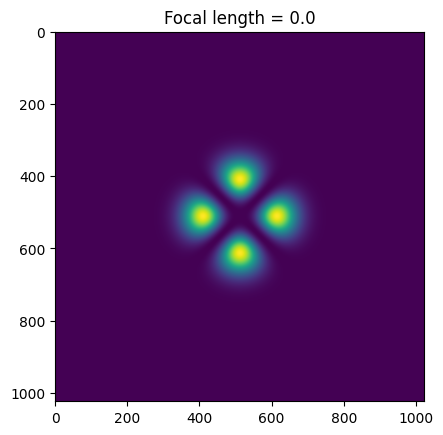

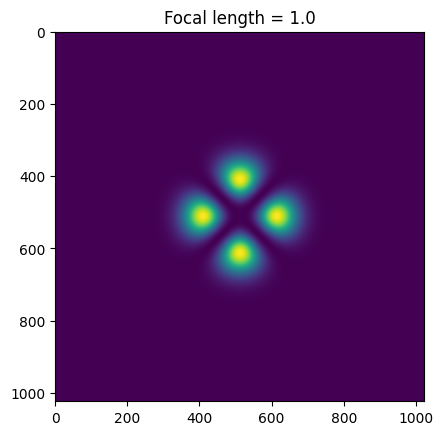

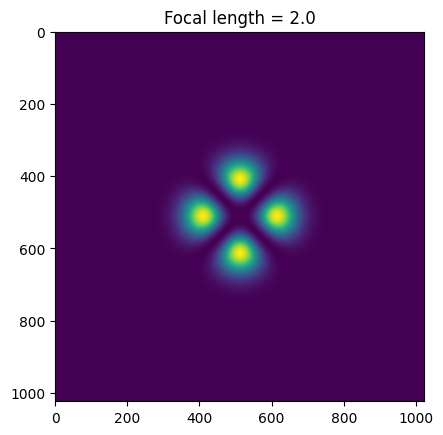

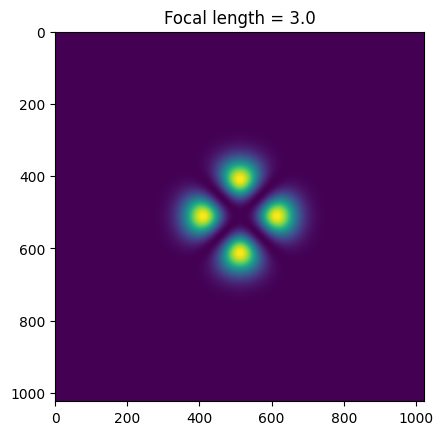

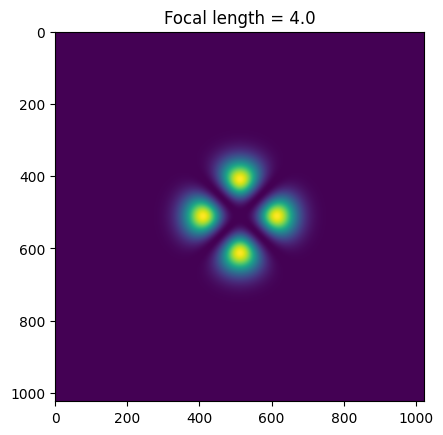

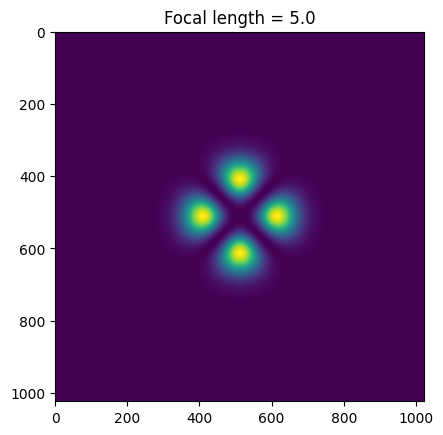

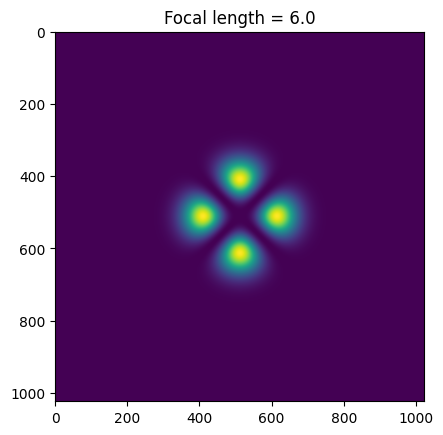

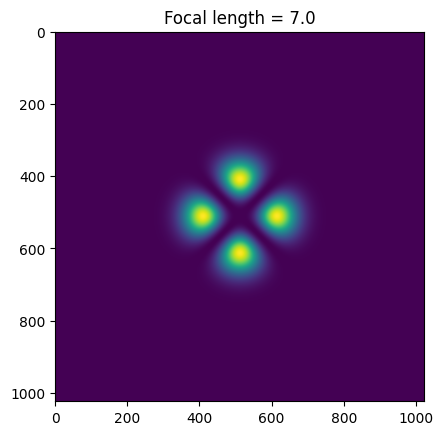

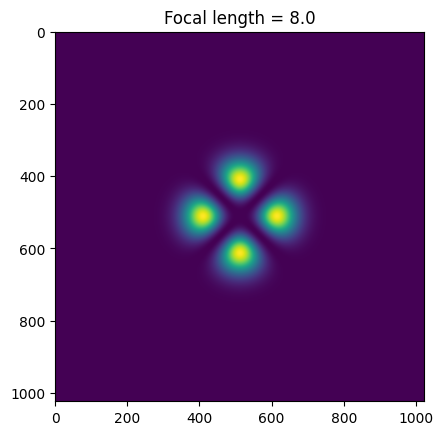

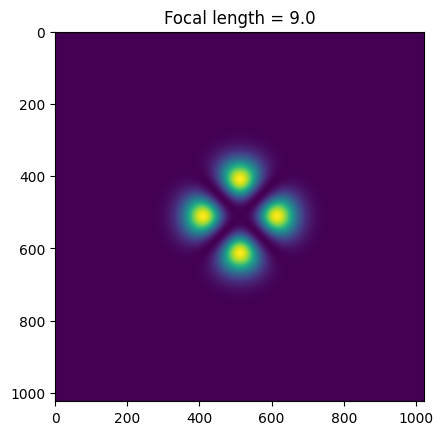

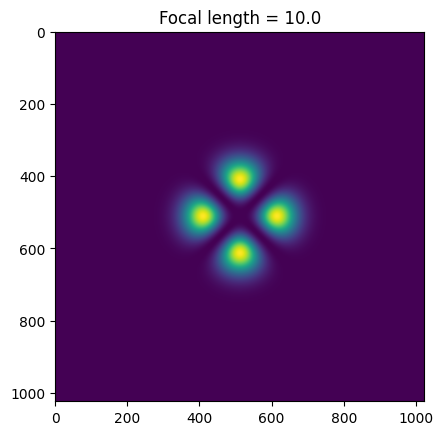

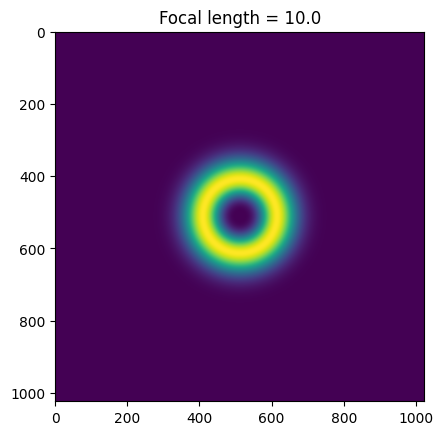

In [ ]:
'''

# initlising beams

beam_2 = LG_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,f_gw=7,t_gw_event=1)
beam_2.E = beam_2.field( beam_2.r_2, np.arctan2(beam_2.Y - beam_2.dy, beam_2.X - beam_2.dx), z=beam_2.z, p=0, l=-2)
beam_2.propagation(2)
E_2_propagated = beam_2.E


focal_lengths = np.linspace(0,10,11)



for focal_length in focal_lengths:
  beam_1 = LG_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,f_gw=7,t_gw_event=1)
  beam_1.E = beam_1.field( beam_1.r_1, np.arctan2(beam_1.Y, beam_1.X), z=beam_1.z, p=0, l=2 )
  beam_1.propagation(0.1)
  #E_1_propagated = beam_1.E
  #beam_1.focusing_lens(focal_length)
  #beam_1.propagation(focal_length)
  beam_1.propagation(2)
  E_1_propagated_focusing = beam_1.E
  plt.imshow(np.abs(beam_1.E + beam_2.E)**2)
  plt.title(f'Focal length = {focal_length}')
  plt.show()


beam_2 = LG_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,f_gw=7,t_gw_event=1)
beam_2.E = beam_2.field( beam_2.r_2, np.arctan2(beam_2.Y - beam_2.dy, beam_2.X - beam_2.dx), z=beam_2.z, p=0, l=-2)
beam_2.propagation(20)
E_2_propagated = beam_2.E
plt.imshow(np.abs(beam_2.E)**2)
plt.title(f'Focal length = {focal_length}')
plt.show()
'''


## Calling beams and propagating them

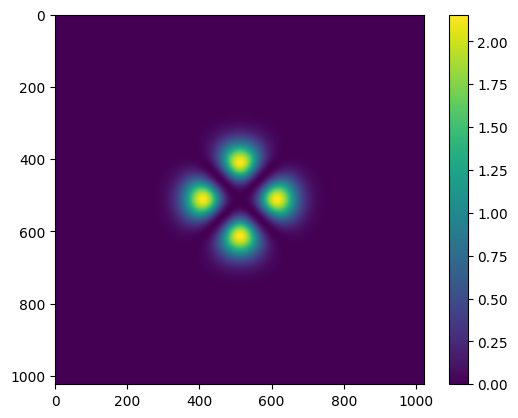

"\n# Loop through the gravitational wave phases and visualize the interference pattern.\nfor t_index in range(len(delta_phi)):\n    phi = delta_phi[t_index]\n\n    E_2_gw = E_2_propagated * np.exp(1j * phi)\n    E_total = E_1_propagated + E_2_gw\n\n    Intensity = np.abs(E_total)**2\n    plt.figure()\n    plt.imshow(Intensity)\n    plt.title(f't index = {t_index}, 'f'GW phase = {phi:.3e} rad')\n    plt.colorbar()\n    plt.show()"

In [ ]:
beam_1 = LG_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,f_gw=7,t_gw_event=1)
beam_2 = LG_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3, f_gw=7, t_gw_event=1)


beam_1.E = beam_1.field( beam_1.r_1, np.arctan2(beam_1.Y, beam_1.X), z=beam_1.z, p=0, l=2 )
beam_2.E = beam_2.field( beam_2.r_2, np.arctan2(beam_2.Y - beam_2.dy, beam_2.X - beam_2.dx), z=beam_2.z, p=0, l=-2)

# Propagate the beams. The propagation method modifies the internal E field (beam.E)
# and returns the beam object itself. We call it for its side effect of updating beam.E.
beam_1.propagation(20)
beam_2.propagation(20)


E_1_propagated = beam_1.E
E_2_propagated = beam_2.E


beam_1.gw_phase(20) ###############  develop further
delta_phi = beam_1.delta_phi # time dep phases

I = np.abs(E_1_propagated + E_2_propagated)**2
plt.imshow(I)
plt.colorbar()
plt.show()


'''
# Loop through the gravitational wave phases and visualize the interference pattern.
for t_index in range(len(delta_phi)):
    phi = delta_phi[t_index]

    E_2_gw = E_2_propagated * np.exp(1j * phi)
    E_total = E_1_propagated + E_2_gw

    Intensity = np.abs(E_total)**2
    plt.figure()
    plt.imshow(Intensity)
    plt.title(f't index = {t_index}, 'f'GW phase = {phi:.3e} rad')
    plt.colorbar()
    plt.show()'''

### Plotting the petal interference pattern after from 1 to 20m dist of propagation

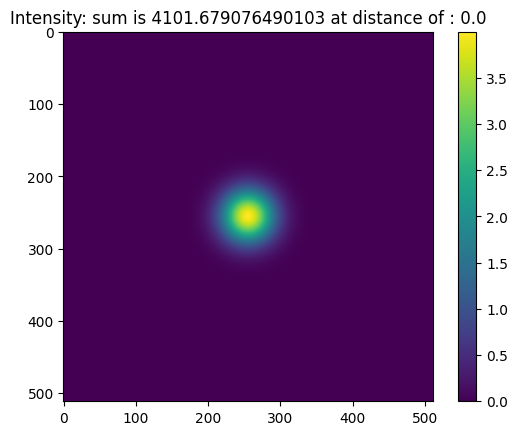

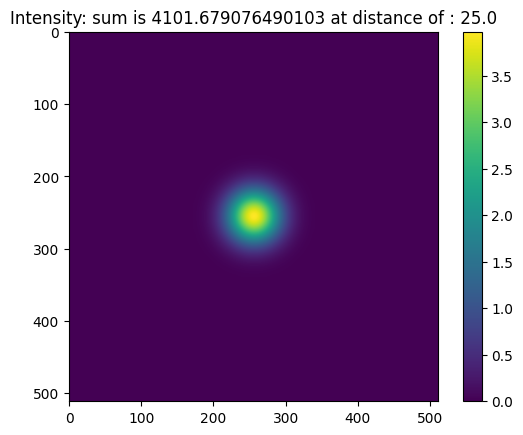

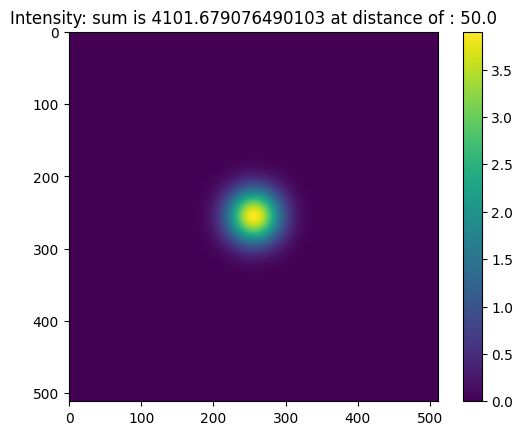

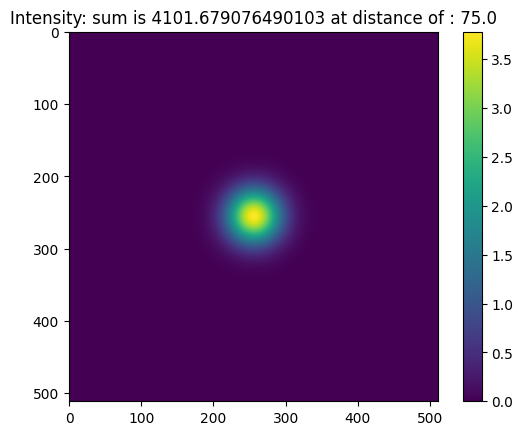

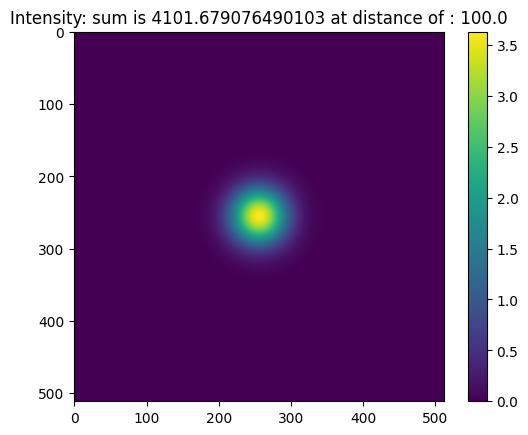

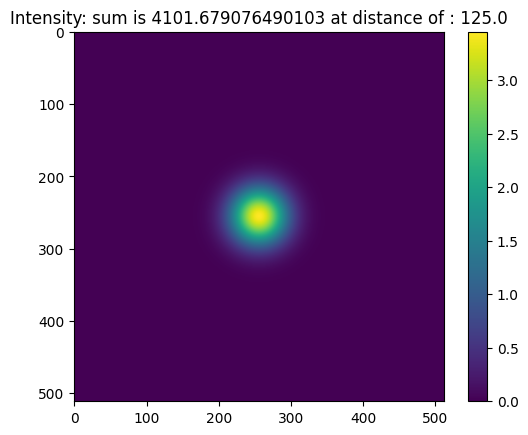

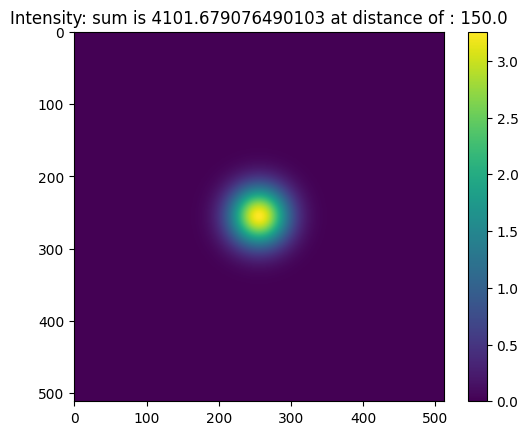

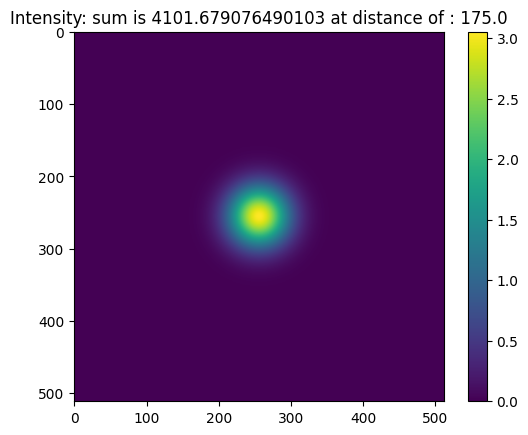

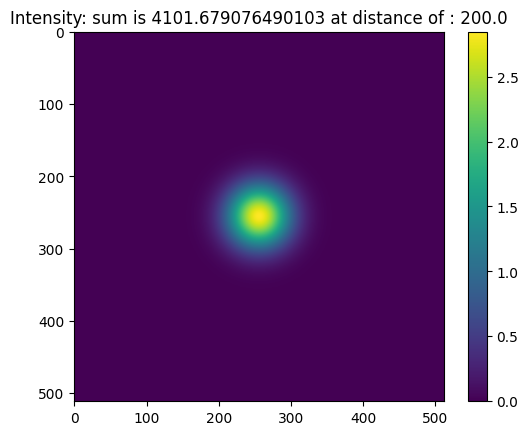

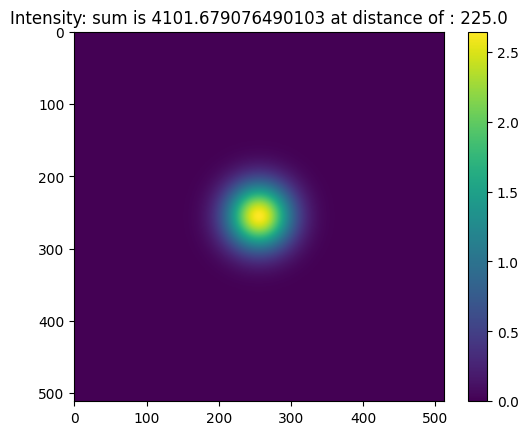

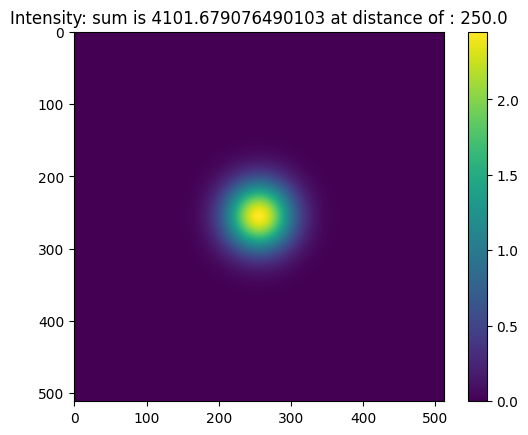

KeyboardInterrupt: 

In [ ]:
dists = np.linspace(0,500,21)

for dist in dists:
  beam_1 = G_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,f_gw=1e4,t_gw_event=1, h_0 = 1e-23) ##  use h_0 = 1e-10 to see slight petal roataion !!!!
  beam_2 = G_Beam( dist=0, lamb=10e-9, E_0=1, w_0=1e-3,  f_gw=1e4, t_gw_event=1, h_0 = 1e-23) ##  use h_0 = 1e-10 to see slight petal roataion !!!!

  beam_1.E = beam_1.field( beam_1.r_1, z=beam_1.z )
  beam_2.E = beam_2.field( beam_2.r_2, z=beam_2.z)

  beam_1.propagation(dist)
  beam_2.propagation(dist)


  beam_1.gw_phase(dist)
  #beam_2.gw_phase(dist)

  E_1_propagated = beam_1.E
  E_2_propagated = beam_2.E

  I = np.abs(E_1_propagated + E_2_propagated)**2
  plt.imshow(I)
  plt.colorbar()
  #plt.title(f'Intensity: sum is {np.sum(I[:len(I)//4, :len(I)//4 ])} at distance of : {dist}')
  plt.title(f'Intensity: sum is {np.sum(I[:len(I)//2, :len(I)//2 ])} at distance of : {dist}')

  plt.show()

#### The propagating the beam further

In [ ]:
def plot(E_1,E_2):


  I = np.abs(E_1 + E_2)**2
  plt.imshow(I)
  plt.colorbar()
  plt.title(f'Intensity: sum is {I}')
  plt.show()
  mid = len(E_1)//2

  I_quad = np.abs(E_1[:mid,:mid] + E_2[:mid,:mid])**2
  plt.imshow(I_quad)
  plt.colorbar()
  plt.title(f'Top left quadrant of intensity : sum is {I_quad}')
  plt.show()

  return I,I_quad


def optimal_length(E_1, E_2, wavelength = 10e-9,
                   t_gw = np.linspace(0,1,1000), w_gw = 2*np.pi*1e4,
                   dist_prop_max = 10**5, h_0 = 1e-23):
  # 1. Generate the phase sweep for the sensitivity curve
  delta_phis_sweep = np.linspace(0,2*np.pi,1000)
  I_quad_values = []

  for del_phi_val in delta_phis_sweep: # Using a different variable name for clarity
    E_beam1, E_beam2_shifted = E_1, E_2 * np.exp(1j * del_phi_val)
    E_total = E_beam1 + E_beam2_shifted
    Intensity = np.abs(E_total)**2

    mid = Intensity.shape[0] // 2 # Use shape[0] for square 2D array
    I_quad_current = np.sum(Intensity[:mid,:mid]) # Sum of intensity in top-left quadrant
    I_quad_values.append(I_quad_current)

  I_quad_array = np.array(I_quad_values)

  # 2. Calculate gradient of sensitivity curve
  dI_dphi = np.gradient(I_quad_array, delta_phis_sweep)

  # 3. Find the phase shift that gives maximum sensitivity
  max_index = np.argmax(np.abs( dI_dphi) )
  delta_phi_max_change = delta_phis_sweep[max_index] # Use delta_phis_sweep here

  print("Optimal phase shift for max sensitivity (delta_phi_max_change) =", delta_phi_max_change)
  print("Maximum |dI/dphi| =", np.abs(dI_dphi[max_index]))

  # 4. Calculate GW-induced phase shift for a range of path lengths
  c = 3e8
  x_lengths_to_test = np.linspace(0, dist_prop_max, 10000) # These are the propagation distances to test
  gw_induced_delta_phis_at_final_time = []

  # Calculate GW-induced delta_phi for each `x_val`
  for x_val in x_lengths_to_test:
      x_integration_points = np.linspace(0, x_val, 100) # Use 100 points for integration for this x_val
      # 't_gw[:, None]' makes t_gw a column vector, allowing broadcasting with 'x_integration_points[None, :]'
      h = h_0 * np.cos(w_gw * (t_gw[:, None] - (x_val - x_integration_points[None, :]) / c))
      # h will be (len(t_gw), len(x_integration_points))
      delta_L_for_t_gw = 0.5 * np.trapezoid(h, x_integration_points, axis=1)
      # delta_L_for_t_gw will be (len(t_gw),)
      delta_phi_for_t_gw = (2 * np.pi / wavelength) * delta_L_for_t_gw
      gw_induced_delta_phis_at_final_time.append(delta_phi_for_t_gw[-1]) # Take the last (final) delta_phi value for this x_val

  gw_induced_delta_phis_array = np.array(gw_induced_delta_phis_at_final_time)

  # 5. Find the optimal path length
  # We want to find x_lengths_to_test[index] such that gw_induced_delta_phis_array[index]
  # is closest to delta_phi_max_change.

  diff = np.abs(gw_induced_delta_phis_array - delta_phi_max_change)
  index = np.argmin(diff)

  dist_prop_opt = x_lengths_to_test[index] # This is the optimal physical length

  print("Optimal path length (dist_prop_opt) =", dist_prop_opt)
  print("Phase at this path length (GW induced) =", gw_induced_delta_phis_array[index])
  print("Target phase (for max sensitivity) =", delta_phi_max_change)

  return delta_phi_max_change, dist_prop_opt

In [ ]:
opt_len = optimal_length(E_1_propagated,E_2_propagated)
print(opt_len)

Optimal phase shift for max sensitivity (delta_phi_max_change) = 0.3207632138800389
Maximum |dI/dphi| = 7.275957614183426e-12
Optimal path length (dist_prop_opt) = 7490.749074907491
Phase at this path length (GW induced) = 1.4999657933125417e-11
Target phase (for max sensitivity) = 0.3207632138800389
(np.float64(0.3207632138800389), np.float64(7490.749074907491))


# Gaussian Beam

In [ ]:
class G_Beam:

    def __init__(self, dist=0, lamb=10e-9, E_0=1, w_0=1e-3,
                 phi_1=0, phi_2 = 0,
                 x_range=5e-3, y_range=5e-3, points=512,
                 dx=0, dy=0, dist_prop=0, f_gw=1e4,
                 t_gw_event=1, h_0=1e-23, delta_phis=[]): # phi_2=np.deg2rad(10)

        self.dist = dist
        self.dist_prop = dist_prop
        self.lamb = lamb
        self.E_0 = E_0
        self.w_0 = w_0

        self.phi_1 = phi_1
        self.phi_2 = phi_2

        self.f_gw = f_gw
        self.t_gw_event = t_gw_event
        self.h_0 = h_0

        self.delta_phis = delta_phis

        self.dx = dx
        self.dy = dy

        # defining z coordinate
        self.z = self.z_(self.dist)

        self.k = self.k_(self.lamb)

        # Rayleigh length
        self.z_R = self.z_R_(self.w_0, self.lamb)

        # beam spot size
        self.w_z = self.w_z_(self.w_0, self.z)

        # radius of curvature
        self.R_cur_z = self.R_cur_z_(self.z, self.z_R)

        self.x = np.linspace(-x_range, x_range, points)
        self.y = np.linspace(-y_range, y_range, points)

        self.X, self.Y = np.meshgrid(self.x, self.y)

        self.x_range = x_range
        self.y_range = y_range
        self.points = points

        # radial distance from beam axis
        self.r_1 = np.sqrt(self.X**2 + self.Y**2)

        # shifted radial distance
        self.r_2 = np.sqrt((self.X - self.dx)**2 + (self.Y - self.dy)**2)

        # Gouy shift
        self.g_shift = self.g_shift_(self.z, self.z_R)


    #####

    def z_(self, dist):
        # dist travelled along axis of propagation
        return dist


    #####

    def k_(self, wavelength):
        # returns wavenumber
        return 2 * np.pi / wavelength


    ######

    def z_R_(self, w_0, lamb):
        # Rayleigh length of Gaussian beam
        return np.pi * w_0**2 / lamb


    ########

    def w_z_(self, w_0, z):
        # beam spot size as the beam diffracts while travelling
        return w_0 * np.sqrt(1 + (z / self.z_R)**2)


    ########

    def R_cur_z_(self, z, z_R):
        # radius of curvature of beam's wavefront

        if z == 0:
            return np.inf

        return z * (1 + (z_R / z)**2)


    ##########

    def g_shift_(self, z, z_R):
        # Gouy shift
        return np.arctan(z / z_R)


    ######

    def field(self, r, z, w0=None, lamb=None, E0=None):

        # Use the class values unless different values are supplied
        if w0 is None:
            w0 = self.w_0

        if lamb is None:
            lamb = self.lamb

        if E0 is None:
            E0 = self.E_0

        k = self.k_(lamb)

        z_R = self.z_R_(w0, lamb)

        w_z = w0 * np.sqrt(1 + (z / z_R)**2)

        R_cur_z = self.R_cur_z_(z, z_R)

        # Gouy phase
        gouy = np.arctan(z / z_R)

        # Gaussian amplitude
        amplitude = (w0 / w_z) * np.exp(-r**2 / w_z**2)

        # At z = 0, the curvature phase is 1
        if np.isinf(R_cur_z):
            curvature_phase = 1
        else:
            curvature_phase = np.exp(
                -1j * k * r**2 / (2 * R_cur_z)
            )

        # Total phase
        phase = (
            curvature_phase
            * np.exp(1j * gouy)
            * np.exp(-1j * k * z)
        )

        E = E0 * amplitude * phase

        self.E = E

        return self.E


    def propagation(self, dist_prop):

        # using FT beam propagation

        x = np.linspace(
            -self.x_range,
            self.x_range,
            self.points
        )

        y = np.linspace(
            -self.y_range,
            self.y_range,
            self.points
        )

        dx = x[1] - x[0]
        dy = y[1] - y[0]

        Nx, Ny = self.points, self.points

        fx = np.fft.fftfreq(Nx, dx)
        fy = np.fft.fftfreq(Ny, dy)

        fx, fy = np.meshgrid(fx, fy)

        kx = 2 * np.pi * fx
        ky = 2 * np.pi * fy

        kz = np.sqrt(
            self.k**2 - kx**2 - ky**2
        ).astype(complex)

        # FT of Gaussian electric field
        E_ft = np.fft.fft2(self.E)

        travelling_term = np.exp(
            1j * kz * dist_prop
        )

        E_ft_prop = E_ft * travelling_term

        self.dist += dist_prop

        # update current beam position
        self.z = self.dist

        E_prop = np.fft.ifft2(E_ft_prop)

        self.E = E_prop

        return self


    def focusing_lens(self, focal_length):

        r_squared = self.X**2 + self.Y**2

        lens_phase = np.exp(
            -1j * self.k * r_squared / (2 * focal_length)
        )

        self.E *= lens_phase

        return self


    def gw_phase(self, dist_prop):

        c = 3e8

        w_gw = 2 * np.pi * self.f_gw

        times = np.linspace(0,self.t_gw_event,self.points)

        z = np.linspace(0,dist_prop,self.points)

        h = self.h_0 * np.cos(w_gw * (times[:, None]- (dist_prop - z[None, :]) / c))

        delta_L = 0.5 * np.trapezoid(h,z,axis=1)

        delta_phi = ((2 * np.pi / self.lamb)* delta_L)

        # Store the whole GW evolution
        self.times = times
        self.delta_phi = delta_phi

        # Use final GW phase
        self.phi_final = delta_phi[-1]

        # Apply final phase to electric field
        self.E *= np.exp( 1j * self.phi_final)

        return self

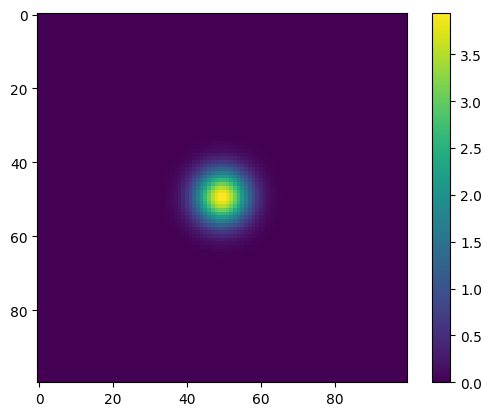

In [ ]:
beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100,f_gw=7,t_gw_event=1)

beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100,f_gw=7,t_gw_event=1)


# Create the Gaussian fields
beam_1.E = beam_1.field(beam_1.r_1,z=beam_1.z)

beam_2.E = beam_2.field(beam_2.r_2,z=beam_2.z)


# Propagate the beams
beam_1.propagation(20)
beam_2.propagation(20)


E_1_propagated = beam_1.E
E_2_propagated = beam_2.E


# Calculate GW phase
beam_1.gw_phase(20)

delta_phi = beam_1.delta_phi


# Interference pattern
I = np.abs(E_1_propagated + E_2_propagated)**2

plt.imshow(I)
plt.colorbar()
plt.show()

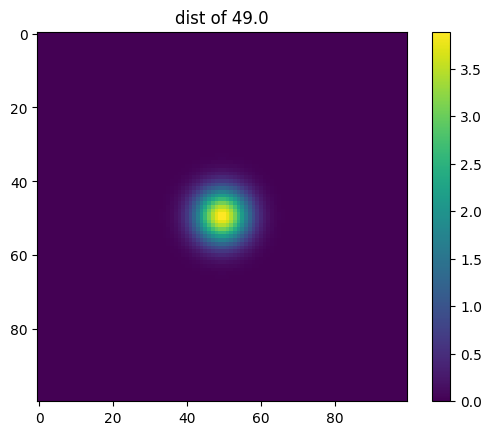

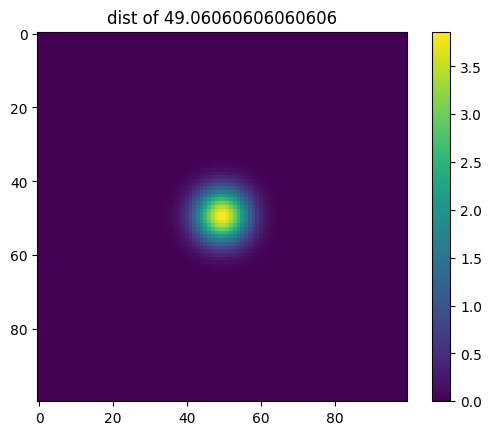

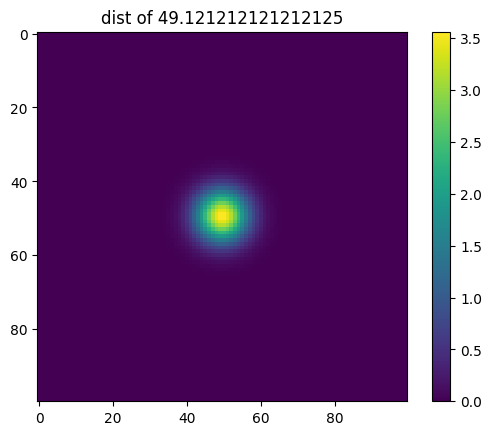

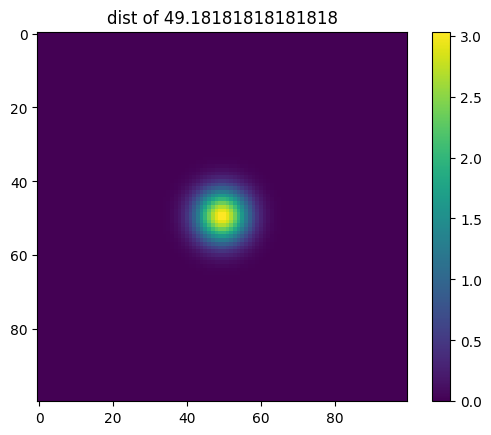

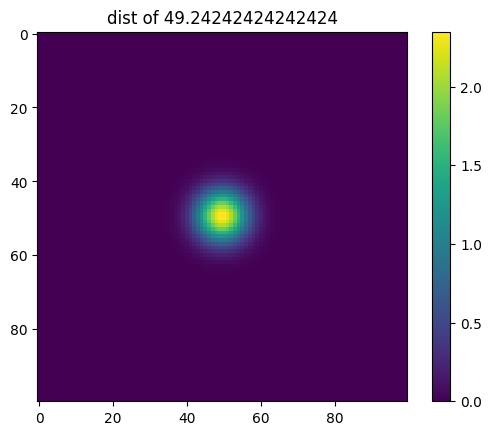

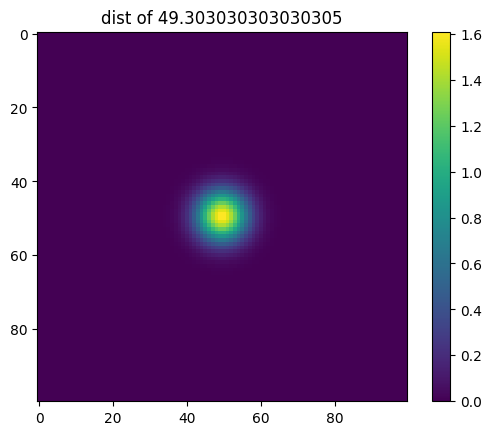

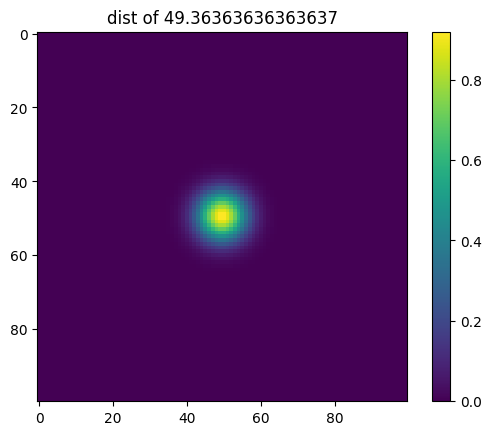

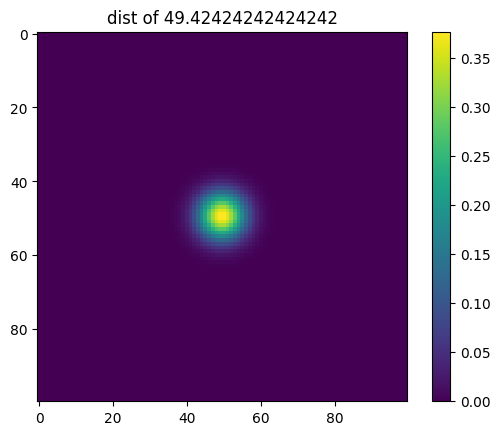

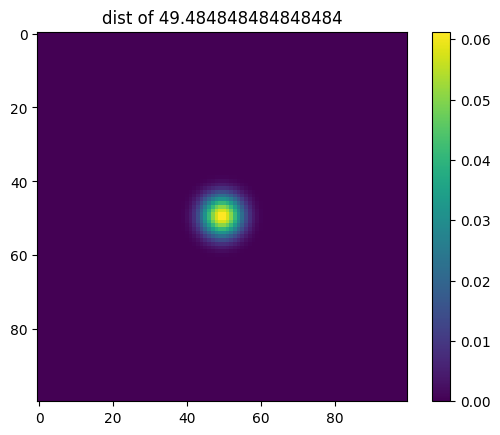

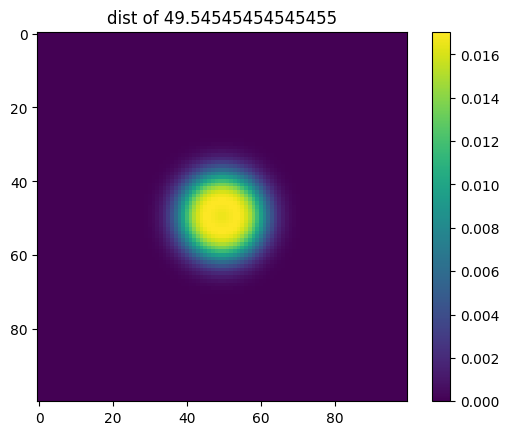

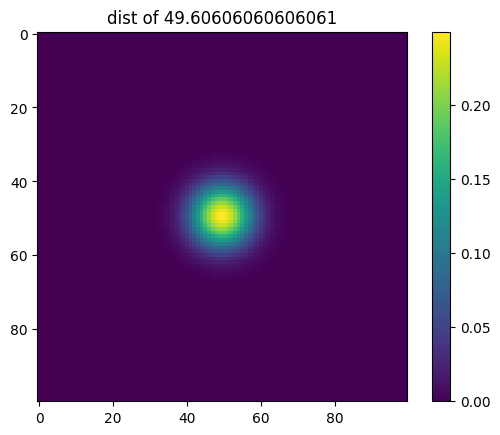

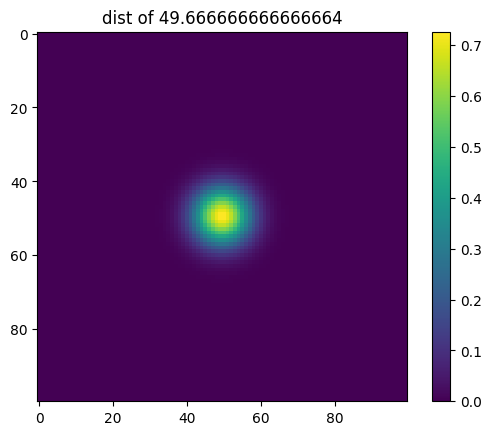

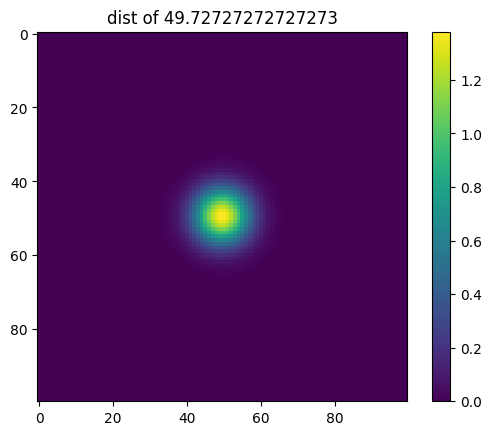

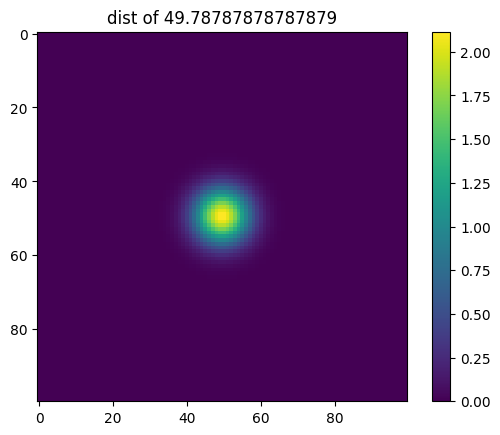

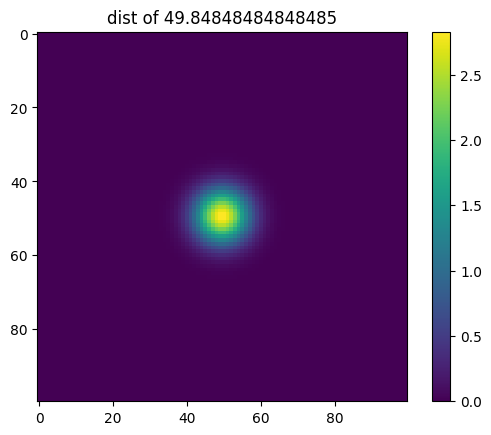

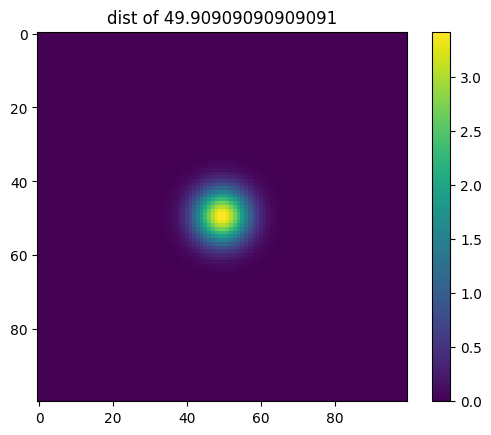

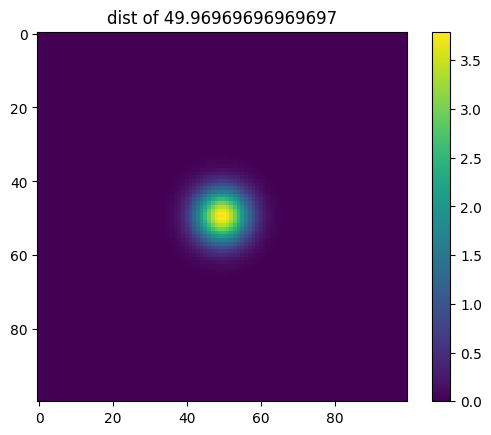

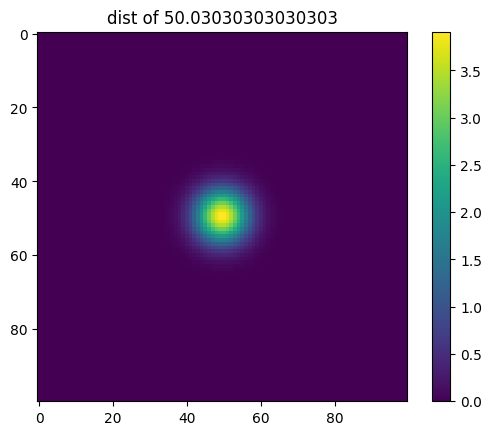

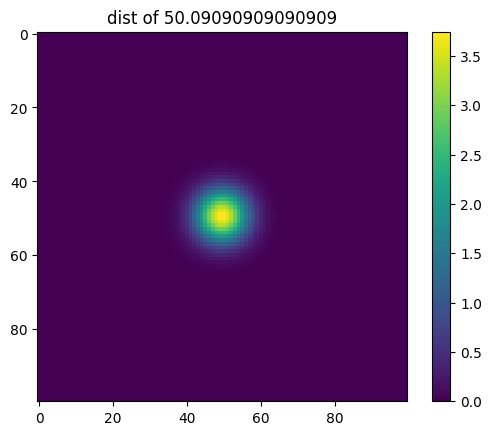

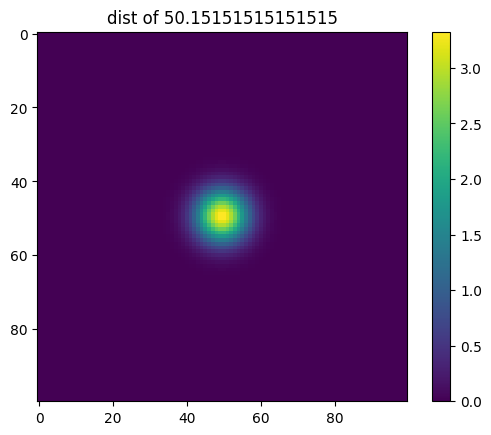

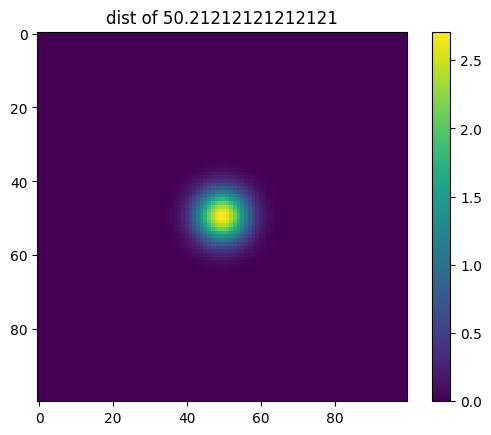

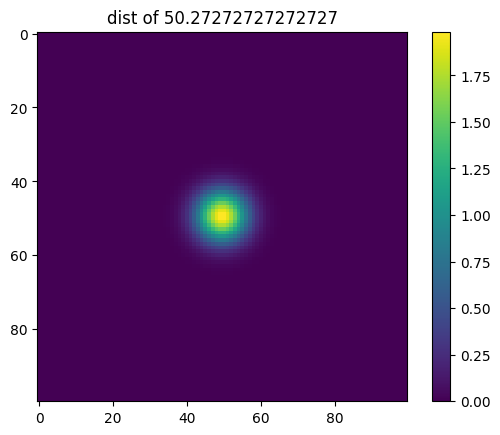

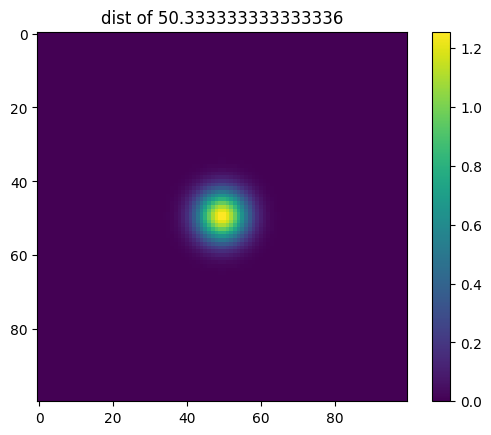

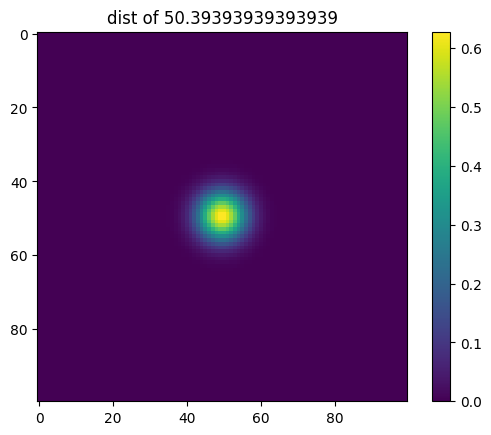

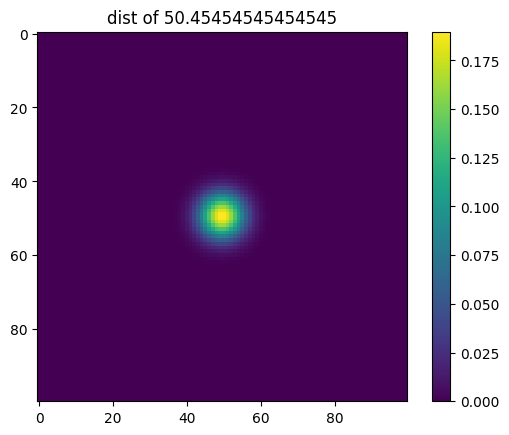

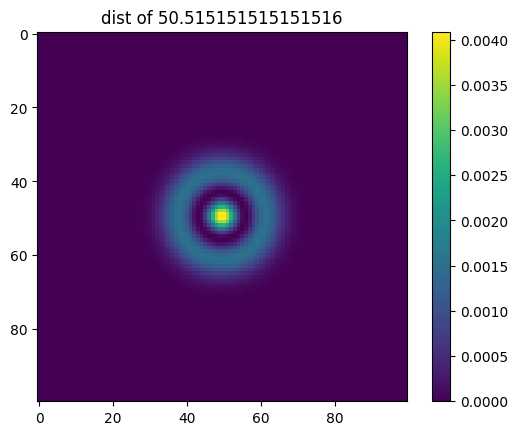

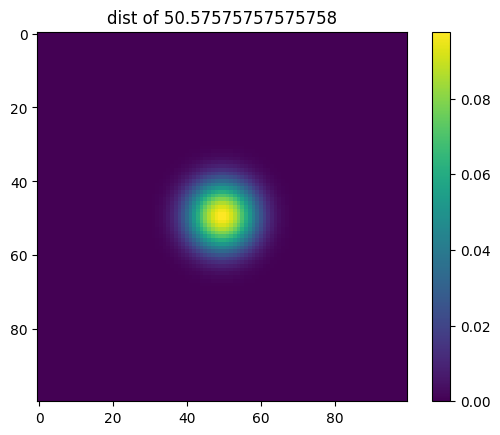

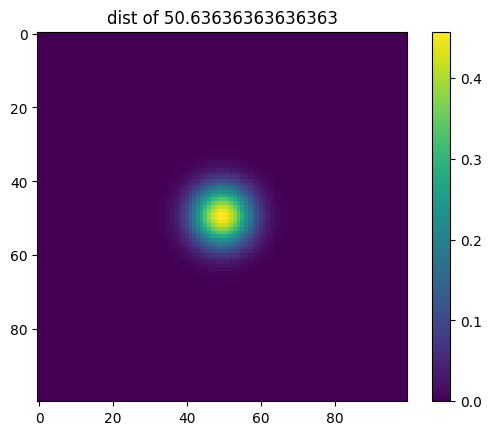

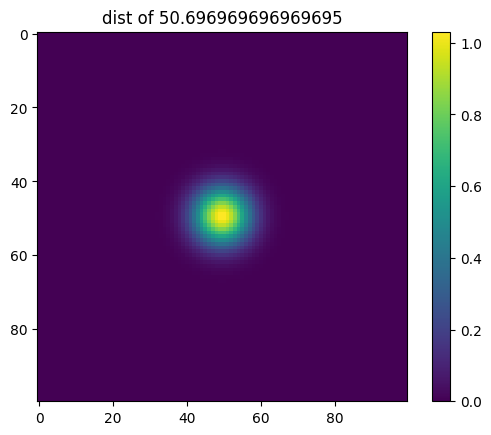

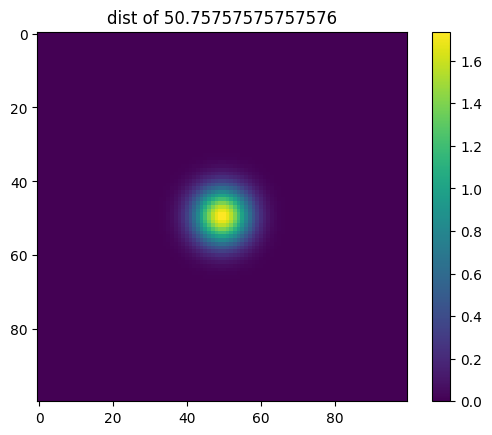

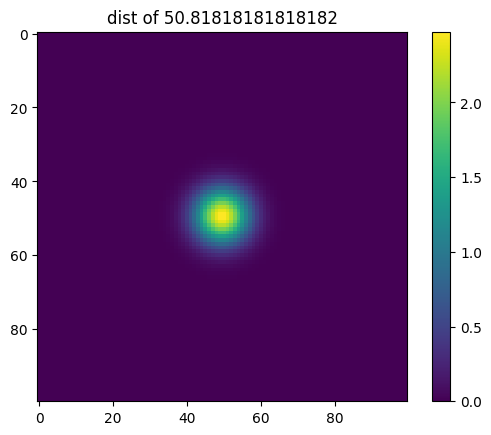

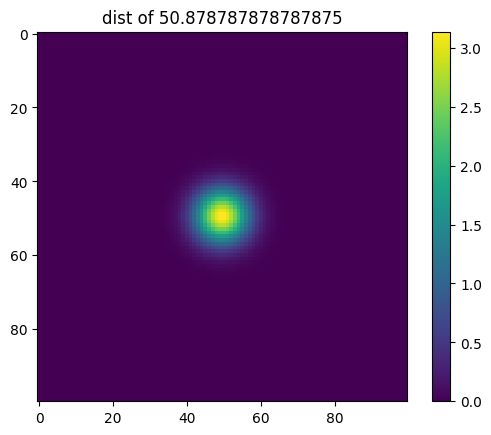

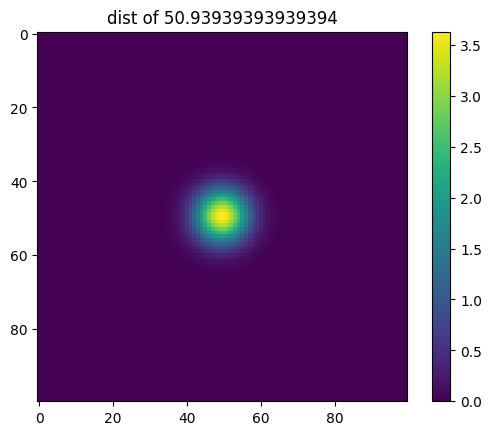

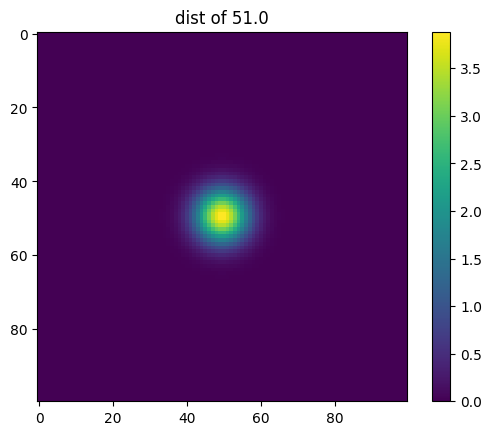

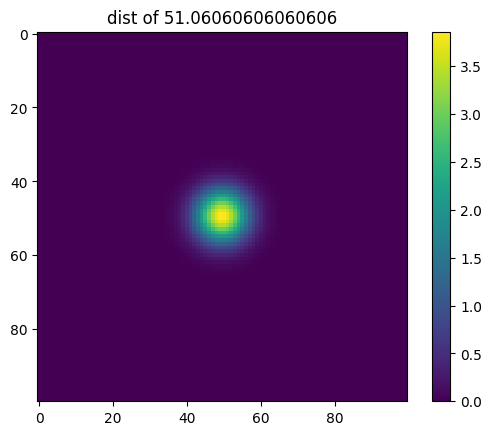

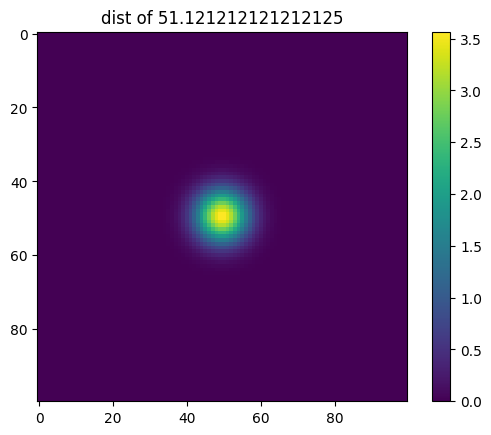

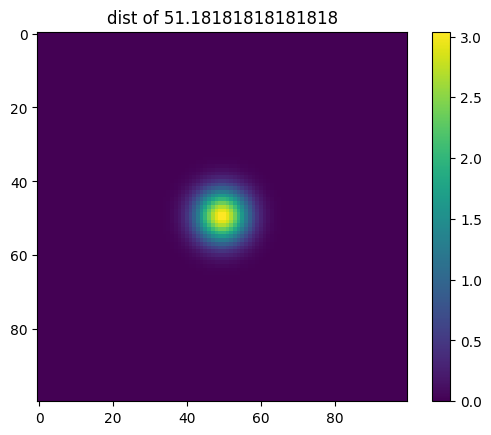

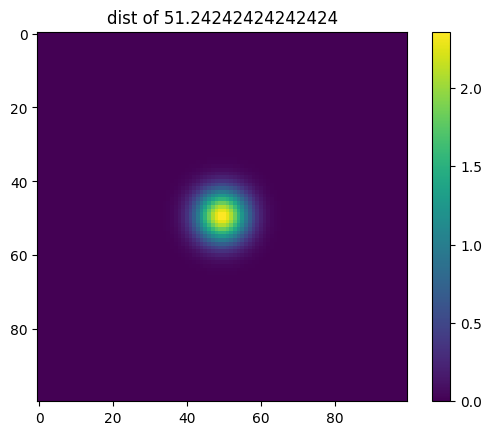

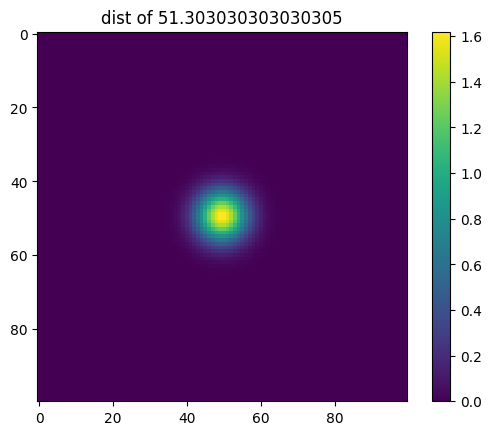

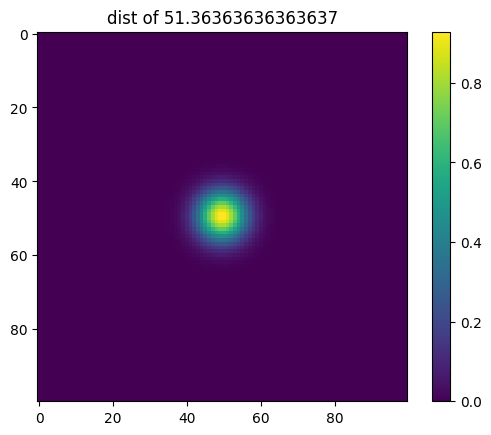

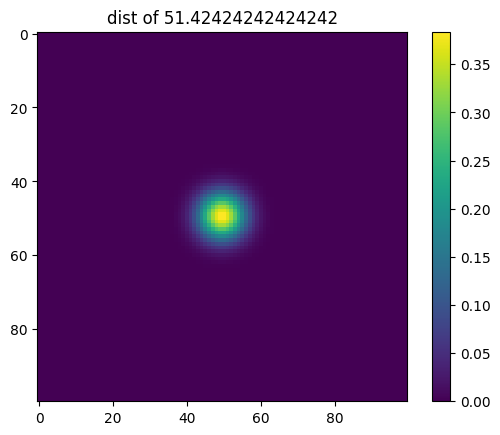

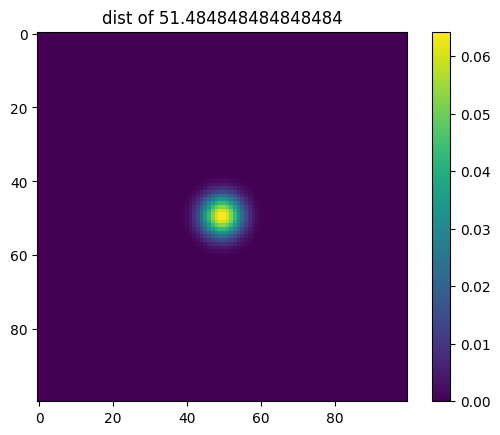

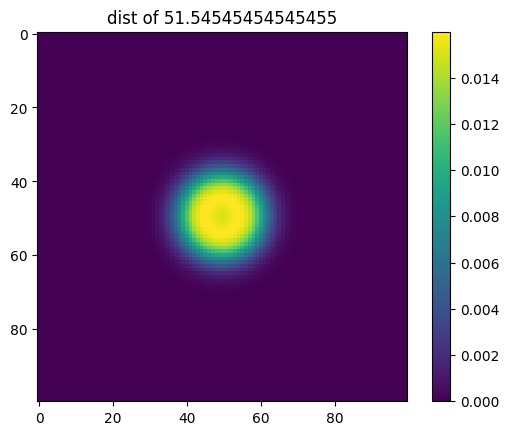

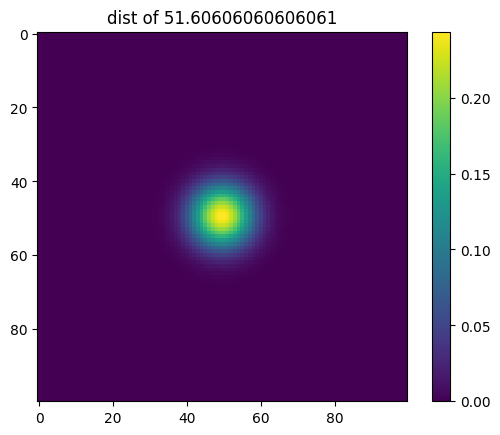

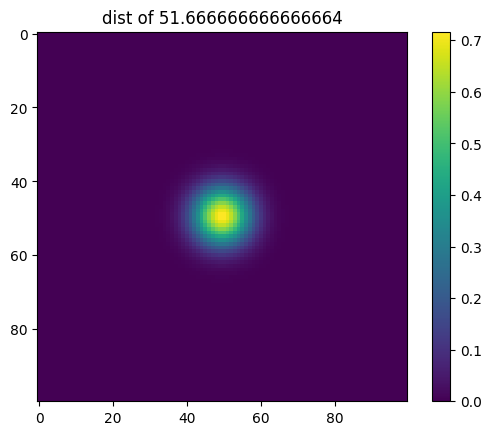

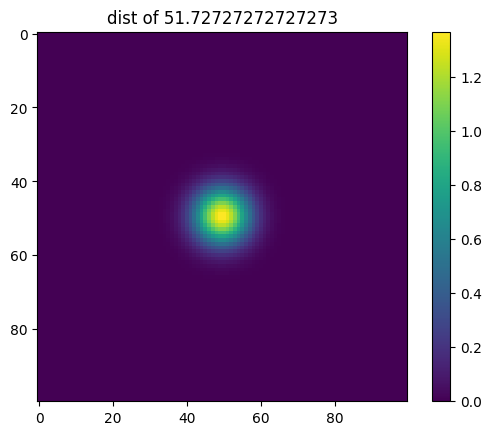

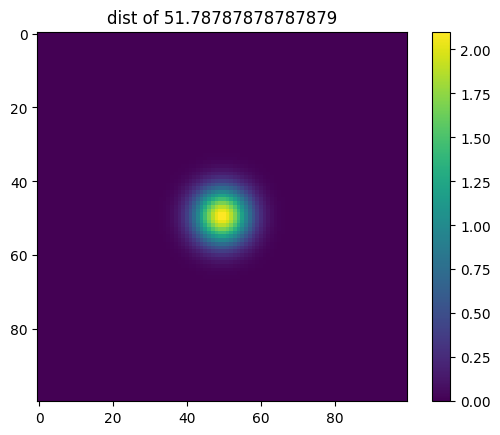

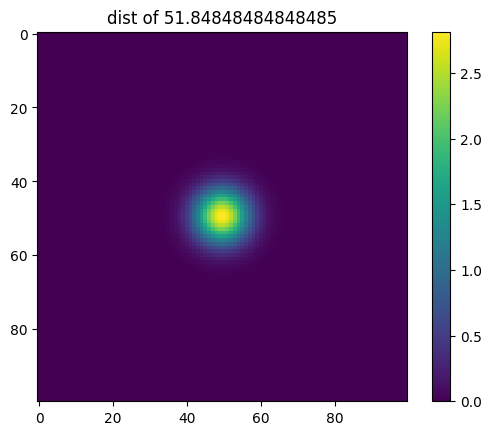

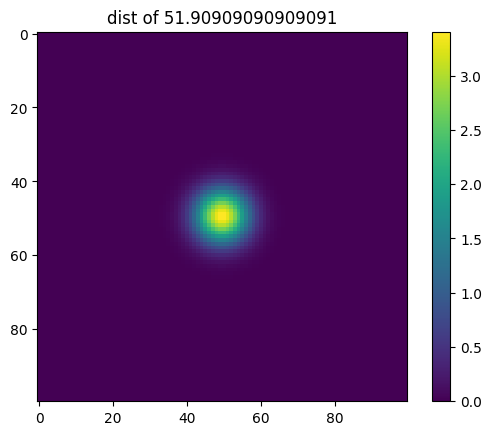

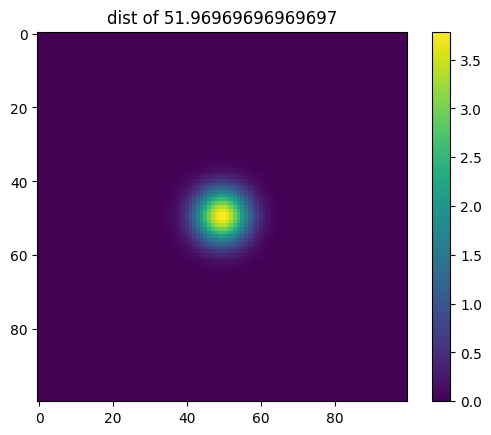

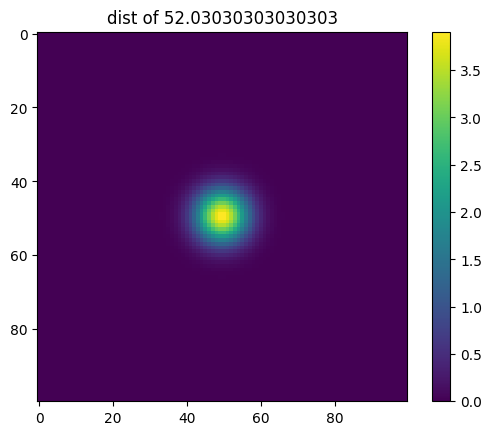

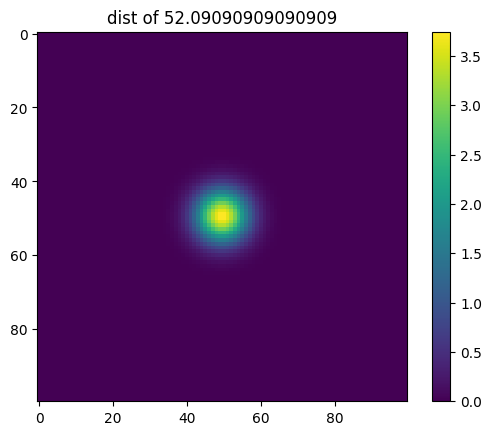

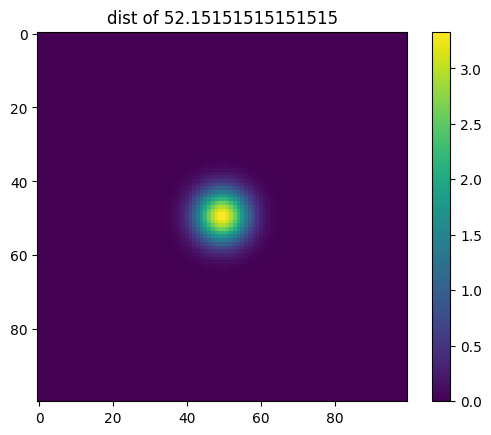

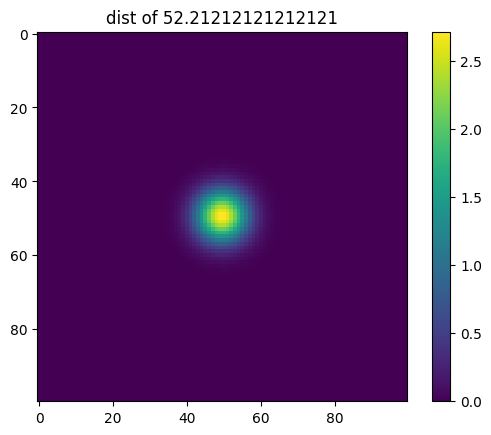

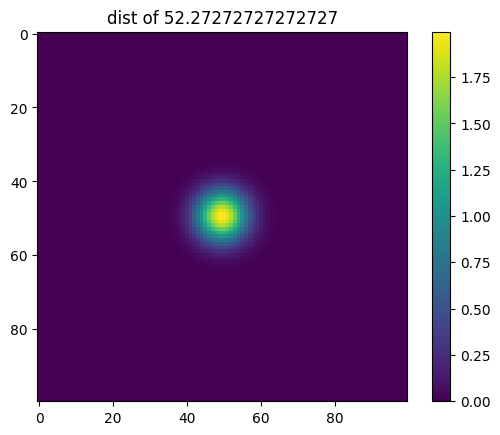

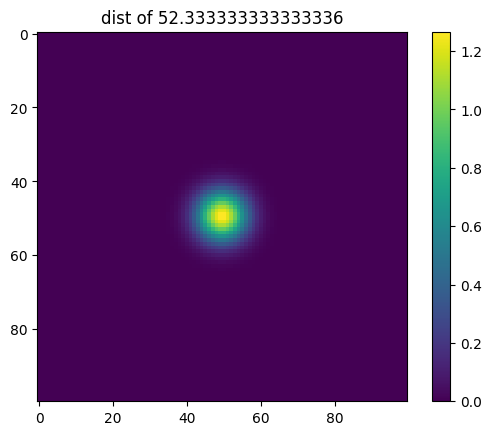

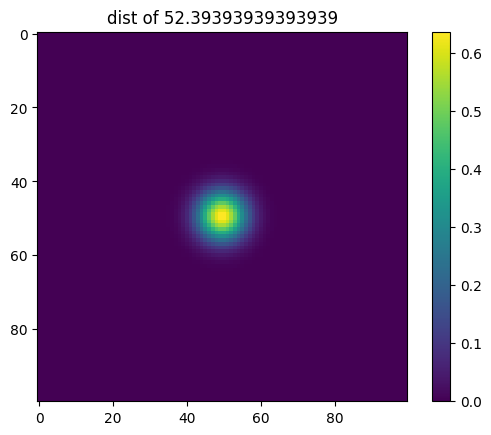

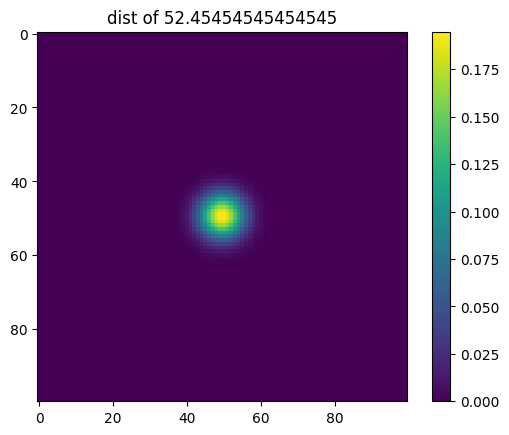

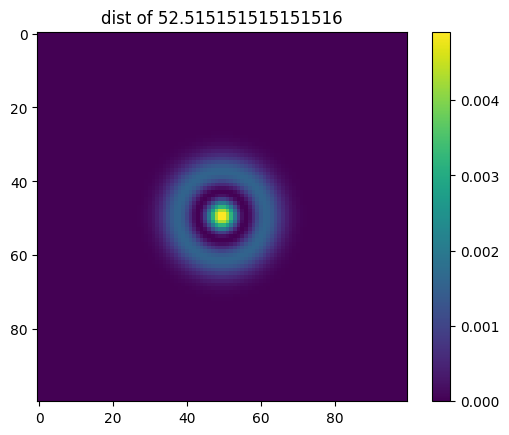

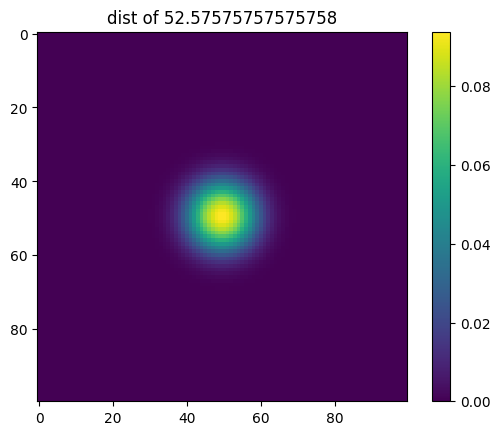

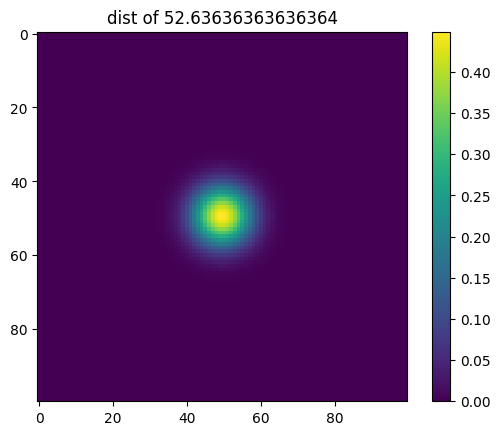

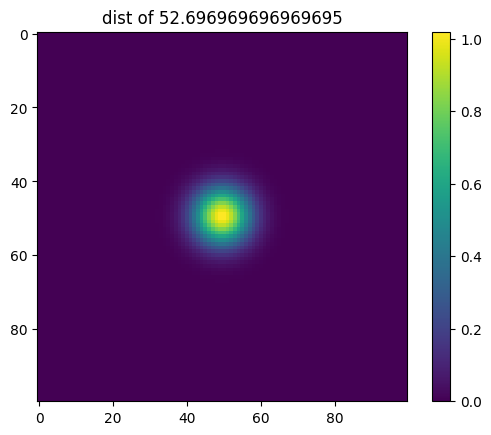

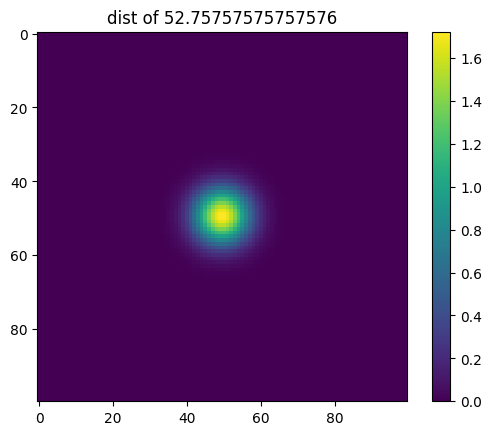

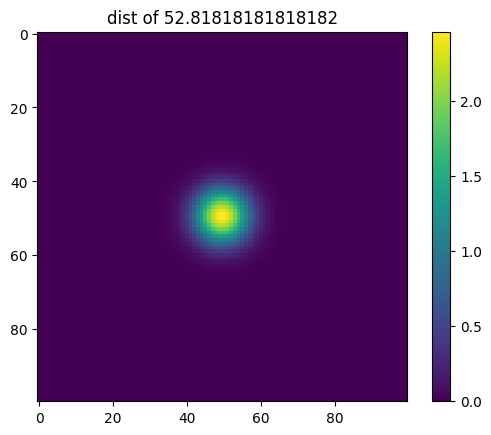

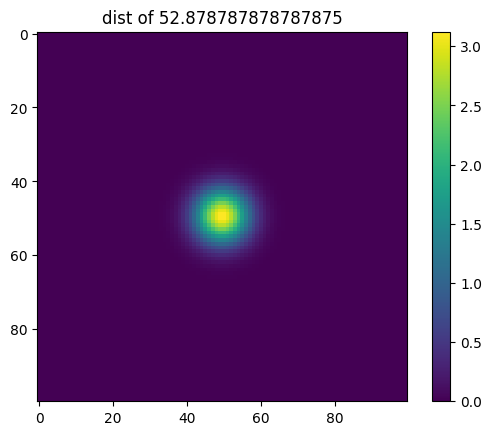

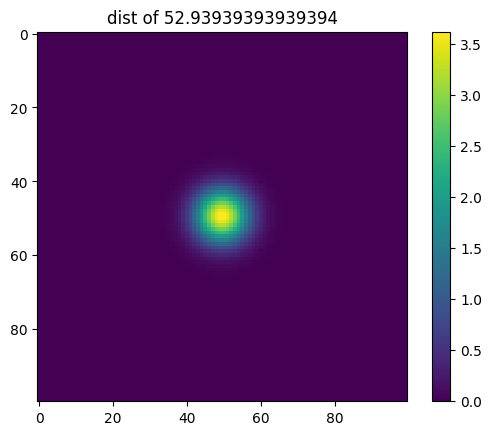

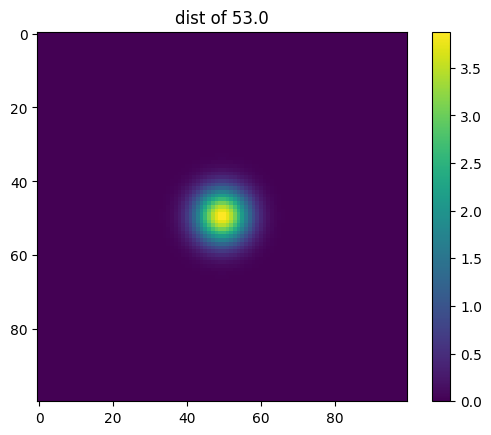

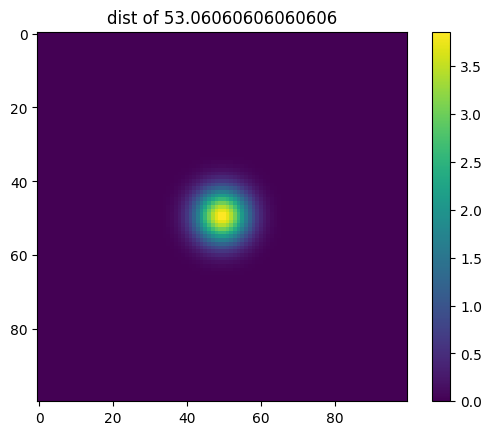

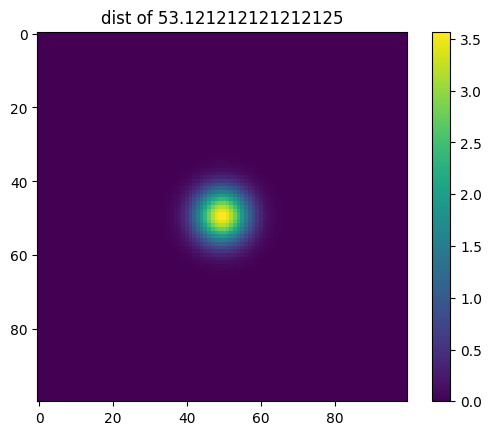

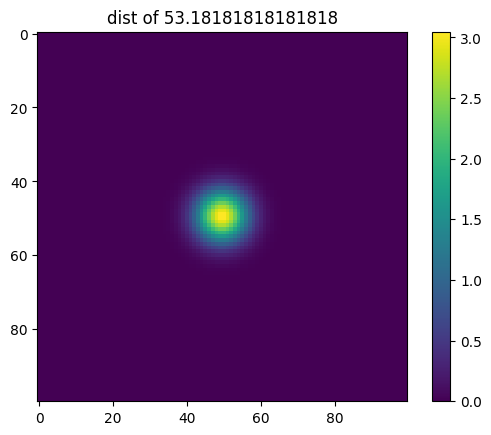

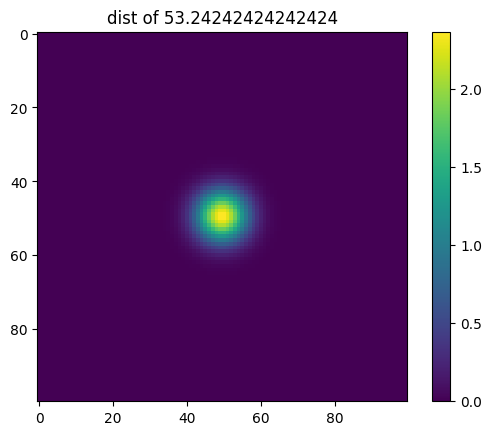

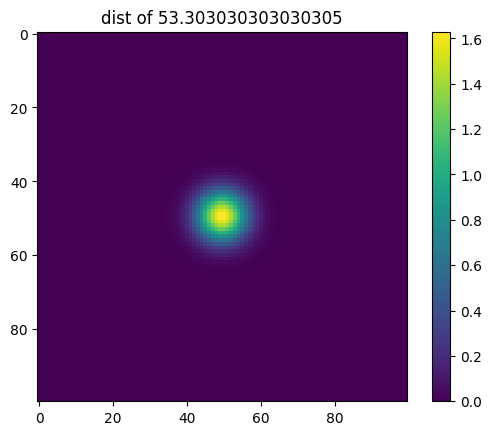

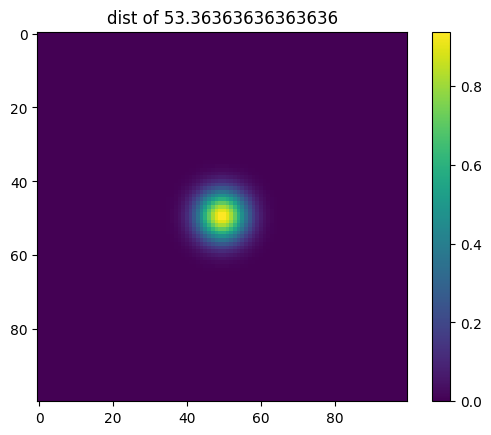

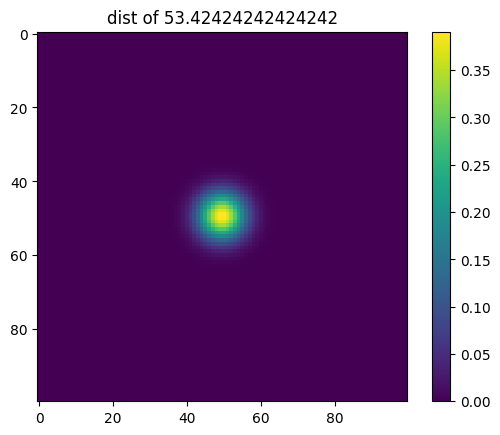

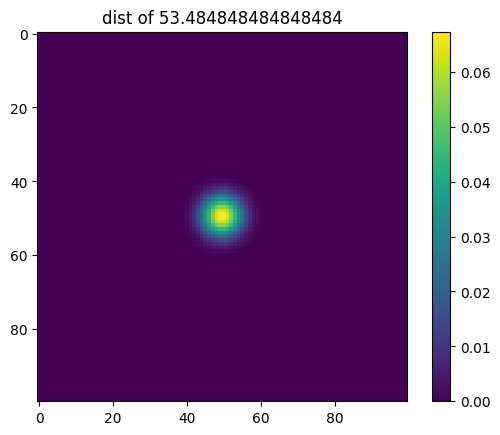

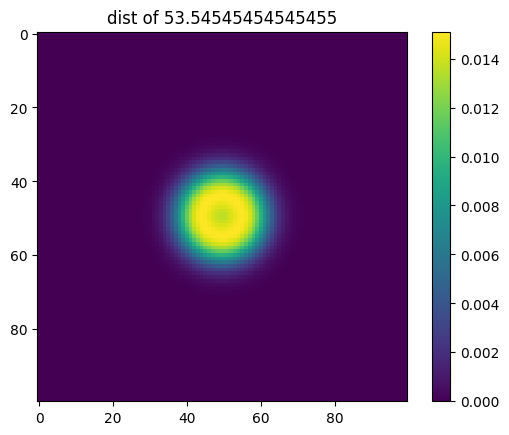

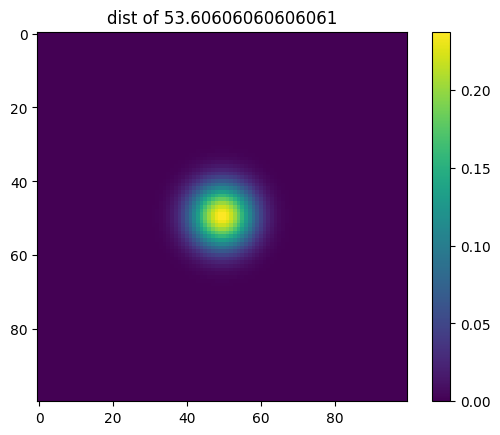

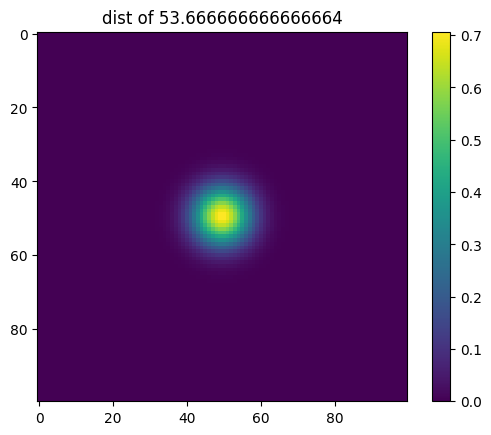

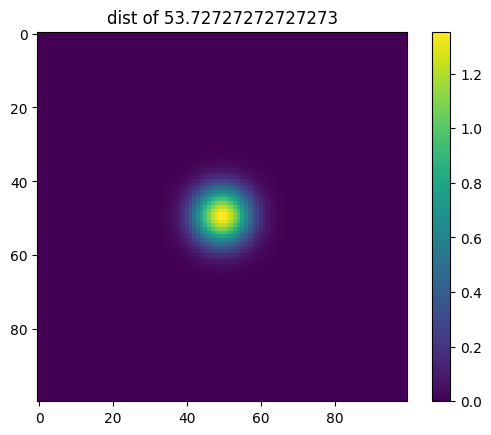

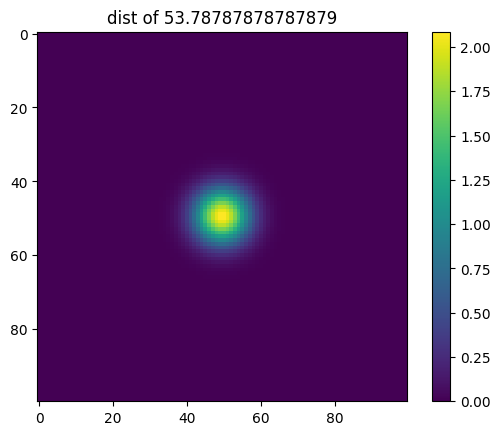

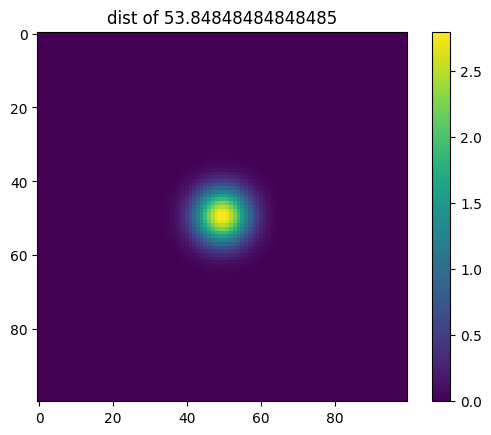

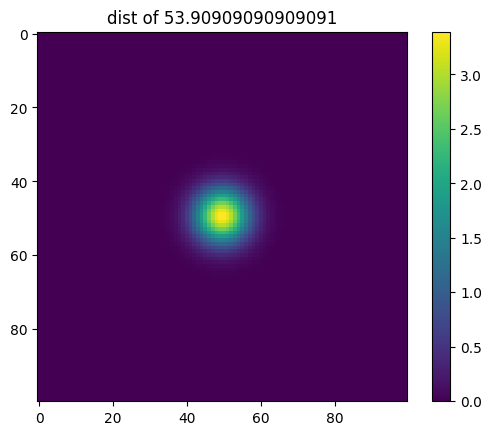

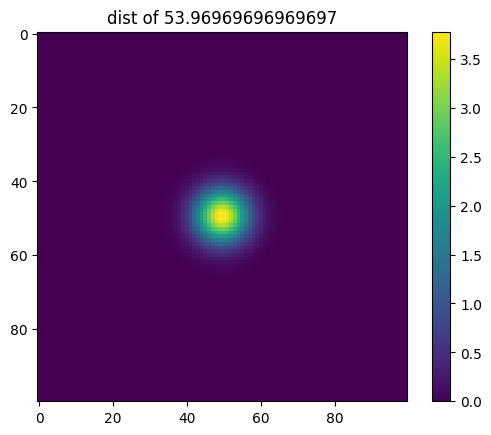

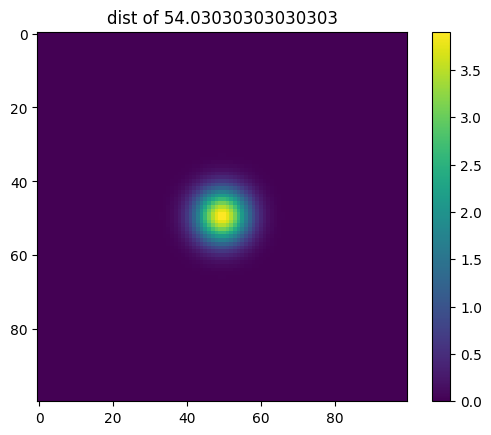

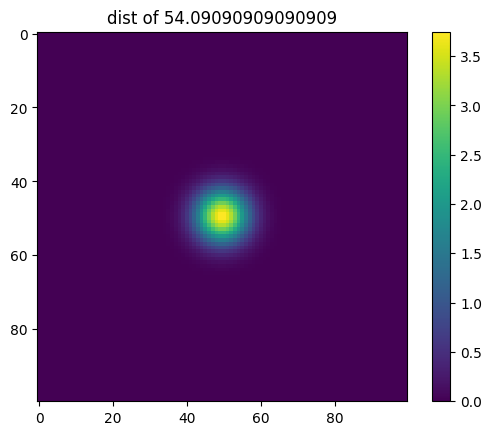

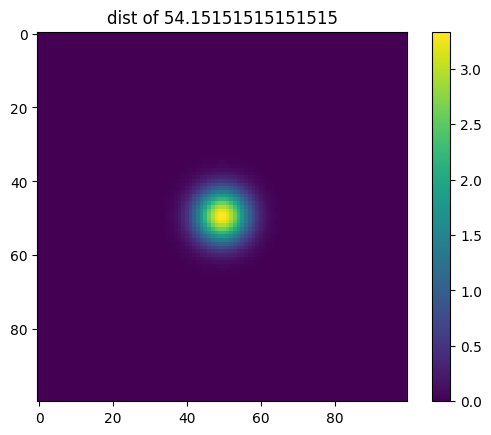

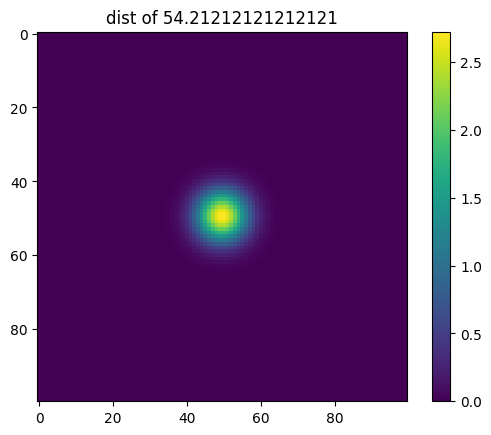

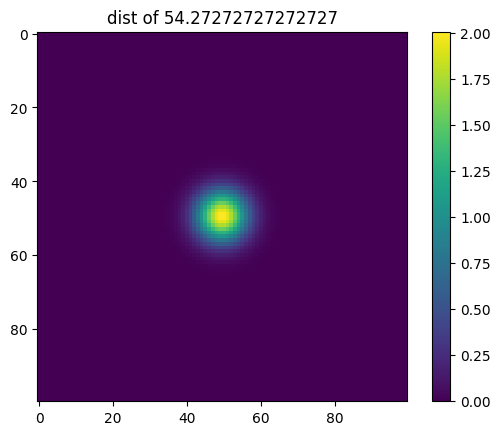

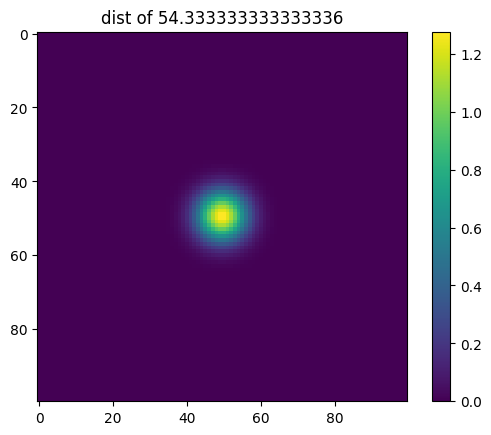

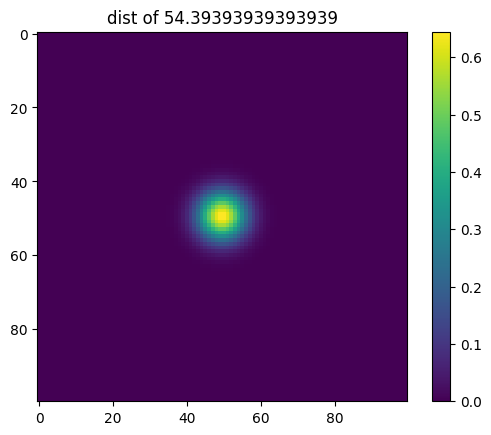

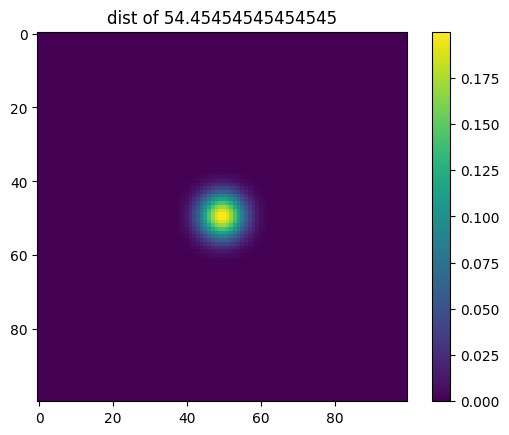

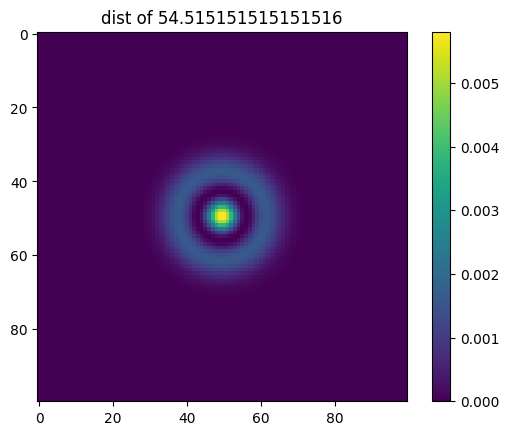

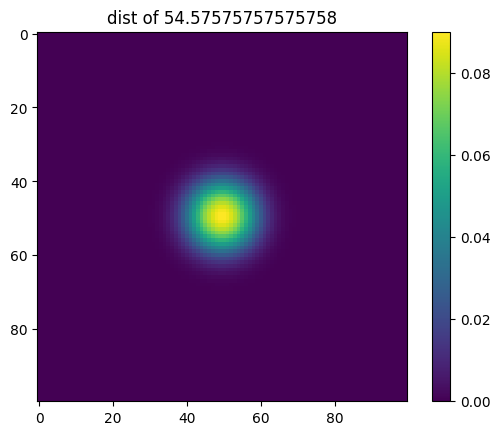

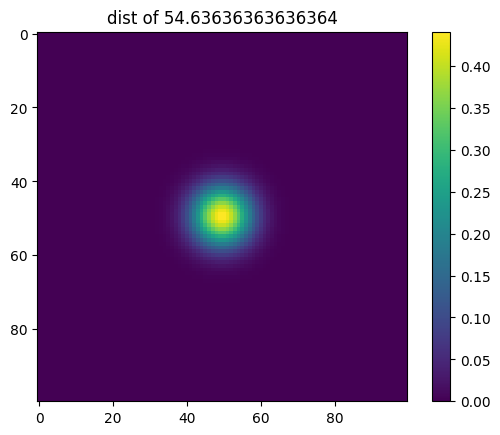

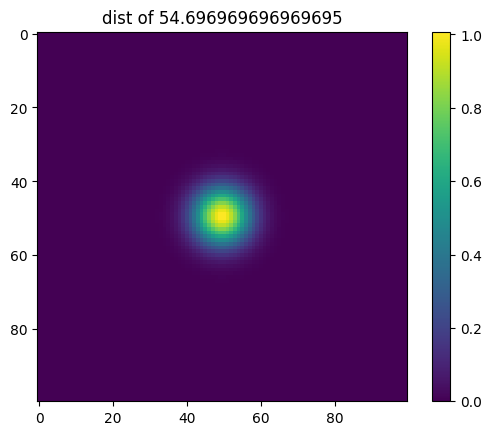

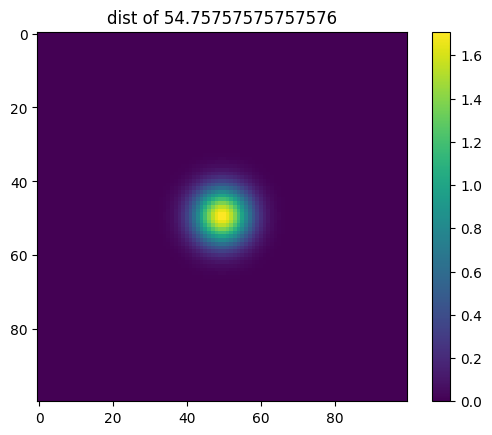

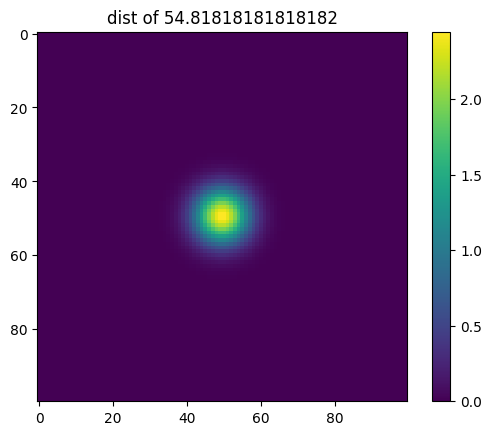

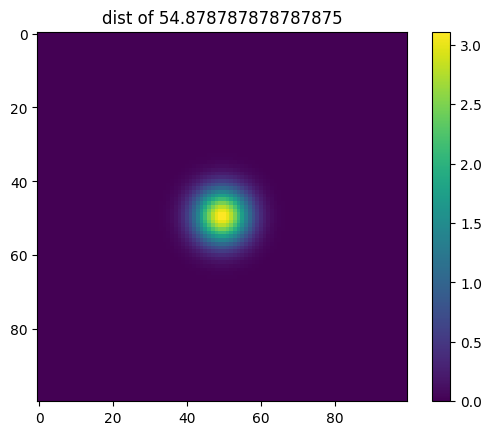

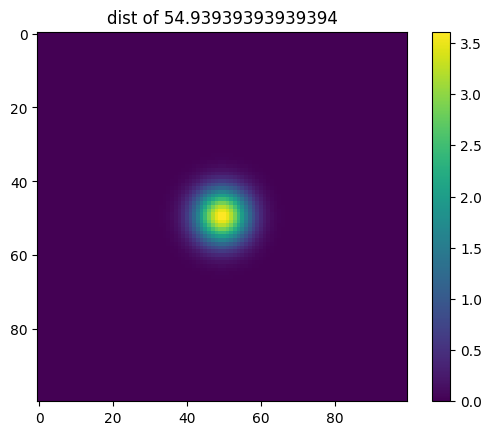

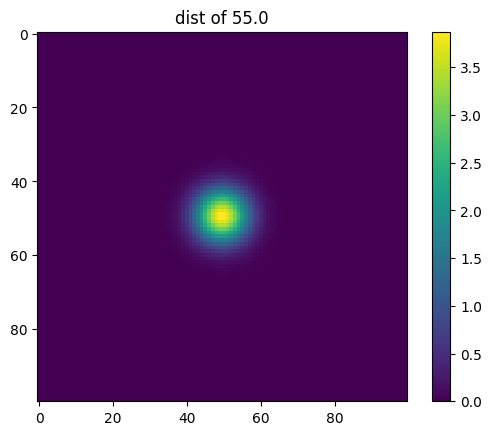

In [ ]:
##### Looking at interference at different distances apart to find dark port

dists_1 = np.linspace(49,55,100)

for dist in dists_1:
  beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100,f_gw=7, t_gw_event=1)
  beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100,f_gw=7,t_gw_event=1)


  # Create the Gaussian fields
  beam_1.E = beam_1.field(beam_1.r_1,z=beam_1.z)
  beam_2.E = beam_2.field(beam_2.r_2,z=beam_2.z)

  beam_1.propagation(dist)
  beam_2.propagation(0)


  E_1_propagated = beam_1.E
  E_2_propagated = beam_2.E

  I = np.abs(E_1_propagated + E_2_propagated)**2

  plt.imshow(I)
  plt.title(f'dist of {dist}')
  plt.colorbar()
  plt.show()






# Comparing LG and Gaussian beams at different distances to see differences in sensitivity by doing difference imaging

## With GW wave included at p = 0, l = $ \pm$ 2

Distance = 0.00 m
LG quadrant intensity       = 1.3092e-10
Gaussian quadrant intensity = 2.8666e-13


/tmp/ipykernel_1652/3232603030.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


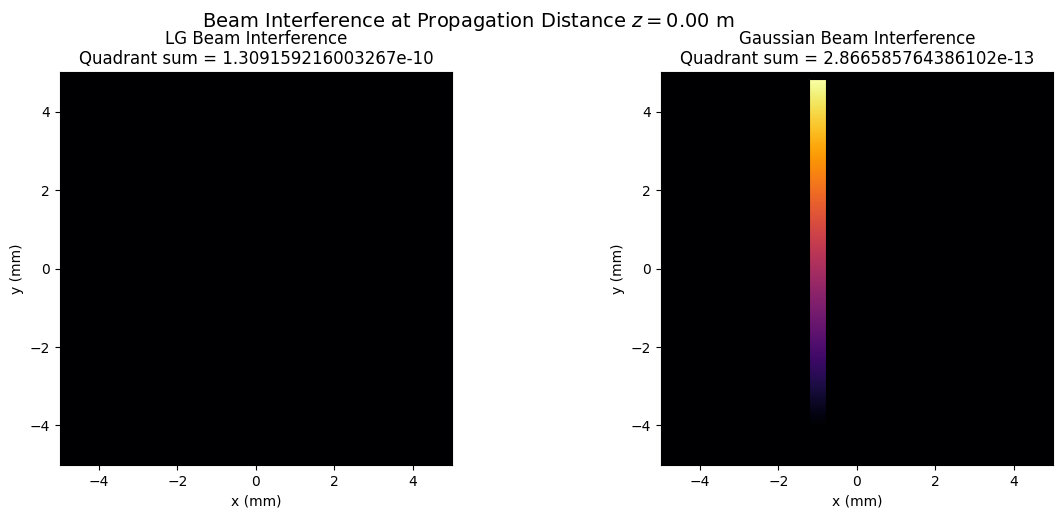

Distance = 1.00 m
LG quadrant intensity       = 1.8873e-05
Gaussian quadrant intensity = -4.8748e-03


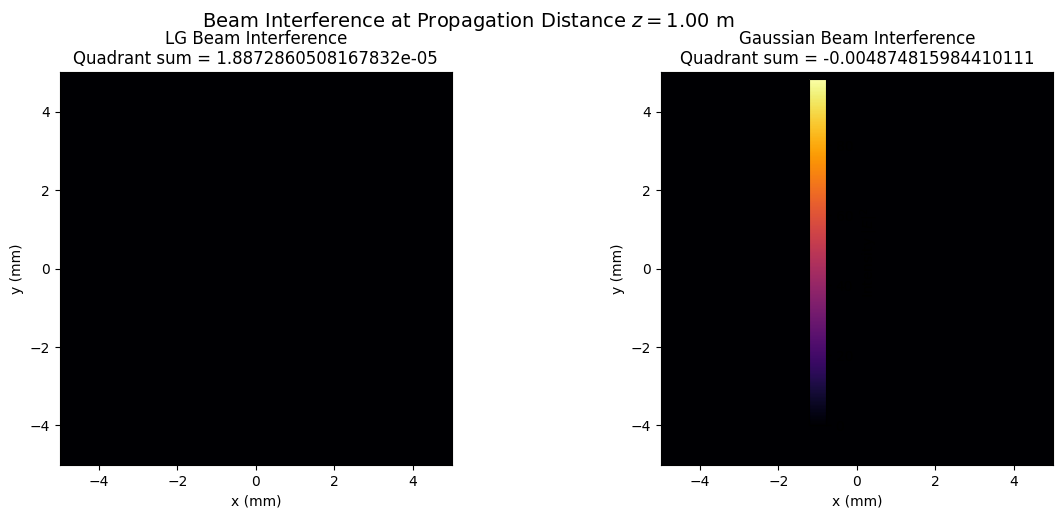

Distance = 2.00 m
LG quadrant intensity       = 7.5491e-05
Gaussian quadrant intensity = -1.9499e-02


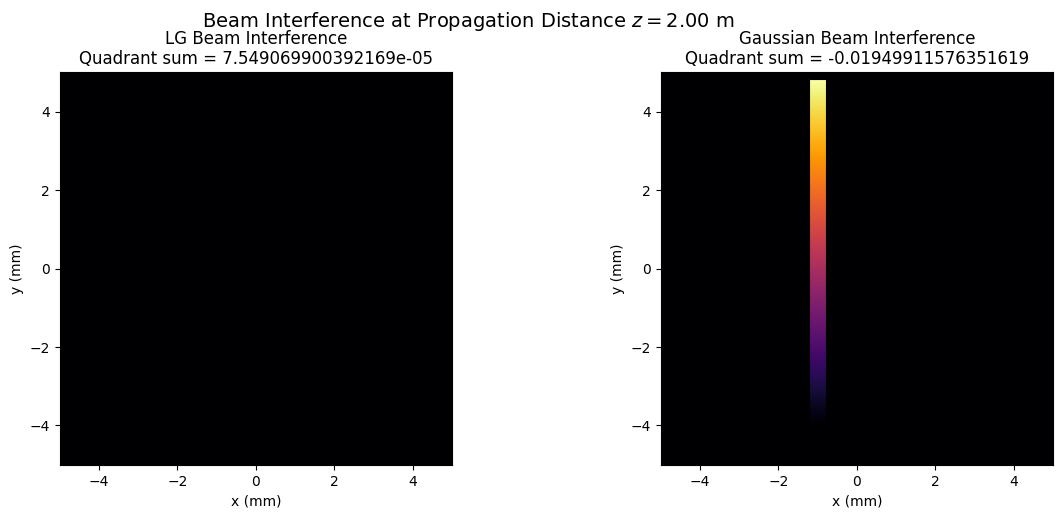

Distance = 3.00 m
LG quadrant intensity       = 1.5477e-04
Gaussian quadrant intensity = -4.3873e-02


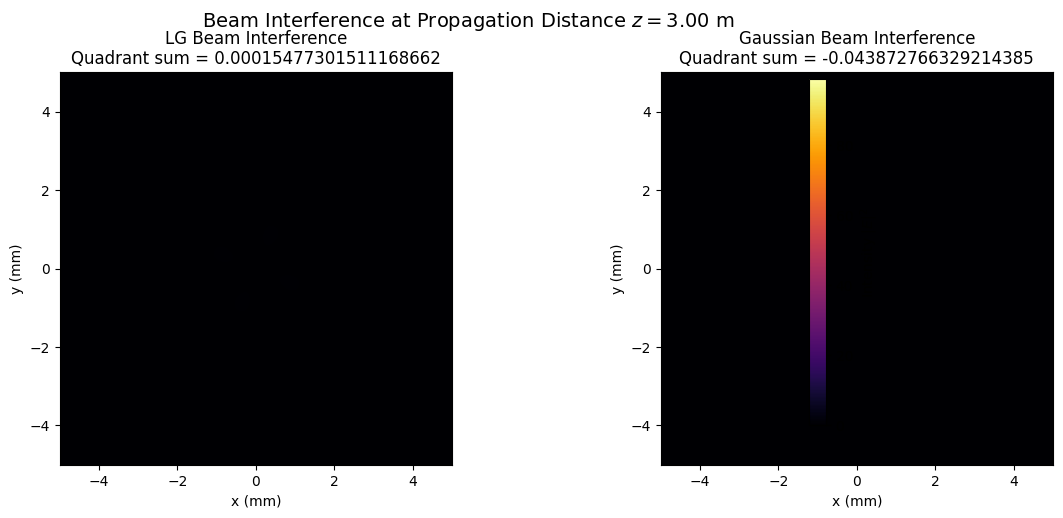

Distance = 4.00 m
LG quadrant intensity       = 3.0196e-04
Gaussian quadrant intensity = -7.7994e-02


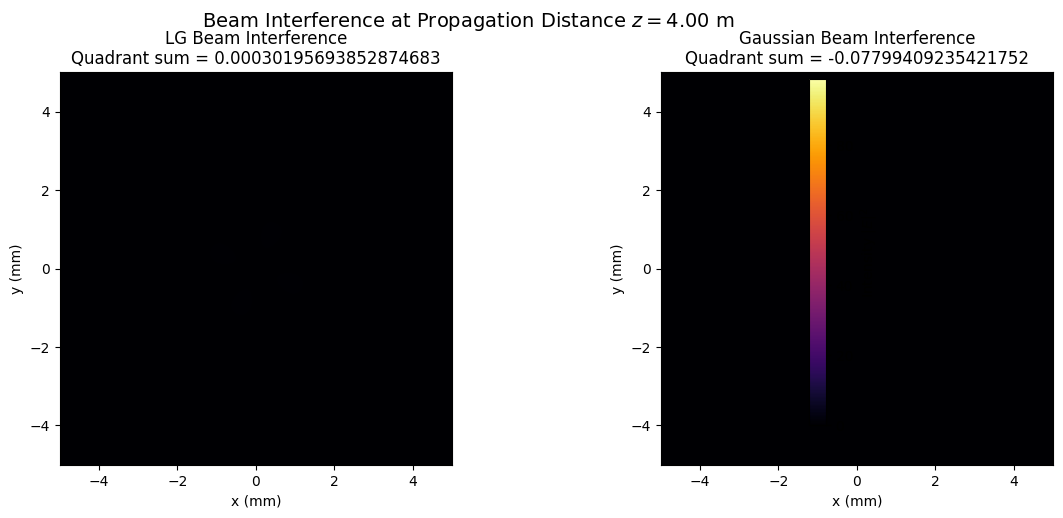

Distance = 5.00 m
LG quadrant intensity       = 5.6814e-04
Gaussian quadrant intensity = -1.2186e-01


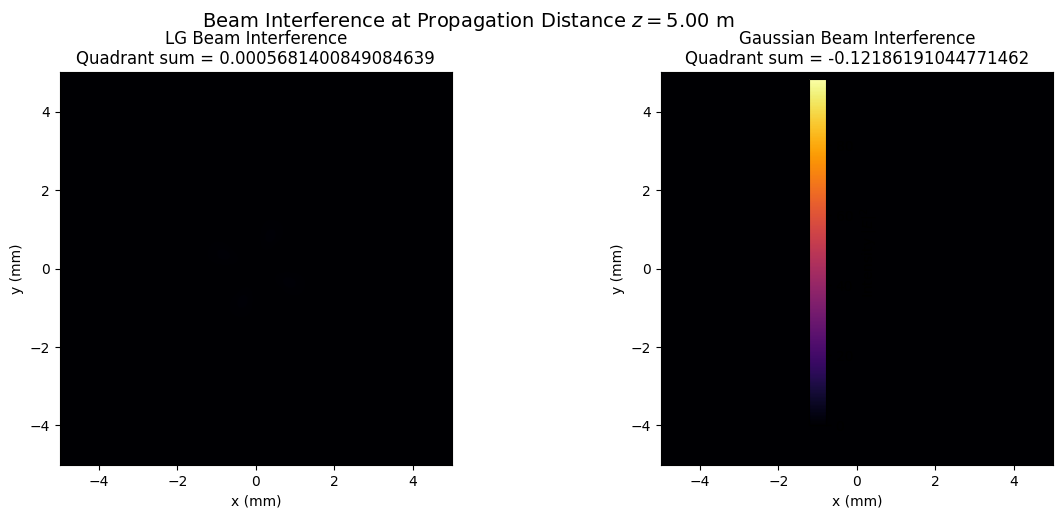

Distance = 6.00 m
LG quadrant intensity       = 6.1909e-04
Gaussian quadrant intensity = -1.7548e-01


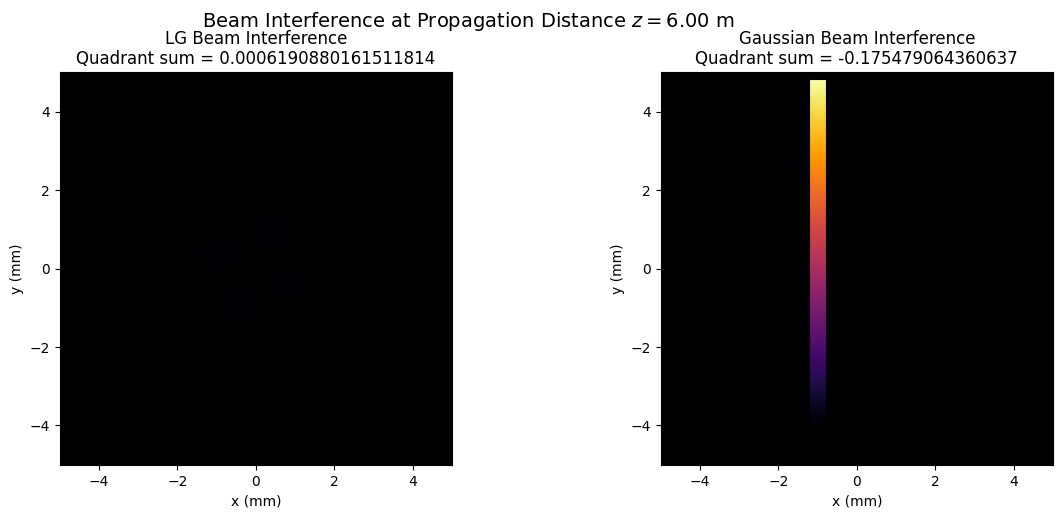

Distance = 7.00 m
LG quadrant intensity       = 1.1263e-03
Gaussian quadrant intensity = -2.3884e-01


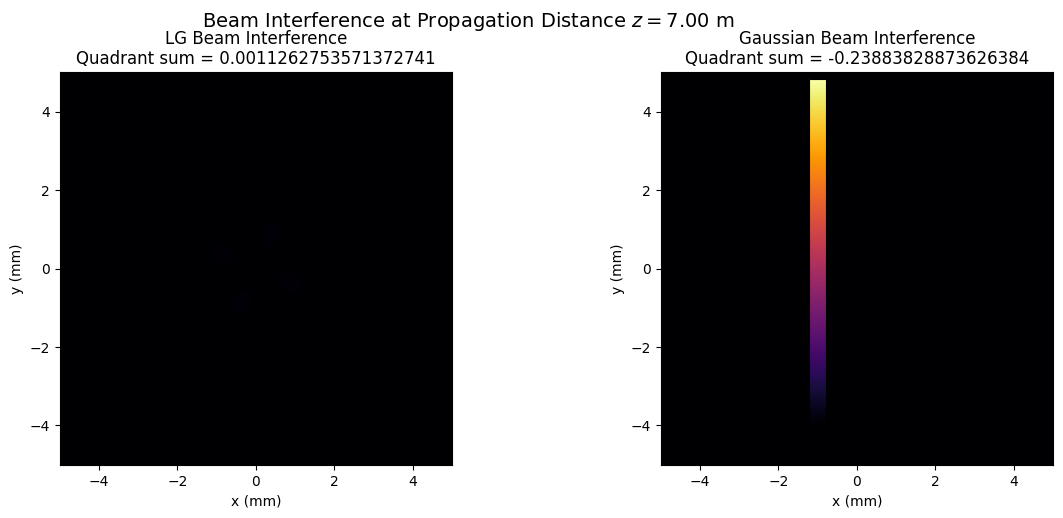

Distance = 8.00 m
LG quadrant intensity       = 1.2077e-03
Gaussian quadrant intensity = -3.1194e-01


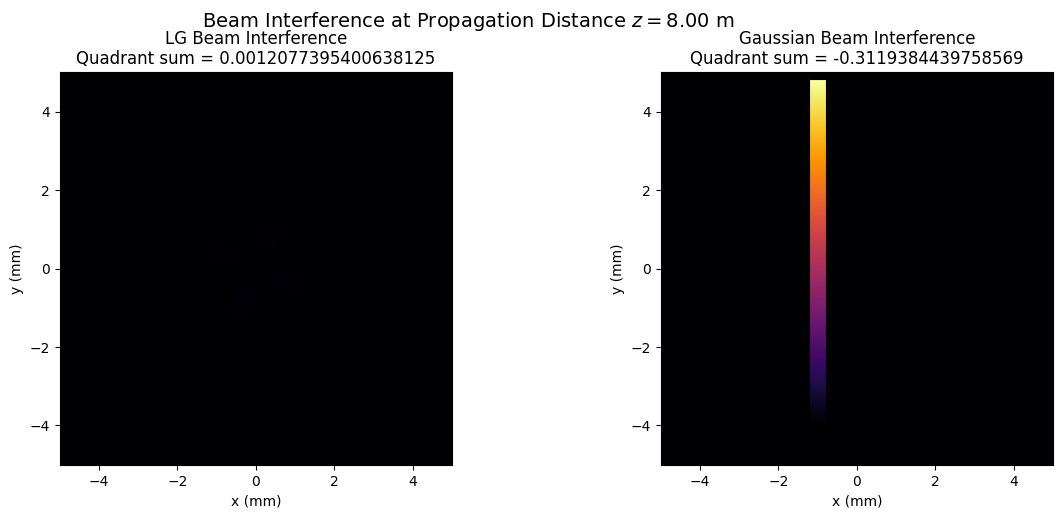

Distance = 9.00 m
LG quadrant intensity       = 1.2694e-03
Gaussian quadrant intensity = -3.9478e-01


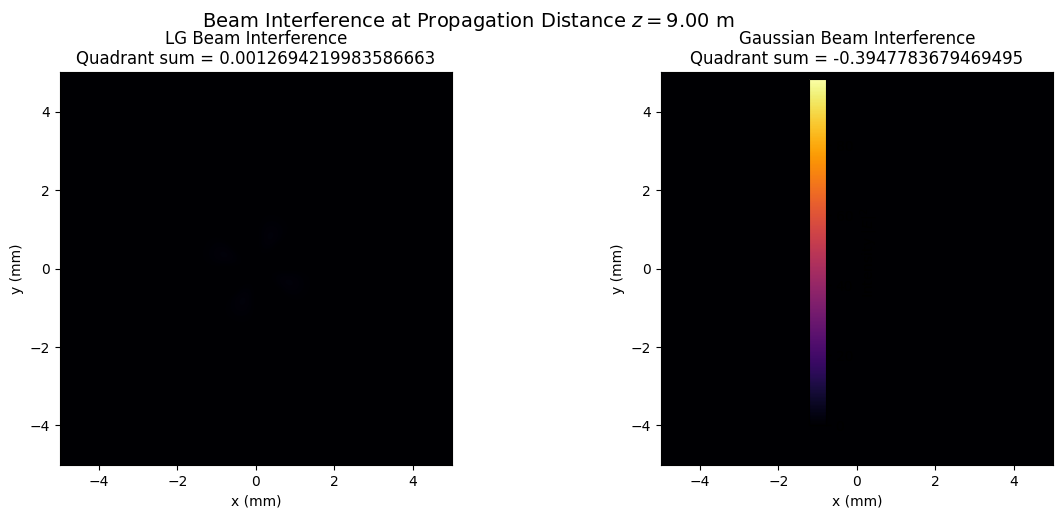

Distance = 10.00 m
LG quadrant intensity       = 2.2724e-03
Gaussian quadrant intensity = -4.8736e-01


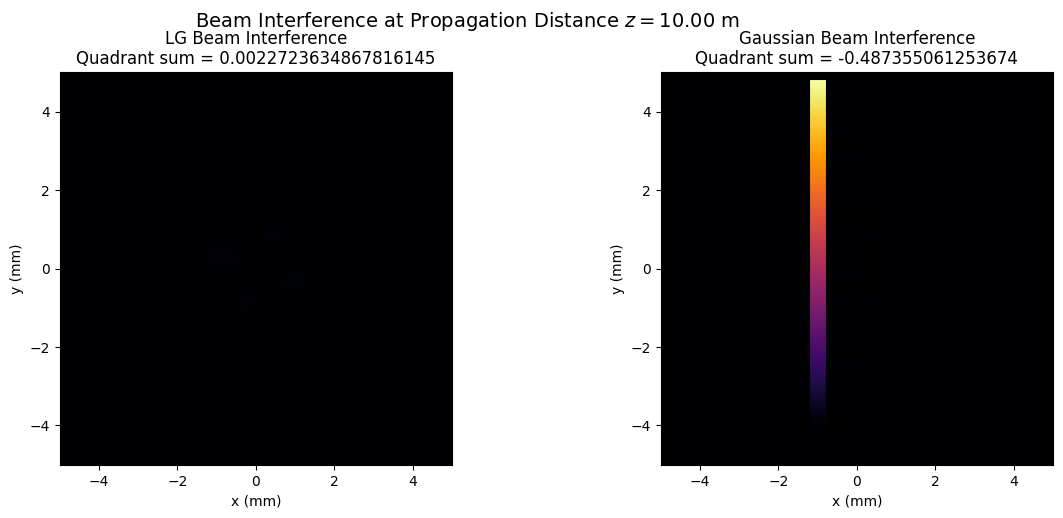

"\n  ############# Plotting \n\n  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2\n  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2\n\n  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])\n  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])\n\n  print(quad_sum_LG)\n  print(quad_sum_G)\n\n  plt.imshow(LG_I)\n  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')\n  plt.colorbar()\n  plt.show()\n\n  plt.imshow(G_I)\n  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')\n  plt.colorbar()\n  plt.show()"

In [ ]:
################### Producing intensity arrays/plots to do difference imaging
E_0 = 5

Lg_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=E_0)
Lg_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=E_0)
Lg_beam_1.E = Lg_beam_1.field( Lg_beam_1.r_1, np.arctan2(Lg_beam_1.Y, Lg_beam_1.X), z=Lg_beam_1.z, p=0, l = 2)
Lg_beam_2.E = Lg_beam_2.field( Lg_beam_2.r_2, np.arctan2(Lg_beam_2.Y - Lg_beam_2.dy, Lg_beam_2.X - Lg_beam_2.dx), z=Lg_beam_2.z, p=0, l=-2)
Lg_I = np.abs(Lg_beam_1.E + Lg_beam_2.E)**2

###################### Gaussian beam for difference imaging


g_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=E_0 ,w_0=1e-3,points=100)
g_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=E_0 ,w_0=1e-3,points=100)
g_beam_1.E = g_beam_1.field(g_beam_1.r_1,z=g_beam_1.z)
g_beam_2.E = g_beam_2.field(g_beam_2.r_2,z=g_beam_2.z)

g_I = np.abs(g_beam_1.E + g_beam_2.E)**2

#################################################################
dists = np.linspace(0,10,11) ##  arm lengths changing from 0 to 10 meters

for dist in dists:
  ############### LG beams
  LG_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=E_0)
  LG_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=E_0)

  LG_beam_1.E = LG_beam_1.field( LG_beam_1.r_1, np.arctan2(LG_beam_1.Y, LG_beam_1.X), z=LG_beam_1.z, p=0, l=2 )
  LG_beam_2.E = LG_beam_2.field( LG_beam_2.r_2, np.arctan2(LG_beam_2.Y - LG_beam_2.dy, LG_beam_2.X - LG_beam_2.dx), z=LG_beam_2.z, p=0, l=-2)

  LG_beam_1.propagation(dist)
  LG_beam_2.propagation(0)

  LG_beam_1.gw_phase(dist)

  LG_E_1_propagated = LG_beam_1.E
  LG_E_2_propagated = LG_beam_2.E

  ########## Gaussian beams

  G_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=E_0,w_0=1e-3,points=100)
  G_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=E_0,w_0=1e-3,points=100)

  G_beam_1.E = G_beam_1.field(G_beam_1.r_1,z=G_beam_1.z)
  G_beam_2.E = G_beam_2.field(G_beam_2.r_2,z=G_beam_2.z)

  G_beam_1.propagation(dist)
  G_beam_2.propagation(0)

  G_beam_1.gw_phase(dist)

  G_E_1_propagated = G_beam_1.E
  G_E_2_propagated = G_beam_2.E

       # ---------------- Plotting ----------------
  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I  = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  LG_I_diff_img = LG_I - Lg_I
  G_I_diff_img = G_I - g_I

  # Sum of intensity in the top-left quadrant
  quad_sum_LG = np.sum(LG_I_diff_img[:len(LG_I)//2, :len(LG_I)//2])
  quad_sum_G  = np.sum(G_I_diff_img[:len(G_I)//2, :len(G_I)//2])

  print(f"Distance = {dist:.2f} m")
  print(f"LG quadrant intensity       = {quad_sum_LG:.4e}")
  print(f"Gaussian quadrant intensity = {quad_sum_G:.4e}")

  # ------------------------------------------------
  # Create figure with two side-by-side plots
  # ------------------------------------------------

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # Use the same intensity scale for both plots
  vmax = max(LG_I.max(), G_I.max())

  # LG plot
  im1 = axes[0].imshow(
    LG_I_diff_img,
    origin='lower',
    extent=[
        LG_beam_1.x.min() * 1e3,
        LG_beam_1.x.max() * 1e3,
        LG_beam_1.y.min() * 1e3,
        LG_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[0].set_title(
    f'LG Beam Interference\n'
    f'Quadrant sum = {quad_sum_LG}'
)

  axes[0].set_xlabel('x (mm)')
  axes[0].set_ylabel('y (mm)')

# Gaussian plot
  im2 = axes[1].imshow(
    G_I_diff_img,
    origin='lower',
    extent=[
        G_beam_1.x.min() * 1e3,
        G_beam_1.x.max() * 1e3,
        G_beam_1.y.min() * 1e3,
        G_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[1].set_title(
    f'Gaussian Beam Interference\n'
    f'Quadrant sum = {quad_sum_G}'
)

  axes[1].set_xlabel('x (mm)')
  axes[1].set_ylabel('y (mm)')

  # One shared colourbar
  cbar = fig.colorbar(im2, ax=axes, shrink=0.9)
  cbar.set_label(r'Intensity $|E|^2$')

  # Overall title
  fig.suptitle(
    f'Beam Interference at Propagation Distance $z = {dist:.2f}$ m',
    fontsize=14
)

  plt.tight_layout()
  plt.show()






'''
  ############# Plotting

  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])
  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])

  print(quad_sum_LG)
  print(quad_sum_G)

  plt.imshow(LG_I)
  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')
  plt.colorbar()
  plt.show()

  plt.imshow(G_I)
  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')
  plt.colorbar()
  plt.show()'''

## Without GW wave included with p = 0 and l = $\pm$ 2

Distance = 0.00 m
LG quadrant intensity       = 1.3092e-10
Gaussian quadrant intensity = 2.8666e-13


/tmp/ipykernel_1652/2842416822.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


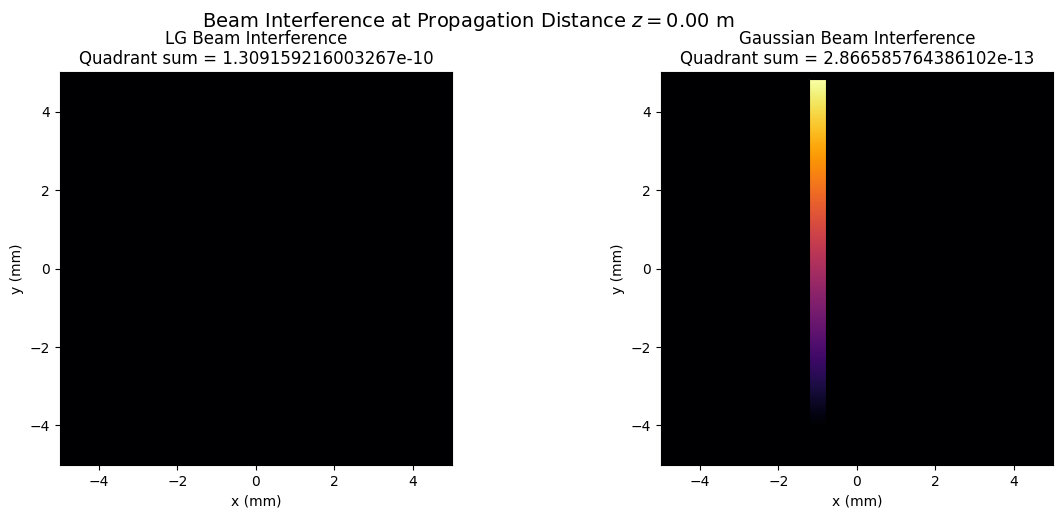

Distance = 1.00 m
LG quadrant intensity       = 1.8873e-05
Gaussian quadrant intensity = -4.8748e-03


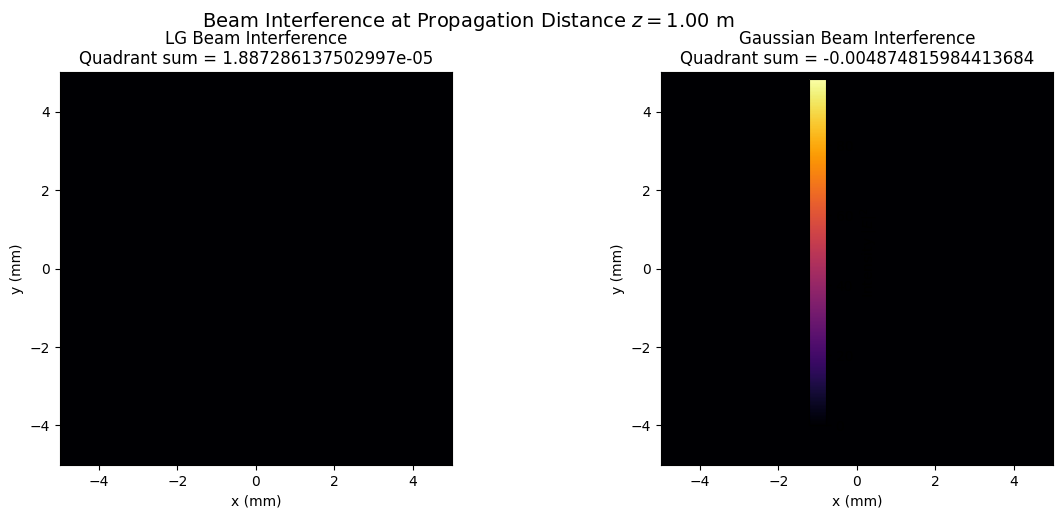

Distance = 2.00 m
LG quadrant intensity       = 7.5491e-05
Gaussian quadrant intensity = -1.9499e-02


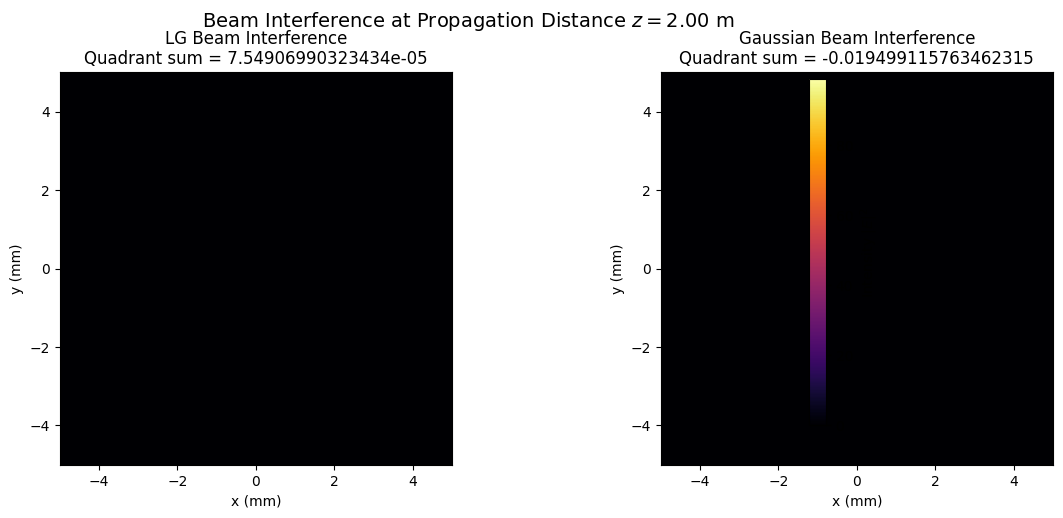

Distance = 3.00 m
LG quadrant intensity       = 1.5477e-04
Gaussian quadrant intensity = -4.3873e-02


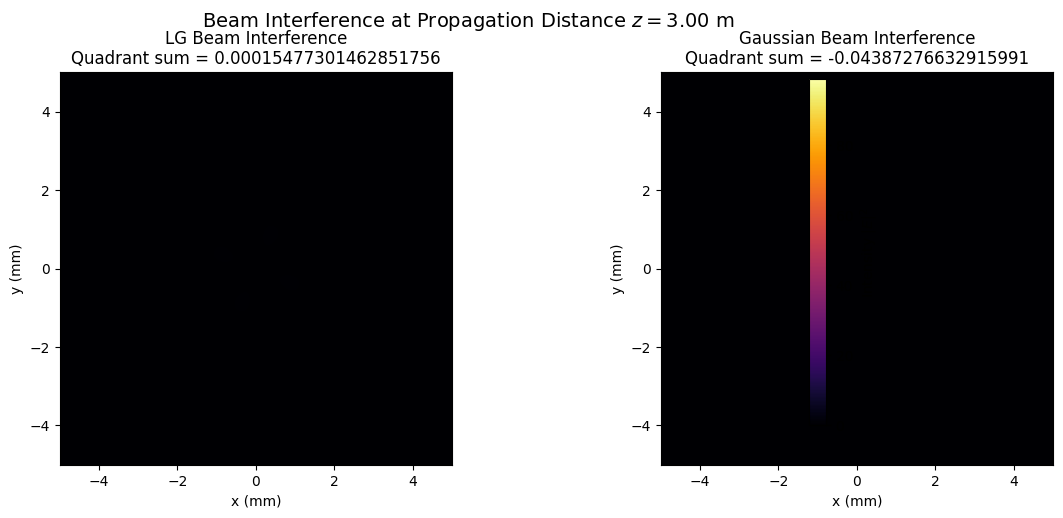

Distance = 4.00 m
LG quadrant intensity       = 3.0196e-04
Gaussian quadrant intensity = -7.7994e-02


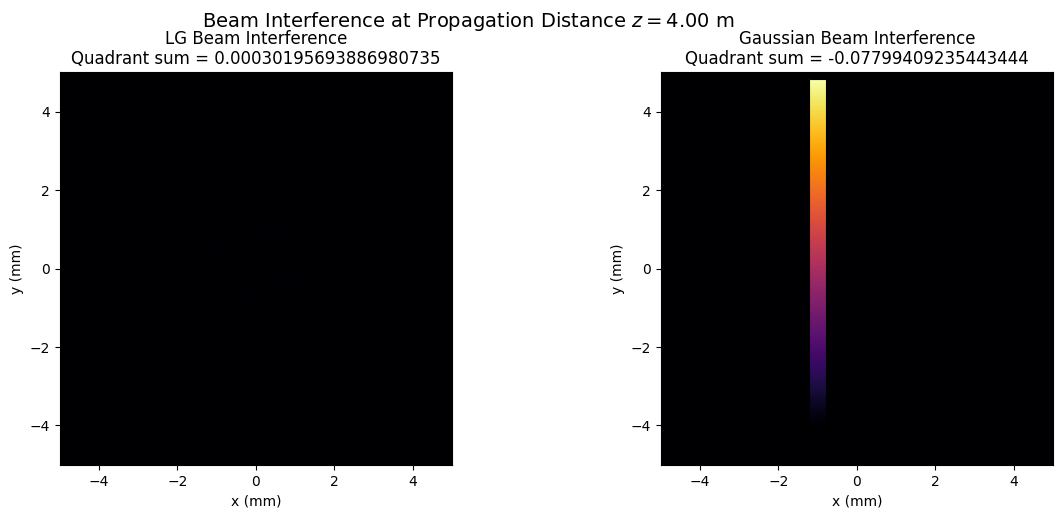

Distance = 5.00 m
LG quadrant intensity       = 5.6814e-04
Gaussian quadrant intensity = -1.2186e-01


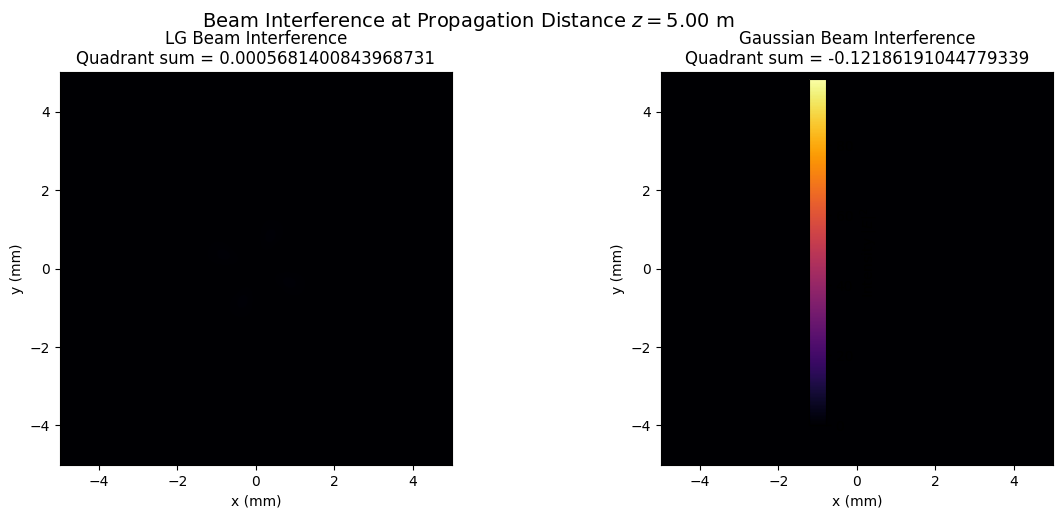

Distance = 6.00 m
LG quadrant intensity       = 6.1909e-04
Gaussian quadrant intensity = -1.7548e-01


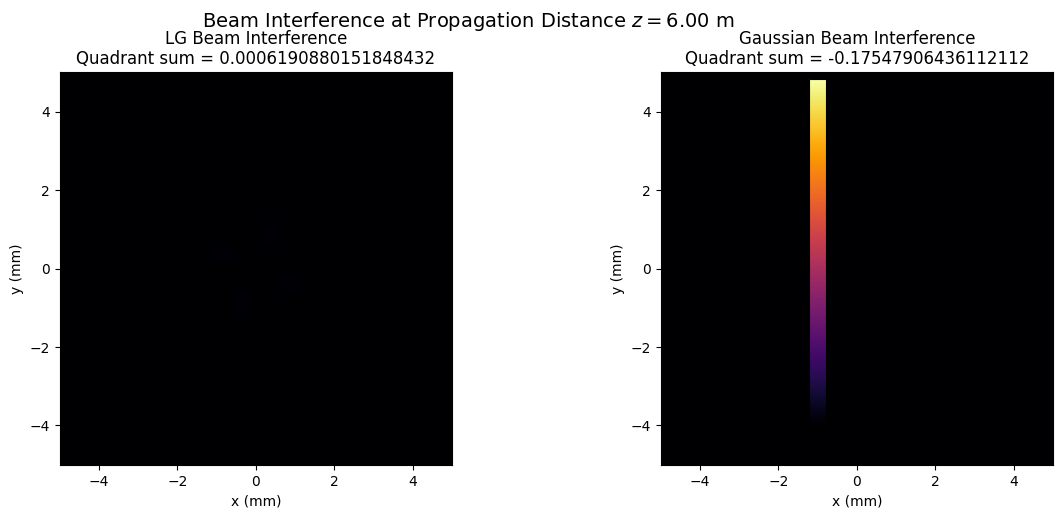

Distance = 7.00 m
LG quadrant intensity       = 1.1263e-03
Gaussian quadrant intensity = -2.3884e-01


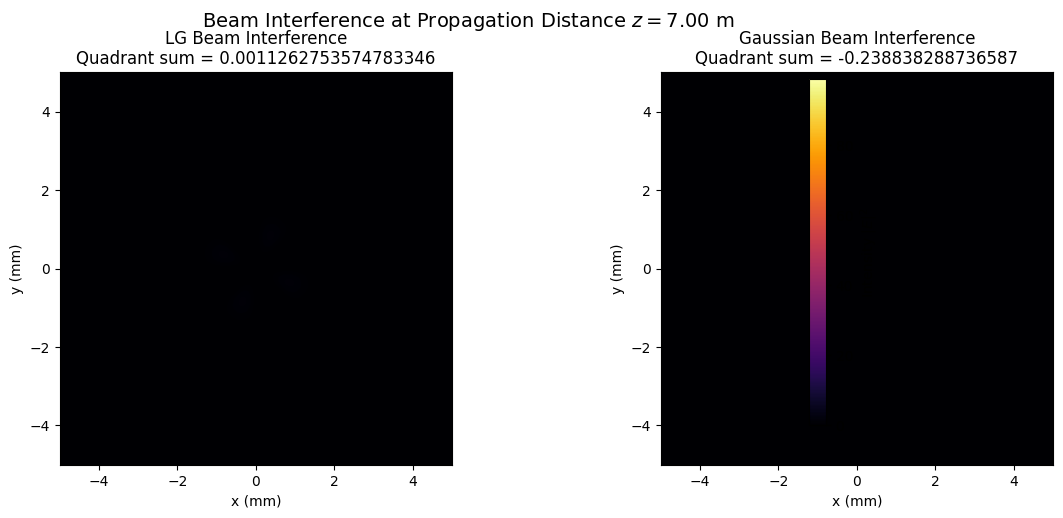

Distance = 8.00 m
LG quadrant intensity       = 1.2077e-03
Gaussian quadrant intensity = -3.1194e-01


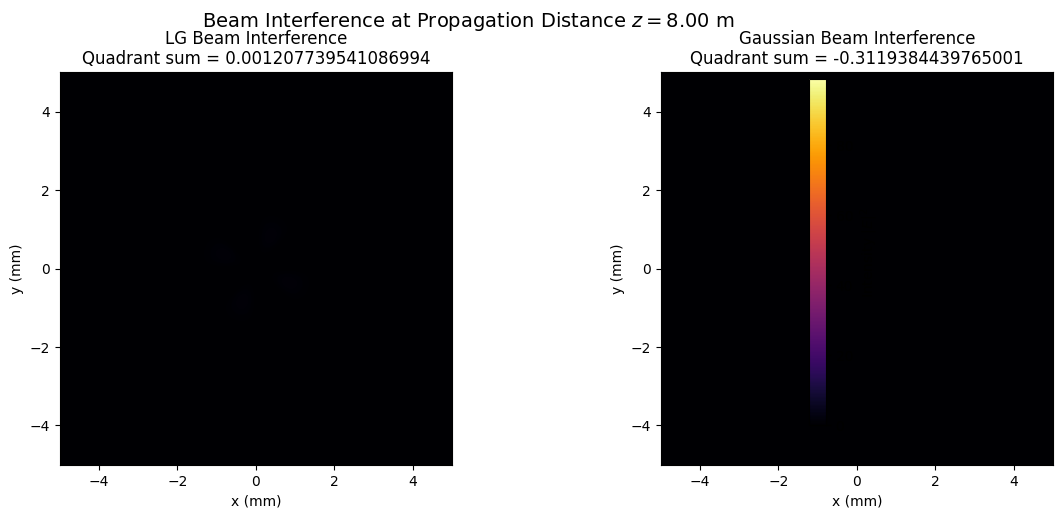

Distance = 9.00 m
LG quadrant intensity       = 1.2694e-03
Gaussian quadrant intensity = -3.9478e-01


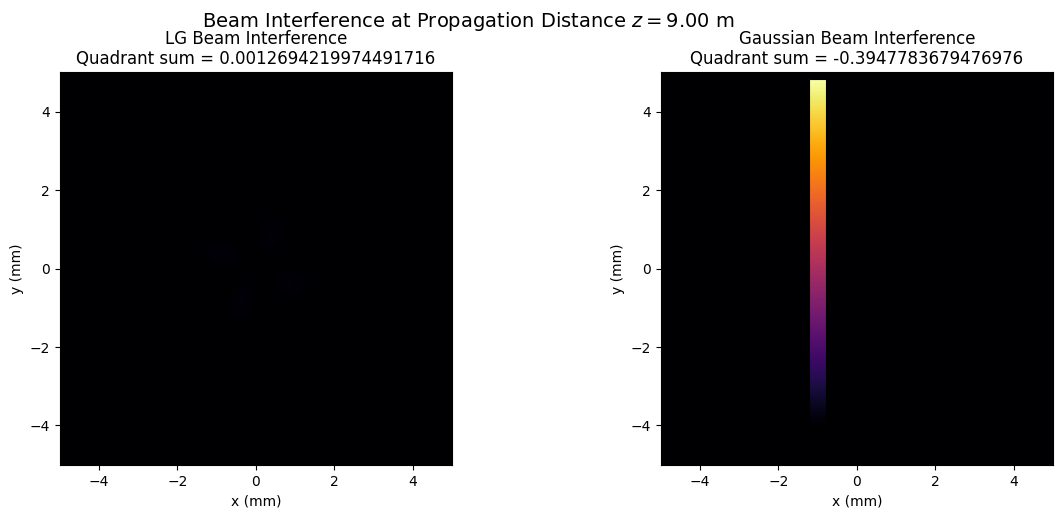

Distance = 10.00 m
LG quadrant intensity       = 2.2724e-03
Gaussian quadrant intensity = -4.8736e-01


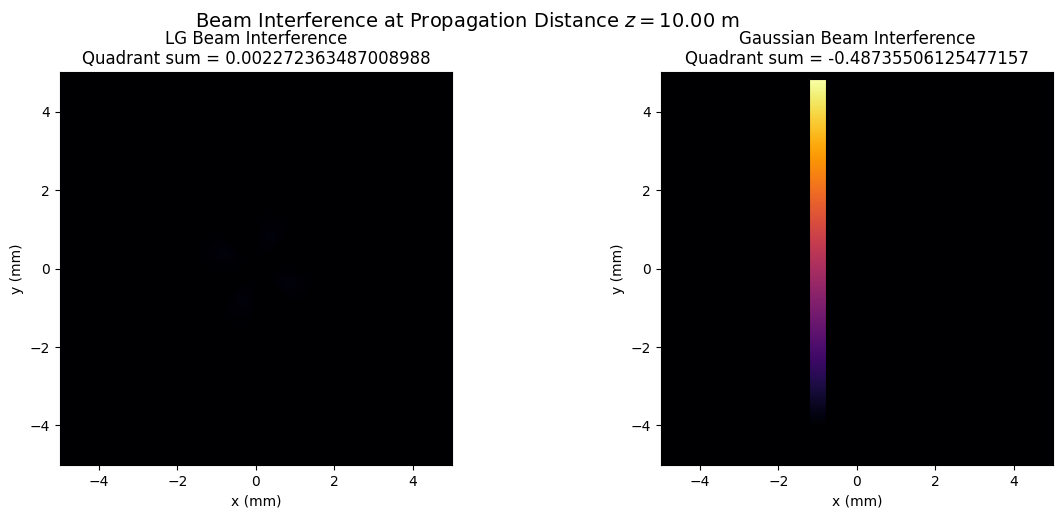

"\n  ############# Plotting \n\n  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2\n  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2\n\n  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])\n  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])\n\n  print(quad_sum_LG)\n  print(quad_sum_G)\n\n  plt.imshow(LG_I)\n  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')\n  plt.colorbar()\n  plt.show()\n\n  plt.imshow(G_I)\n  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')\n  plt.colorbar()\n  plt.show()"

In [ ]:
################### Producing intensity arrays/plots to do difference imaging

Lg_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=5)
Lg_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=5)
Lg_beam_1.E = Lg_beam_1.field( Lg_beam_1.r_1, np.arctan2(Lg_beam_1.Y, Lg_beam_1.X), z=Lg_beam_1.z, p=0, l = 2)
Lg_beam_2.E = Lg_beam_2.field( Lg_beam_2.r_2, np.arctan2(Lg_beam_2.Y - Lg_beam_2.dy, Lg_beam_2.X - Lg_beam_2.dx), z=Lg_beam_2.z, p=0, l=-2)
Lg_I = np.abs(Lg_beam_1.E + Lg_beam_2.E)**2

###################### Gaussian beam for difference imaging


g_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=5,w_0=1e-3,points=100)
g_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=5,w_0=1e-3,points=100)
g_beam_1.E = g_beam_1.field(g_beam_1.r_1,z=g_beam_1.z)
g_beam_2.E = g_beam_2.field(g_beam_2.r_2,z=g_beam_2.z)

g_I = np.abs(g_beam_1.E + g_beam_2.E)**2

#################################################################
dists = np.linspace(0,10,11) ##  arm lengths changing from 0 to 10 meters

for dist in dists:
  ############### LG beams
  LG_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=5)
  LG_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=5)

  LG_beam_1.E = LG_beam_1.field( LG_beam_1.r_1, np.arctan2(LG_beam_1.Y, LG_beam_1.X), z=LG_beam_1.z, p=0, l=2 )
  LG_beam_2.E = LG_beam_2.field( LG_beam_2.r_2, np.arctan2(LG_beam_2.Y - LG_beam_2.dy, LG_beam_2.X - LG_beam_2.dx), z=LG_beam_2.z, p=0, l=-2)

  LG_beam_1.propagation(dist)
  LG_beam_2.propagation(0)

  #LG_beam_1.gw_phase(dist)

  LG_E_1_propagated = LG_beam_1.E
  LG_E_2_propagated = LG_beam_2.E

  ########## Gaussian beams

  G_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=5,w_0=1e-3,points=100)
  G_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=5,w_0=1e-3,points=100)

  G_beam_1.E = G_beam_1.field(G_beam_1.r_1,z=G_beam_1.z)
  G_beam_2.E = G_beam_2.field(G_beam_2.r_2,z=G_beam_2.z)

  G_beam_1.propagation(dist)
  G_beam_2.propagation(0)

  #G_beam_1.gw_phase(dist)

  G_E_1_propagated = G_beam_1.E
  G_E_2_propagated = G_beam_2.E

       # ---------------- Plotting ----------------
  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I  = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  LG_I_diff_img = LG_I - Lg_I
  G_I_diff_img = G_I - g_I

  # Sum of intensity in the top-left quadrant
  quad_sum_LG = np.sum(LG_I_diff_img[:len(LG_I)//2, :len(LG_I)//2])
  quad_sum_G  = np.sum(G_I_diff_img[:len(G_I)//2, :len(G_I)//2])

  print(f"Distance = {dist:.2f} m")
  print(f"LG quadrant intensity       = {quad_sum_LG:.4e}")
  print(f"Gaussian quadrant intensity = {quad_sum_G:.4e}")

  # ------------------------------------------------
  # Create figure with two side-by-side plots
  # ------------------------------------------------

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # Use the same intensity scale for both plots
  vmax = max(LG_I.max(), G_I.max())

  # LG plot
  im1 = axes[0].imshow(
    LG_I_diff_img,
    origin='lower',
    extent=[
        LG_beam_1.x.min() * 1e3,
        LG_beam_1.x.max() * 1e3,
        LG_beam_1.y.min() * 1e3,
        LG_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[0].set_title(
    f'LG Beam Interference\n'
    f'Quadrant sum = {quad_sum_LG}'
)

  axes[0].set_xlabel('x (mm)')
  axes[0].set_ylabel('y (mm)')

# Gaussian plot
  im2 = axes[1].imshow(
    G_I_diff_img,
    origin='lower',
    extent=[
        G_beam_1.x.min() * 1e3,
        G_beam_1.x.max() * 1e3,
        G_beam_1.y.min() * 1e3,
        G_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[1].set_title(
    f'Gaussian Beam Interference\n'
    f'Quadrant sum = {quad_sum_G}'
)

  axes[1].set_xlabel('x (mm)')
  axes[1].set_ylabel('y (mm)')

  # One shared colourbar
  cbar = fig.colorbar(im2, ax=axes, shrink=0.9)
  cbar.set_label(r'Intensity $|E|^2$')

  # Overall title
  fig.suptitle(
    f'Beam Interference at Propagation Distance $z = {dist:.2f}$ m',
    fontsize=14
)

  plt.tight_layout()
  plt.show()






'''
  ############# Plotting

  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])
  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])

  print(quad_sum_LG)
  print(quad_sum_G)

  plt.imshow(LG_I)
  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')
  plt.colorbar()
  plt.show()

  plt.imshow(G_I)
  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')
  plt.colorbar()
  plt.show()'''

## Trying different values of l $\pm 3 $ at p = 0 with GW wave effect included

Distance = 0.00 m
LG quadrant intensity       = 2.9040e-10
Gaussian quadrant intensity = 7.8203e-15


/tmp/ipykernel_1652/4098149272.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


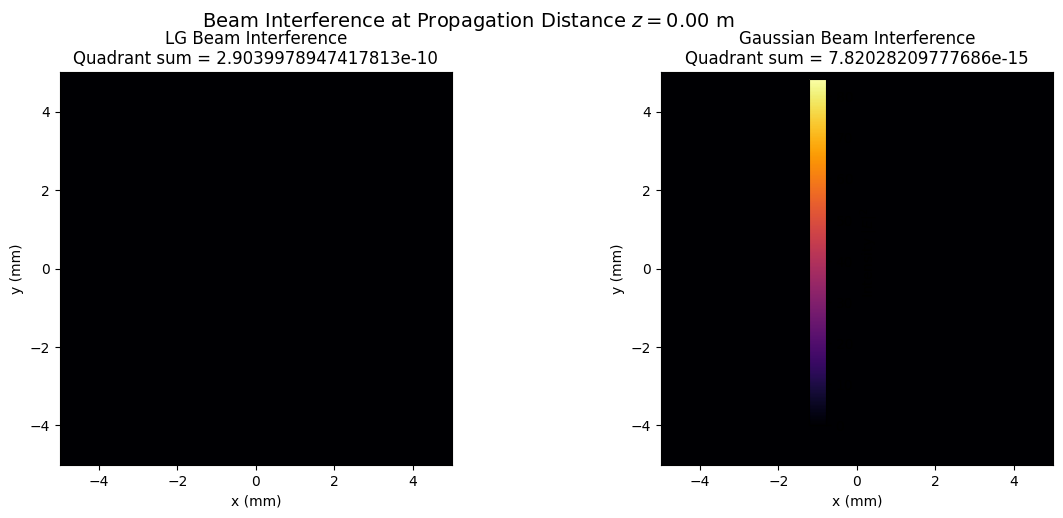

Distance = 1.00 m
LG quadrant intensity       = -1.1994e+03
Gaussian quadrant intensity = -1.9499e-04


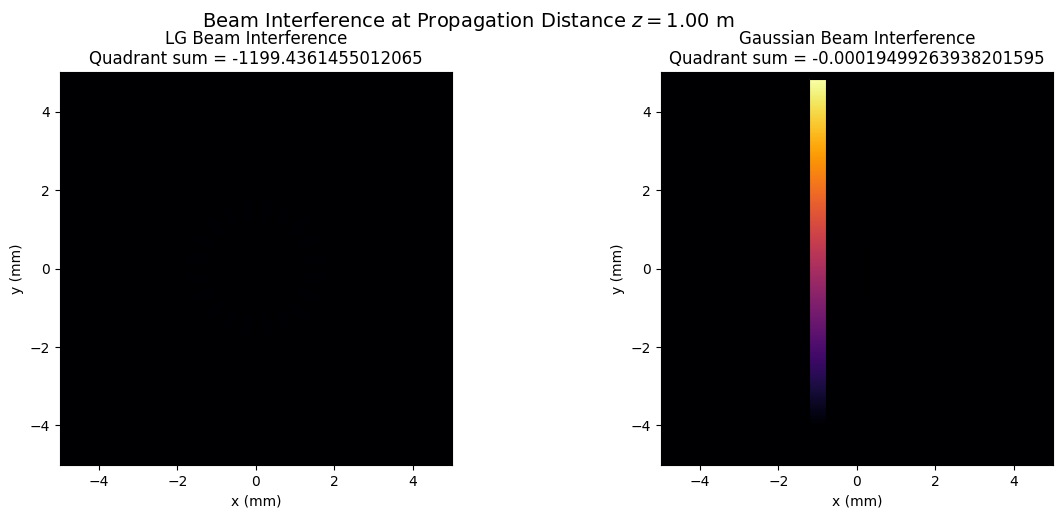

Distance = 2.00 m
LG quadrant intensity       = -2.3987e+03
Gaussian quadrant intensity = -7.7996e-04


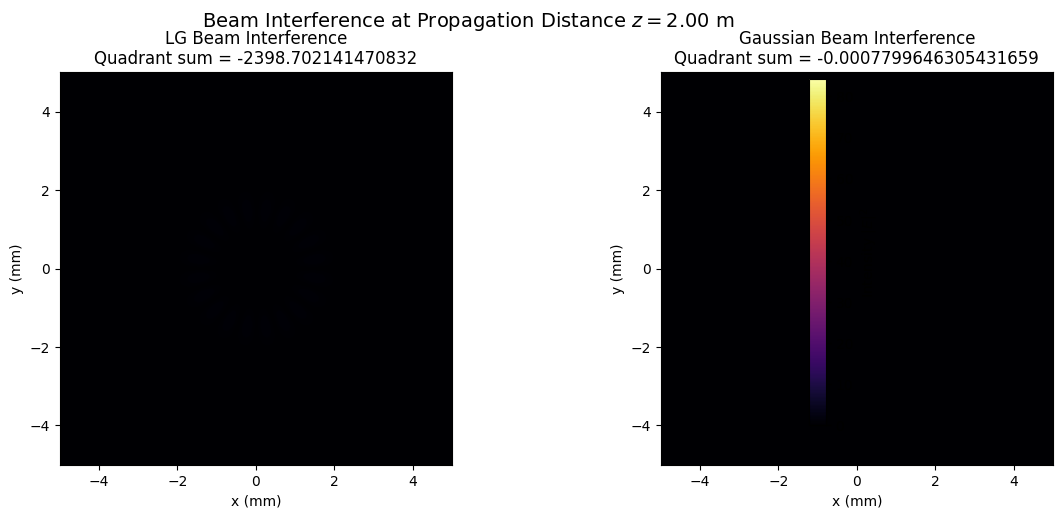

Distance = 3.00 m
LG quadrant intensity       = -3.5976e+03
Gaussian quadrant intensity = -1.7549e-03


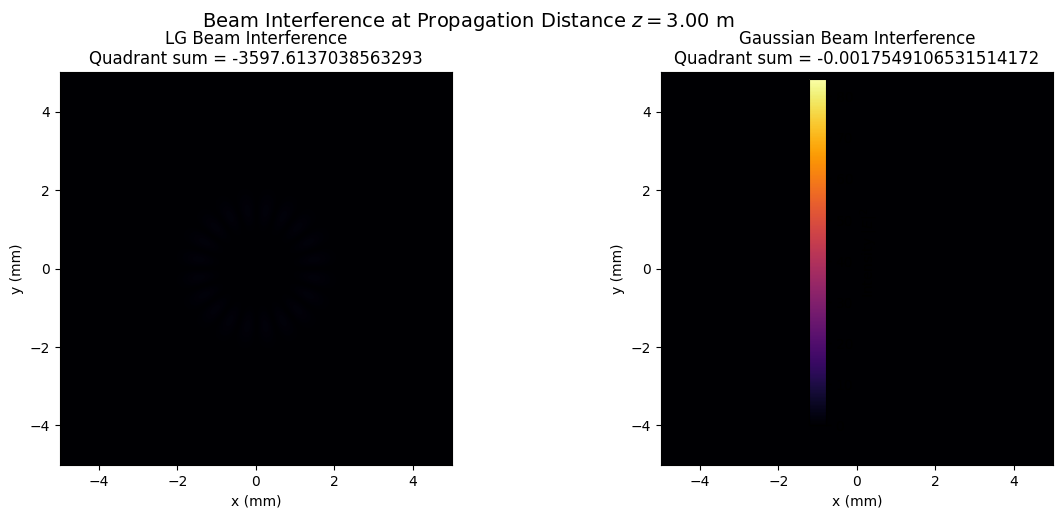

Distance = 4.00 m
LG quadrant intensity       = -4.7960e+03
Gaussian quadrant intensity = -3.1198e-03


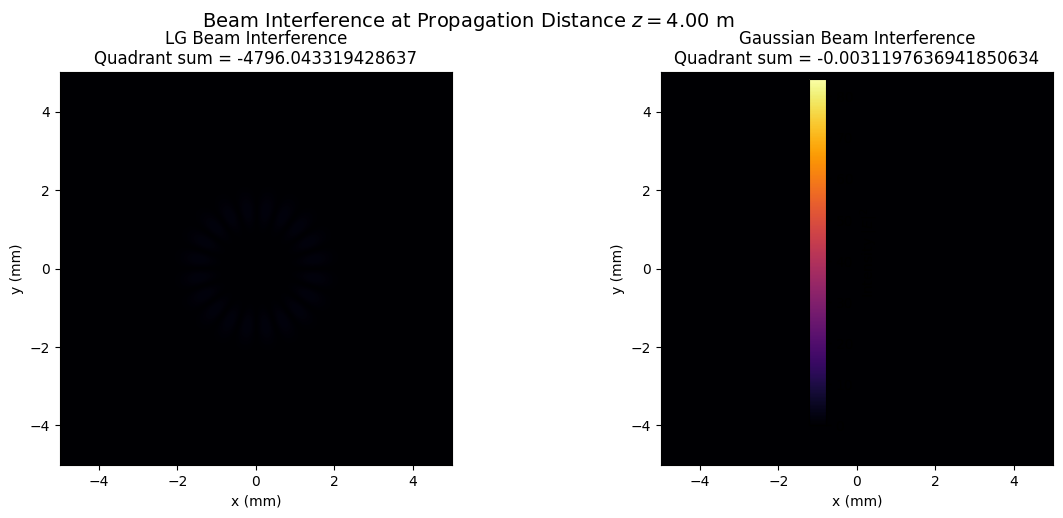

Distance = 5.00 m
LG quadrant intensity       = -5.9938e+03
Gaussian quadrant intensity = -4.8745e-03


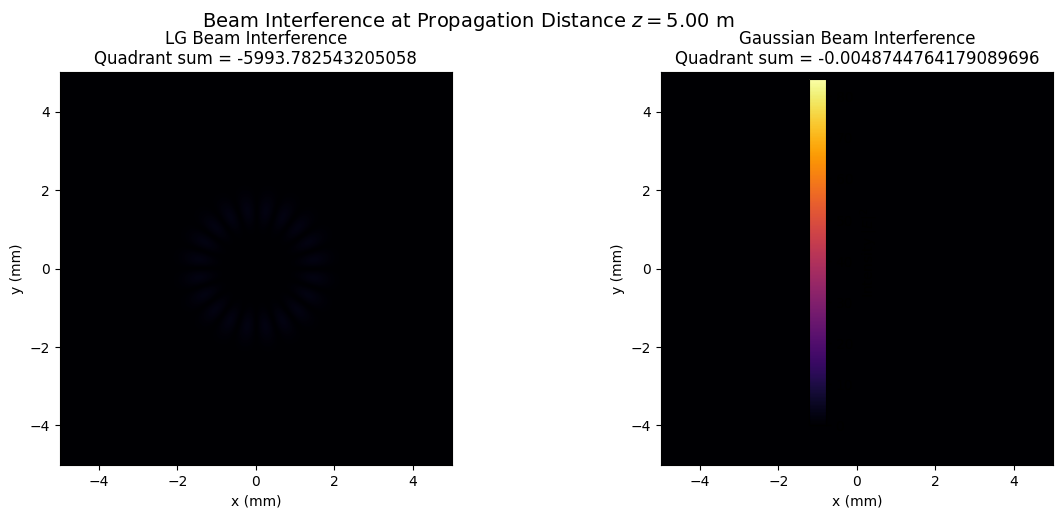

Distance = 6.00 m
LG quadrant intensity       = -7.1906e+03
Gaussian quadrant intensity = -7.0192e-03


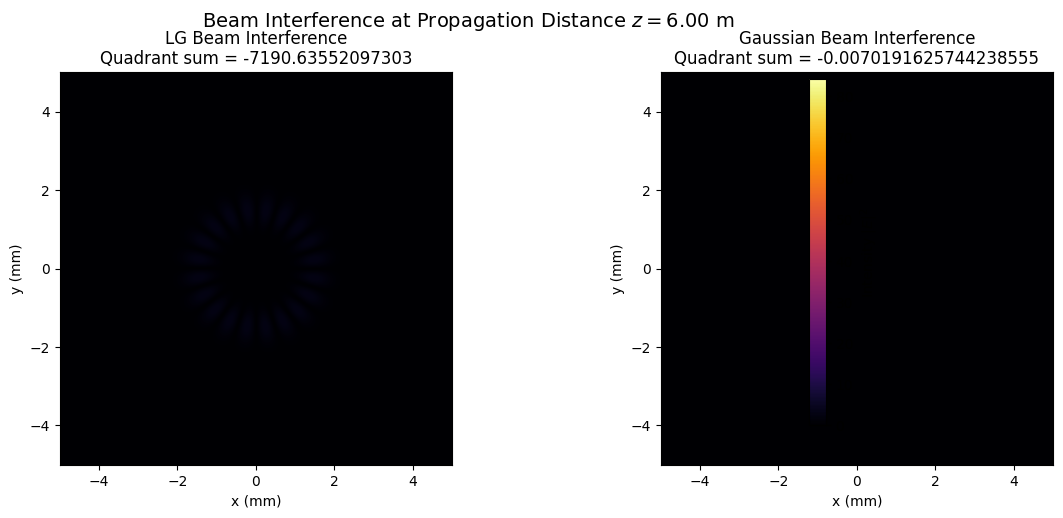

Distance = 7.00 m
LG quadrant intensity       = -8.3866e+03
Gaussian quadrant intensity = -9.5535e-03


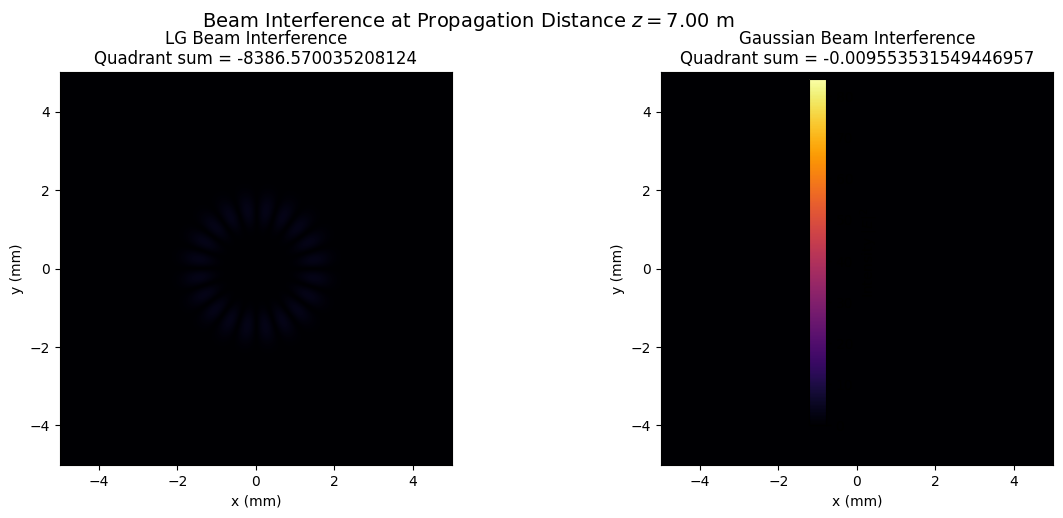

Distance = 8.00 m
LG quadrant intensity       = -9.5812e+03
Gaussian quadrant intensity = -1.2478e-02


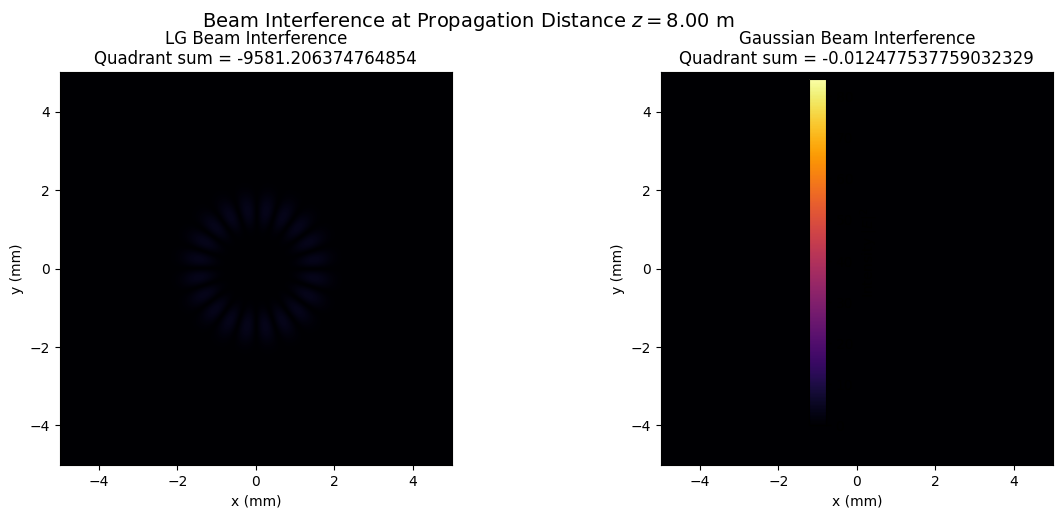

Distance = 9.00 m
LG quadrant intensity       = -1.0774e+04
Gaussian quadrant intensity = -1.5791e-02


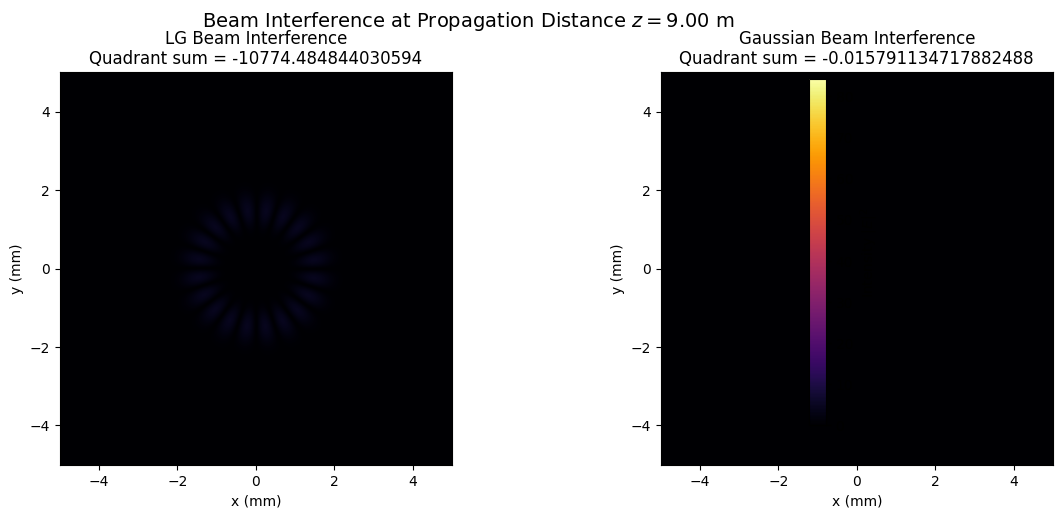

Distance = 10.00 m
LG quadrant intensity       = -1.1966e+04
Gaussian quadrant intensity = -1.9494e-02


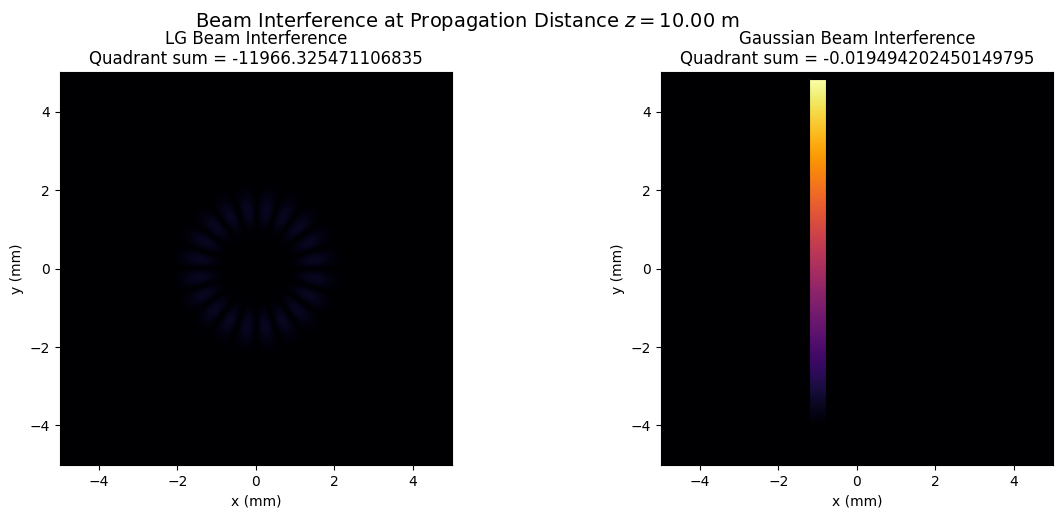

"\n  ############# Plotting \n\n  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2\n  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2\n\n  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])\n  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])\n\n  print(quad_sum_LG)\n  print(quad_sum_G)\n\n  plt.imshow(LG_I)\n  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')\n  plt.colorbar()\n  plt.show()\n\n  plt.imshow(G_I)\n  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')\n  plt.colorbar()\n  plt.show()"

In [ ]:
################### Producing intensity arrays/plots to do difference imaging
l = 5
Lg_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
Lg_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
Lg_beam_1.E = Lg_beam_1.field( Lg_beam_1.r_1, np.arctan2(Lg_beam_1.Y, Lg_beam_1.X), z=Lg_beam_1.z, p=0, l = l)
Lg_beam_2.E = Lg_beam_2.field( Lg_beam_2.r_2, np.arctan2(Lg_beam_2.Y - Lg_beam_2.dy, Lg_beam_2.X - Lg_beam_2.dx), z=Lg_beam_2.z, p=0, l=-l)
Lg_I = np.abs(Lg_beam_1.E + Lg_beam_2.E)**2

###################### Gaussian beam for difference imaging


g_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
g_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
g_beam_1.E = g_beam_1.field(g_beam_1.r_1,z=g_beam_1.z)
g_beam_2.E = g_beam_2.field(g_beam_2.r_2,z=g_beam_2.z)

g_I = np.abs(g_beam_1.E + g_beam_2.E)**2

#################################################################
dists = np.linspace(0,10,11) ##  arm lengths changing from 0 to 10 meters

for dist in dists:
  ############### LG beams
  LG_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
  LG_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=1)

  LG_beam_1.E = LG_beam_1.field( LG_beam_1.r_1, np.arctan2(LG_beam_1.Y, LG_beam_1.X), z=LG_beam_1.z, p=0, l=l )
  LG_beam_2.E = LG_beam_2.field( LG_beam_2.r_2, np.arctan2(LG_beam_2.Y - LG_beam_2.dy, LG_beam_2.X - LG_beam_2.dx), z=LG_beam_2.z, p=0, l=-l)

  LG_beam_1.propagation(dist)
  LG_beam_2.propagation(0)

  LG_beam_1.gw_phase(dist)

  LG_E_1_propagated = LG_beam_1.E
  LG_E_2_propagated = LG_beam_2.E

  ########## Gaussian beams

  G_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
  G_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)

  G_beam_1.E = G_beam_1.field(G_beam_1.r_1,z=G_beam_1.z)
  G_beam_2.E = G_beam_2.field(G_beam_2.r_2,z=G_beam_2.z)

  G_beam_1.propagation(dist)
  G_beam_2.propagation(0)

  G_beam_1.gw_phase(dist)

  G_E_1_propagated = G_beam_1.E
  G_E_2_propagated = G_beam_2.E

       # ---------------- Plotting ----------------
  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I  = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  LG_I_diff_img = LG_I - Lg_I
  G_I_diff_img = G_I - g_I

  # Sum of intensity in the top-left quadrant
  quad_sum_LG = np.sum(LG_I_diff_img[:len(LG_I)//2, :len(LG_I)//2])
  quad_sum_G  = np.sum(G_I_diff_img[:len(G_I)//2, :len(G_I)//2])

  print(f"Distance = {dist:.2f} m")
  print(f"LG quadrant intensity       = {quad_sum_LG:.4e}")
  print(f"Gaussian quadrant intensity = {quad_sum_G:.4e}")

  # ------------------------------------------------
  # Create figure with two side-by-side plots
  # ------------------------------------------------

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # Use the same intensity scale for both plots
  vmax = max(LG_I.max(), G_I.max())

  # LG plot
  im1 = axes[0].imshow(
    LG_I_diff_img,
    origin='lower',
    extent=[
        LG_beam_1.x.min() * 1e3,
        LG_beam_1.x.max() * 1e3,
        LG_beam_1.y.min() * 1e3,
        LG_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[0].set_title(
    f'LG Beam Interference\n'
    f'Quadrant sum = {quad_sum_LG}'
)

  axes[0].set_xlabel('x (mm)')
  axes[0].set_ylabel('y (mm)')

# Gaussian plot
  im2 = axes[1].imshow(
    G_I_diff_img,
    origin='lower',
    extent=[
        G_beam_1.x.min() * 1e3,
        G_beam_1.x.max() * 1e3,
        G_beam_1.y.min() * 1e3,
        G_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[1].set_title(
    f'Gaussian Beam Interference\n'
    f'Quadrant sum = {quad_sum_G}'
)

  axes[1].set_xlabel('x (mm)')
  axes[1].set_ylabel('y (mm)')

  # One shared colourbar
  cbar = fig.colorbar(im2, ax=axes, shrink=0.9)
  cbar.set_label(r'Intensity $|E|^2$')

  # Overall title
  fig.suptitle(
    f'Beam Interference at Propagation Distance $z = {dist:.2f}$ m',
    fontsize=14
)

  plt.tight_layout()
  plt.show()






'''
  ############# Plotting

  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])
  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])

  print(quad_sum_LG)
  print(quad_sum_G)

  plt.imshow(LG_I)
  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')
  plt.colorbar()
  plt.show()

  plt.imshow(G_I)
  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')
  plt.colorbar()
  plt.show()'''

## Trying different values of l $\pm 3 $ at p = 0 without GW wave effect included

Distance = 0.00 m
LG quadrant intensity       = 2.9040e-10
Gaussian quadrant intensity = 7.8203e-15


/tmp/ipykernel_1652/1738119082.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


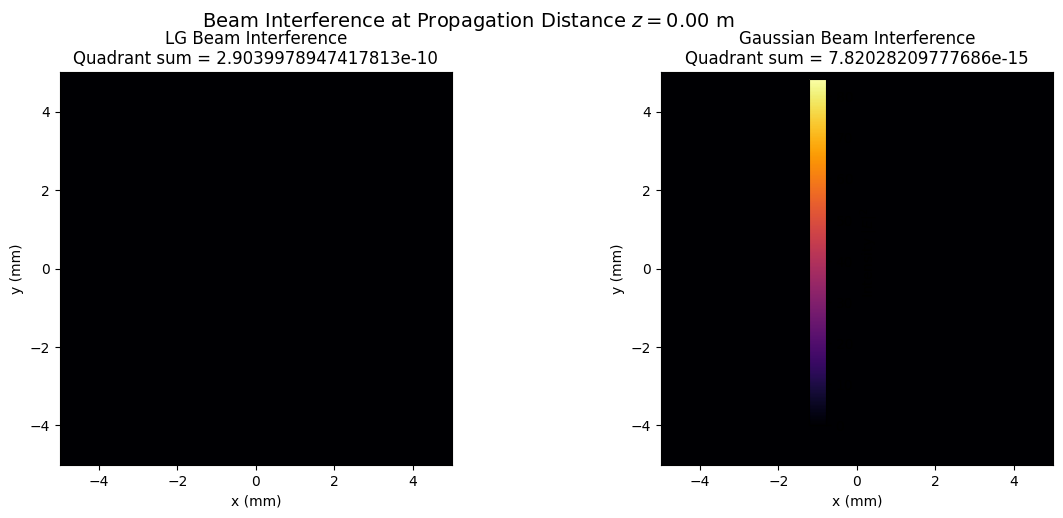

Distance = 1.00 m
LG quadrant intensity       = -1.1994e+03
Gaussian quadrant intensity = -1.9499e-04


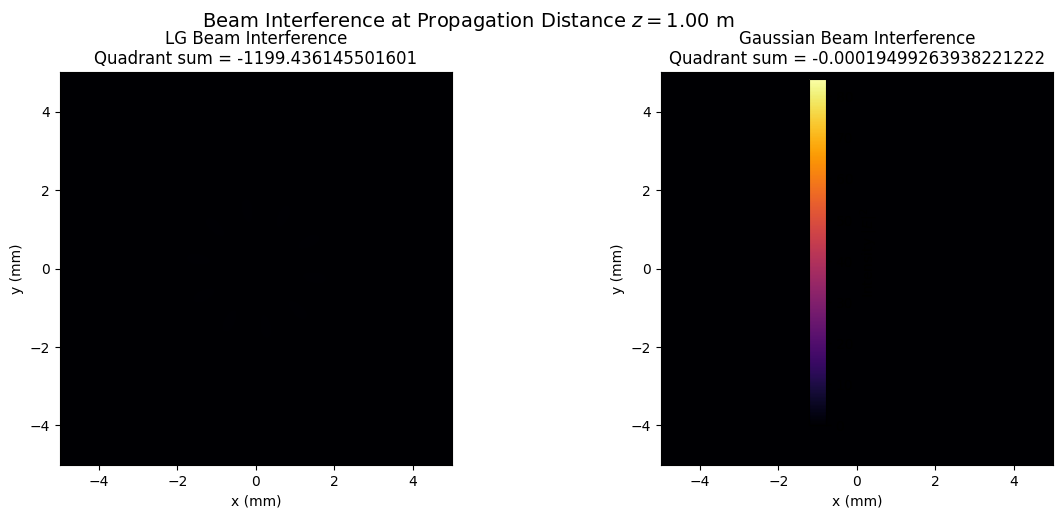

Distance = 2.00 m
LG quadrant intensity       = -2.3987e+03
Gaussian quadrant intensity = -7.7996e-04


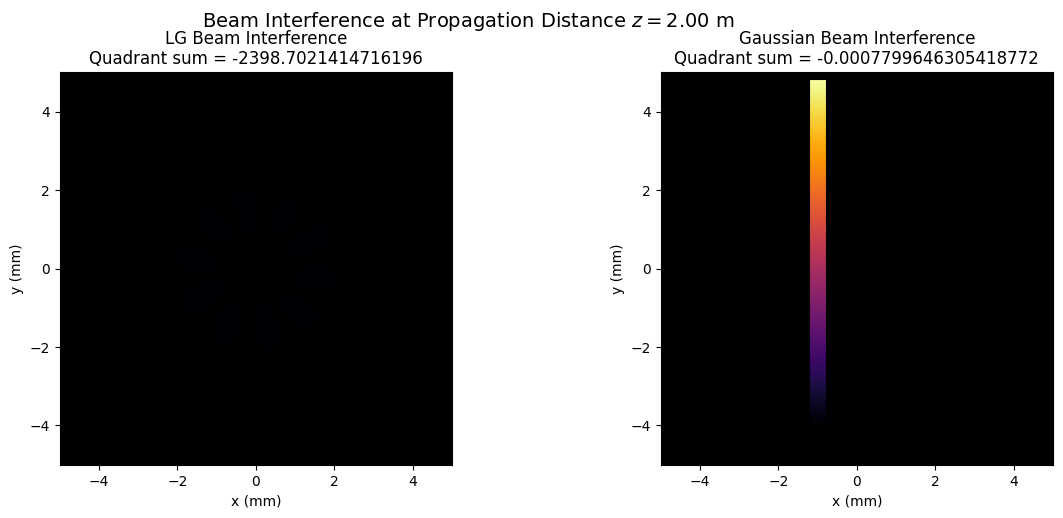

Distance = 3.00 m
LG quadrant intensity       = -3.5976e+03
Gaussian quadrant intensity = -1.7549e-03


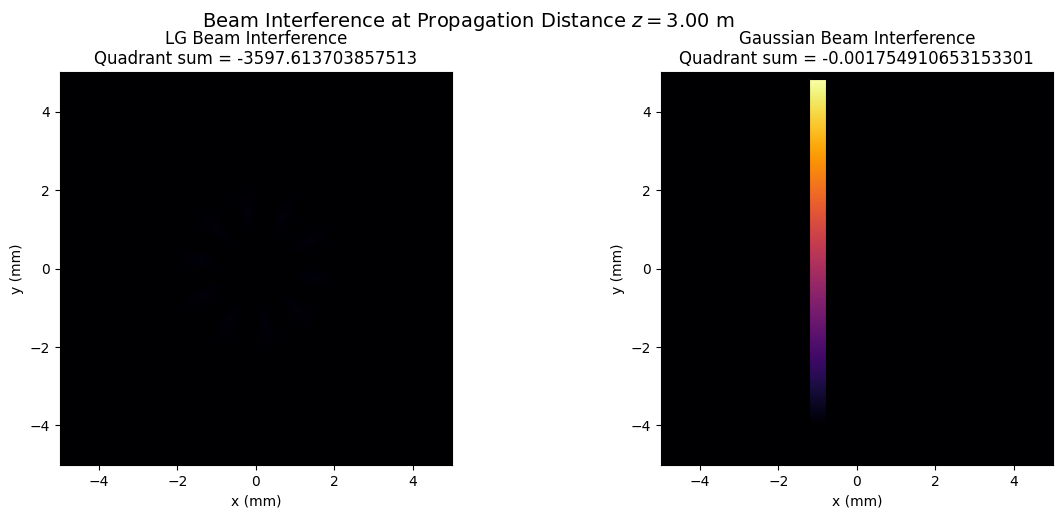

Distance = 4.00 m
LG quadrant intensity       = -4.7960e+03
Gaussian quadrant intensity = -3.1198e-03


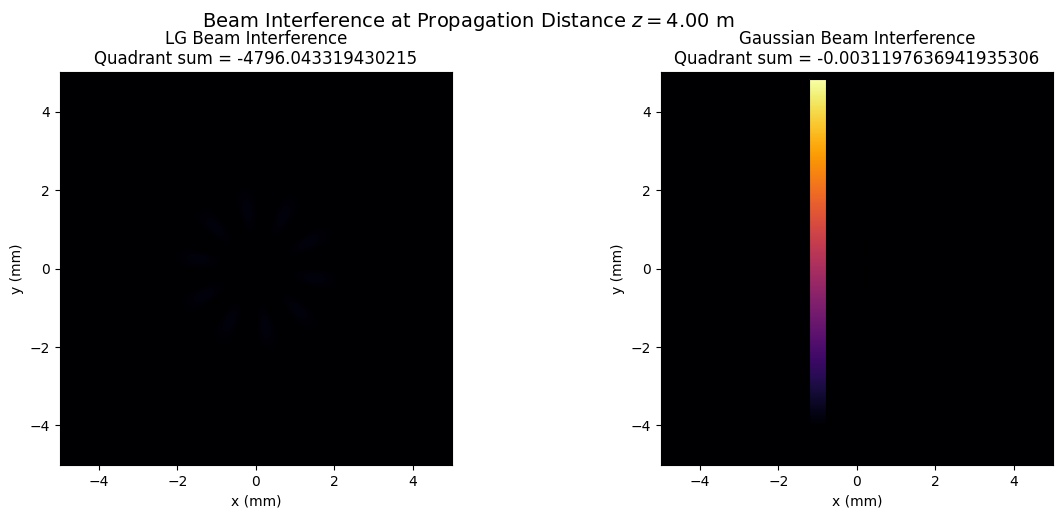

Distance = 5.00 m
LG quadrant intensity       = -5.9938e+03
Gaussian quadrant intensity = -4.8745e-03


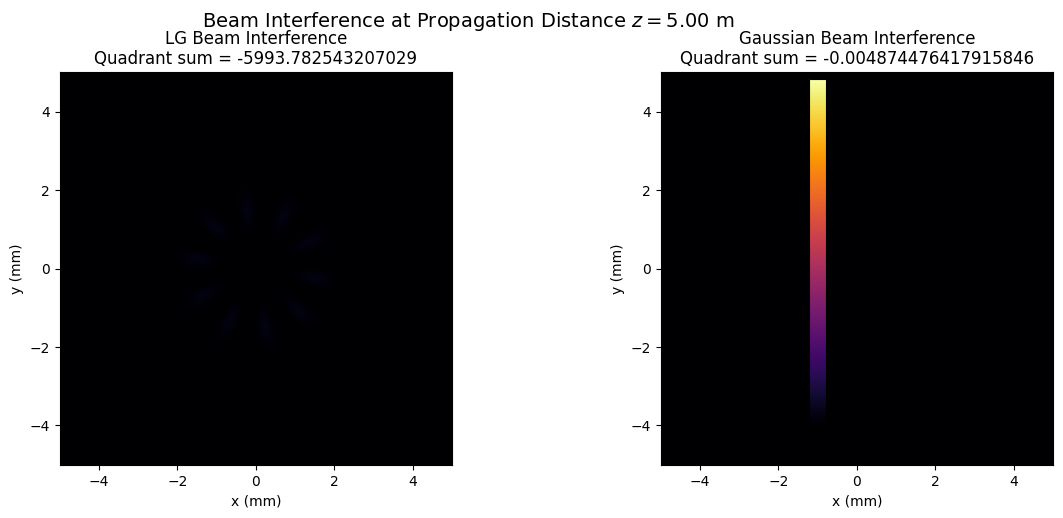

Distance = 6.00 m
LG quadrant intensity       = -7.1906e+03
Gaussian quadrant intensity = -7.0192e-03


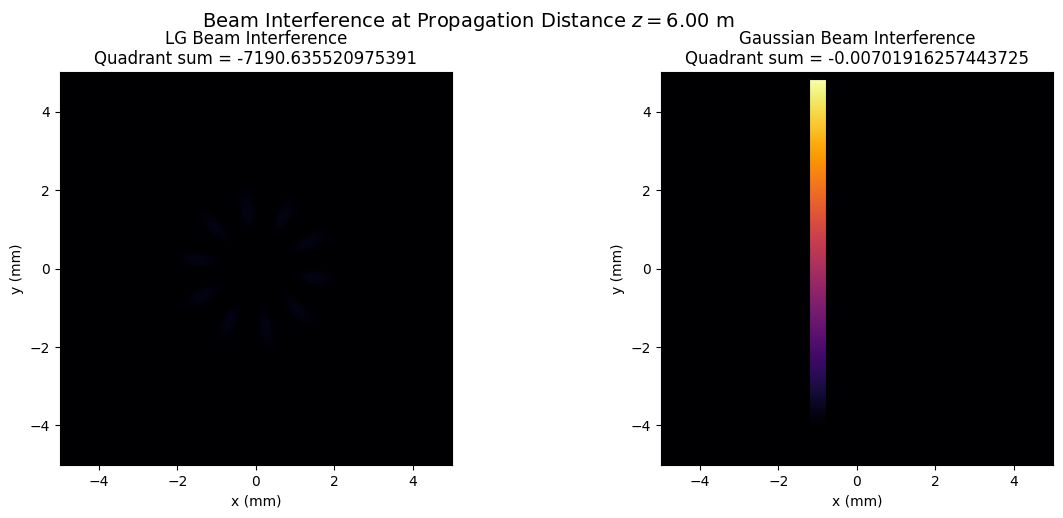

Distance = 7.00 m
LG quadrant intensity       = -8.3866e+03
Gaussian quadrant intensity = -9.5535e-03


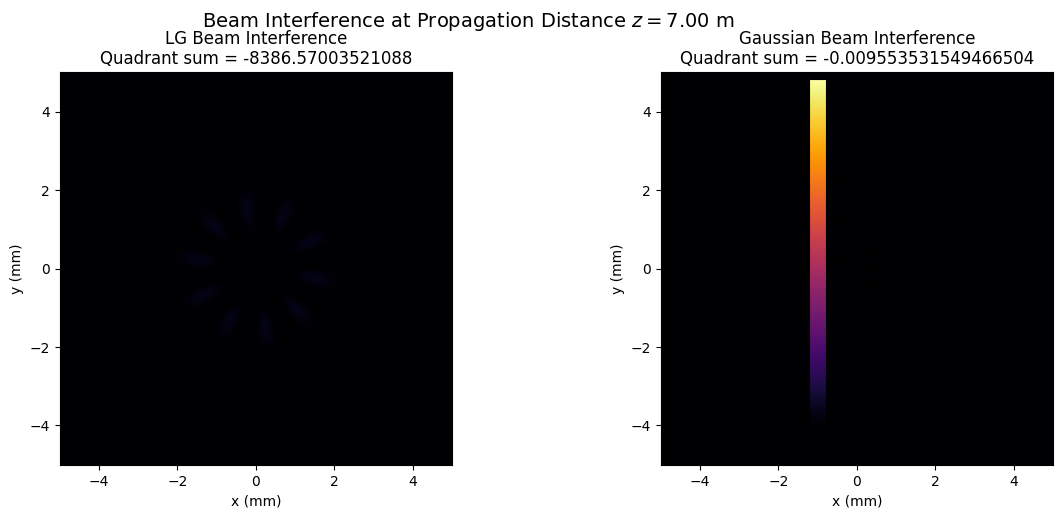

Distance = 8.00 m
LG quadrant intensity       = -9.5812e+03
Gaussian quadrant intensity = -1.2478e-02


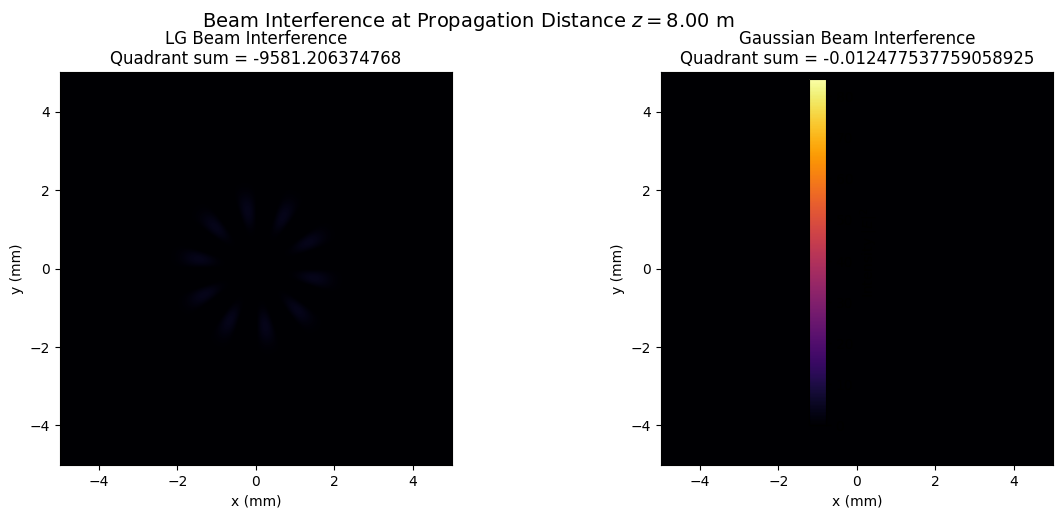

Distance = 9.00 m
LG quadrant intensity       = -1.0774e+04
Gaussian quadrant intensity = -1.5791e-02


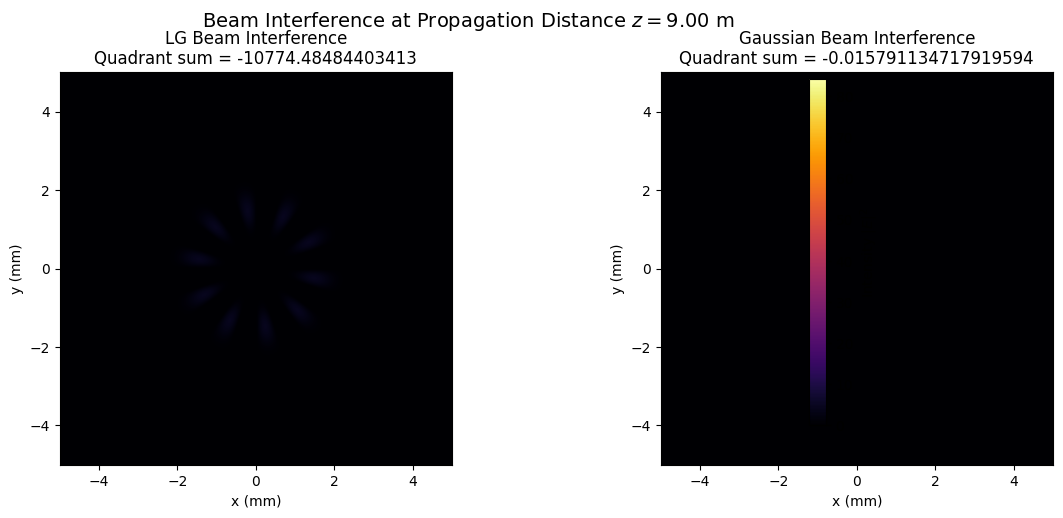

Distance = 10.00 m
LG quadrant intensity       = -1.1966e+04
Gaussian quadrant intensity = -1.9494e-02


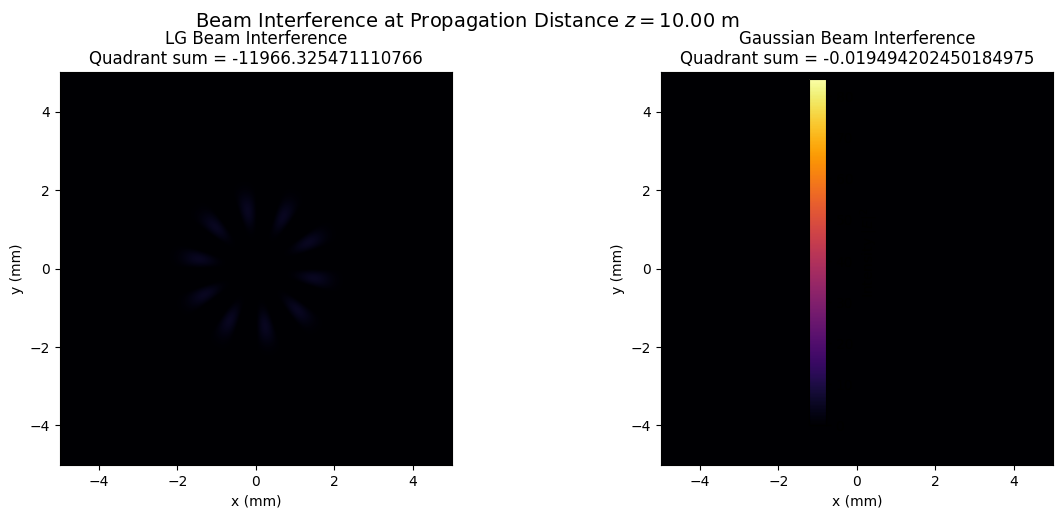

"\n  ############# Plotting \n\n  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2\n  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2\n\n  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])\n  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])\n\n  print(quad_sum_LG)\n  print(quad_sum_G)\n\n  plt.imshow(LG_I)\n  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')\n  plt.colorbar()\n  plt.show()\n\n  plt.imshow(G_I)\n  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')\n  plt.colorbar()\n  plt.show()"

In [ ]:
################### Producing intensity arrays/plots to do difference imaging
l = 5
Lg_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
Lg_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
Lg_beam_1.E = Lg_beam_1.field( Lg_beam_1.r_1, np.arctan2(Lg_beam_1.Y, Lg_beam_1.X), z=Lg_beam_1.z, p=0, l = l)
Lg_beam_2.E = Lg_beam_2.field( Lg_beam_2.r_2, np.arctan2(Lg_beam_2.Y - Lg_beam_2.dy, Lg_beam_2.X - Lg_beam_2.dx), z=Lg_beam_2.z, p=0, l=-l)
Lg_I = np.abs(Lg_beam_1.E + Lg_beam_2.E)**2

###################### Gaussian beam for difference imaging


g_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
g_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
g_beam_1.E = g_beam_1.field(g_beam_1.r_1,z=g_beam_1.z)
g_beam_2.E = g_beam_2.field(g_beam_2.r_2,z=g_beam_2.z)

g_I = np.abs(g_beam_1.E + g_beam_2.E)**2

#################################################################
dists = np.linspace(0,10,11) ##  arm lengths changing from 0 to 10 meters

for dist in dists:
  ############### LG beams
  LG_beam_1 = LG_Beam(dist=0,lamb=10e-9,E_0=1)
  LG_beam_2 = LG_Beam(dist=0,lamb=10e-9,E_0=1)

  LG_beam_1.E = LG_beam_1.field( LG_beam_1.r_1, np.arctan2(LG_beam_1.Y, LG_beam_1.X), z=LG_beam_1.z, p=0, l=l )
  LG_beam_2.E = LG_beam_2.field( LG_beam_2.r_2, np.arctan2(LG_beam_2.Y - LG_beam_2.dy, LG_beam_2.X - LG_beam_2.dx), z=LG_beam_2.z, p=0, l=-l)

  LG_beam_1.propagation(dist)
  LG_beam_2.propagation(0)

  #LG_beam_1.gw_phase(dist)

  LG_E_1_propagated = LG_beam_1.E
  LG_E_2_propagated = LG_beam_2.E

  ########## Gaussian beams

  G_beam_1 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)
  G_beam_2 = G_Beam(dist=0,lamb=10e-9,E_0=1,w_0=1e-3,points=100)

  G_beam_1.E = G_beam_1.field(G_beam_1.r_1,z=G_beam_1.z)
  G_beam_2.E = G_beam_2.field(G_beam_2.r_2,z=G_beam_2.z)

  G_beam_1.propagation(dist)
  G_beam_2.propagation(0)

  #G_beam_1.gw_phase(dist)

  G_E_1_propagated = G_beam_1.E
  G_E_2_propagated = G_beam_2.E

       # ---------------- Plotting ----------------
  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I  = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  LG_I_diff_img = LG_I - Lg_I
  G_I_diff_img = G_I - g_I

  # Sum of intensity in the top-left quadrant
  quad_sum_LG = np.sum(LG_I_diff_img[:len(LG_I)//2, :len(LG_I)//2])
  quad_sum_G  = np.sum(G_I_diff_img[:len(G_I)//2, :len(G_I)//2])

  print(f"Distance = {dist:.2f} m")
  print(f"LG quadrant intensity       = {quad_sum_LG:.4e}")
  print(f"Gaussian quadrant intensity = {quad_sum_G:.4e}")

  # ------------------------------------------------
  # Create figure with two side-by-side plots
  # ------------------------------------------------

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # Use the same intensity scale for both plots
  vmax = max(LG_I.max(), G_I.max())

  # LG plot
  im1 = axes[0].imshow(
    LG_I_diff_img,
    origin='lower',
    extent=[
        LG_beam_1.x.min() * 1e3,
        LG_beam_1.x.max() * 1e3,
        LG_beam_1.y.min() * 1e3,
        LG_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[0].set_title(
    f'LG Beam Interference\n'
    f'Quadrant sum = {quad_sum_LG}'
)

  axes[0].set_xlabel('x (mm)')
  axes[0].set_ylabel('y (mm)')

# Gaussian plot
  im2 = axes[1].imshow(
    G_I_diff_img,
    origin='lower',
    extent=[
        G_beam_1.x.min() * 1e3,
        G_beam_1.x.max() * 1e3,
        G_beam_1.y.min() * 1e3,
        G_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

  axes[1].set_title(
    f'Gaussian Beam Interference\n'
    f'Quadrant sum = {quad_sum_G}'
)

  axes[1].set_xlabel('x (mm)')
  axes[1].set_ylabel('y (mm)')

  # One shared colourbar
  cbar = fig.colorbar(im2, ax=axes, shrink=0.9)
  cbar.set_label(r'Intensity $|E|^2$')

  # Overall title
  fig.suptitle(
    f'Beam Interference at Propagation Distance $z = {dist:.2f}$ m',
    fontsize=14
)

  plt.tight_layout()
  plt.show()






'''
  ############# Plotting

  LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
  G_I = np.abs(G_E_1_propagated + G_E_2_propagated)**2

  quad_sum_LG = np.sum(I[:len(LG_I)//2, :len(LG_I)//2 ])
  quad_sum_G = np.sum(I[:len(G_I)//2, :len(G_I)//2 ])

  print(quad_sum_LG)
  print(quad_sum_G)

  plt.imshow(LG_I)
  plt.title(f'LG  sum of quad intensity {quad_sum_LG}')
  plt.colorbar()
  plt.show()

  plt.imshow(G_I)
  plt.title(f'Gaussian sum of quad intensity {quad_sum_G}')
  plt.colorbar()
  plt.show()'''

Distance = 7.00 m
LG quadrant intensity       = 1.6439e+04
Gaussian quadrant intensity = 1.5394e+02


/tmp/ipykernel_1652/473556820.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


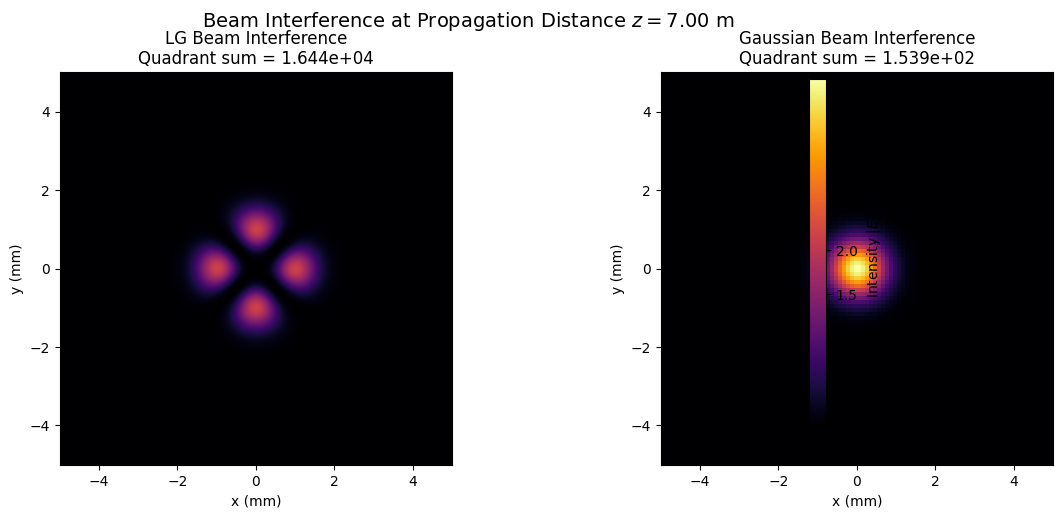

In [ ]:
# ---------------- Plotting ----------------

LG_I = np.abs(LG_E_1_propagated + LG_E_2_propagated)**2
G_I  = np.abs(G_E_1_propagated + G_E_2_propagated)**2

# Sum of intensity in the top-left quadrant
quad_sum_LG = np.sum(LG_I[:len(LG_I)//2, :len(LG_I)//2])
quad_sum_G  = np.sum(G_I[:len(G_I)//2, :len(G_I)//2])

print(f"Distance = {dist:.2f} m")
print(f"LG quadrant intensity       = {quad_sum_LG:.4e}")
print(f"Gaussian quadrant intensity = {quad_sum_G:.4e}")

# ------------------------------------------------
# Create figure with two side-by-side plots
# ------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Use the same intensity scale for both plots
vmax = max(LG_I.max(), G_I.max())

# LG plot
im1 = axes[0].imshow(
    LG_I,
    origin='lower',
    extent=[
        LG_beam_1.x.min() * 1e3,
        LG_beam_1.x.max() * 1e3,
        LG_beam_1.y.min() * 1e3,
        LG_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

axes[0].set_title(
    f'LG Beam Interference\n'
    f'Quadrant sum = {quad_sum_LG:.3e}'
)

axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')

# Gaussian plot
im2 = axes[1].imshow(
    G_I,
    origin='lower',
    extent=[
        G_beam_1.x.min() * 1e3,
        G_beam_1.x.max() * 1e3,
        G_beam_1.y.min() * 1e3,
        G_beam_1.y.max() * 1e3
    ],
    vmin=0,
    vmax=vmax,
    cmap='inferno'
)

axes[1].set_title(
    f'Gaussian Beam Interference\n'
    f'Quadrant sum = {quad_sum_G:.3e}'
)

axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')

# One shared colourbar
cbar = fig.colorbar(im2, ax=axes, shrink=0.9)
cbar.set_label(r'Intensity $|E|^2$')

# Overall title
fig.suptitle(
    f'Beam Interference at Propagation Distance $z = {dist:.2f}$ m',
    fontsize=14
)

plt.tight_layout()
plt.show()

16406.716305960406
1.9821918397299054e-07


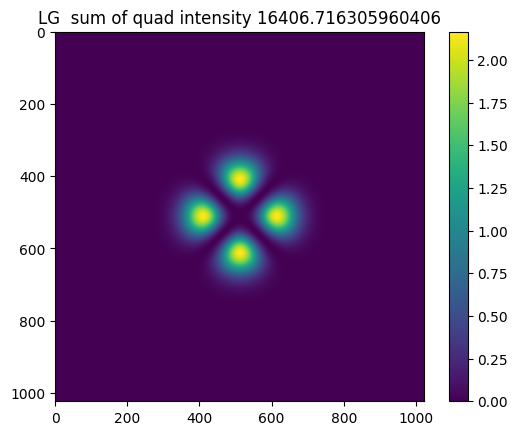

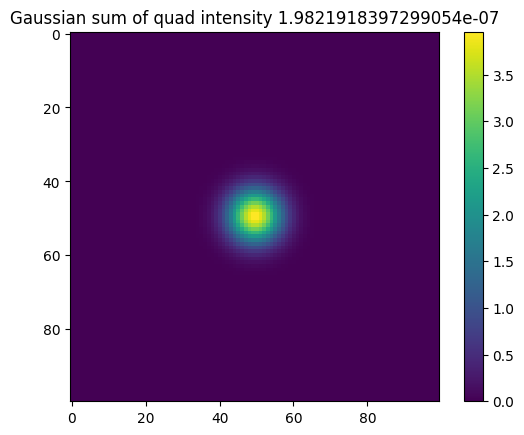

# Trying gaussian beams in TorchOptics

In [ ]:
torchoptics.set_default_spacing(0.5e-6)
torchoptics.set_default_wavelength(10e-9)


In [ ]:
profile_1 = gaussian(256, waist_radius = 3e-6, spacing = 10e-6, wavelength = 10e-9)
field_1 = Field(profile_1, z = 0, spacing = 10e-6)
field_1 = field_1.propagate_to_z(z = 0.4)

profile_2 = gaussian(256, waist_radius = 3e-6, spacing = 10e-6, wavelength = 10e-9)
field_2 = Field(profile_2, z = 0, spacing = 10e-6)
field_2 = field_2.propagate_to_z(z = 0.4)

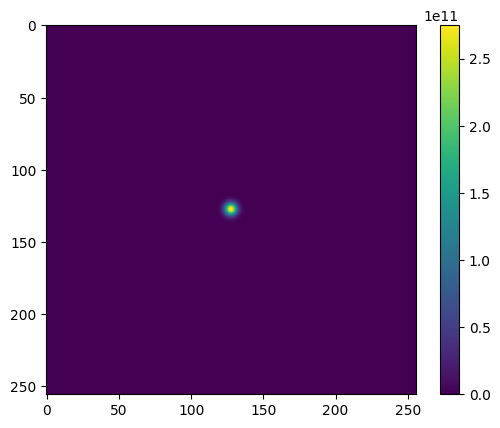

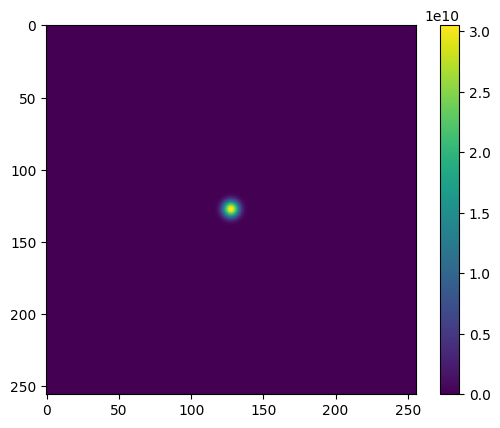

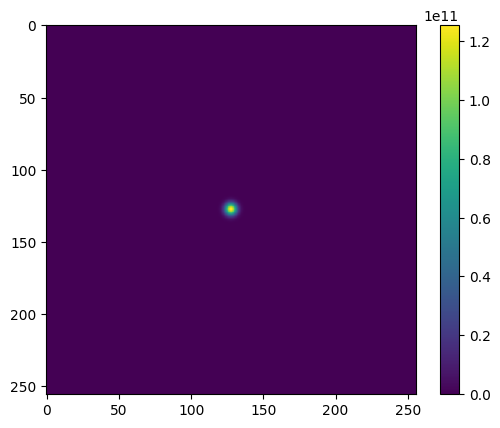

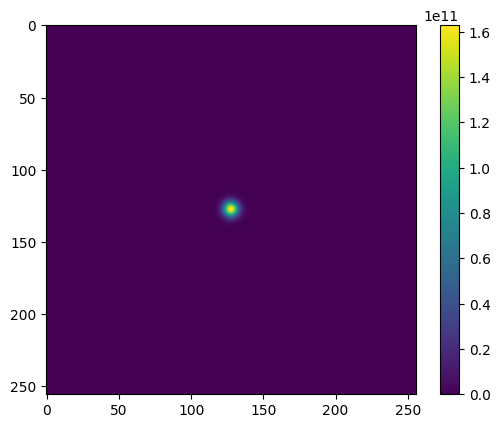

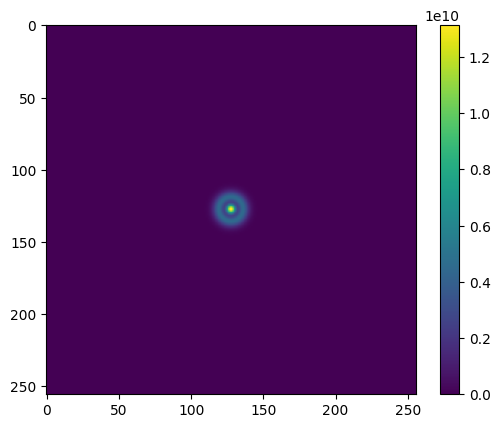

ValueError: Expected field to have same geometry as element:
Field geometry:   shape=(256, 256), z=1.00e+00, spacing=(1.00e-05, 1.00e-05), offset=(0.00e+00, 0.00e+00)
Element geometry: shape=(256, 256), z=0.00e+00, spacing=(1.00e-05, 1.00e-05), offset=(0.00e+00, 0.00e+00)

In [ ]:
dists = np.linspace(0,10,25)

for dist in dists:

  profile_1 = gaussian(256, waist_radius = 3e-6)
  field_1 = Field(profile_1, z = 0, spacing = 10e-6)
  field_1 = field_1.propagate_to_z(z = dist//2)
  # making lens to keep beam shapes same as beams propagate different distances
  lens = Lens(shape = 256, focal_length=10e-3, z=0, spacing=10e-6)
  focused = lens(field_1).propagate(z = 10e-3, shape = 256)
  field_1 = field_1.propagate_to_z(z = dist)

  profile_2 = gaussian(256, waist_radius = 3e-6)
  field_2 = Field(profile_2, z = 0, spacing = 10e-6)
  field_2 = field_2.propagate_to_z(z = 0)

  I = torch.abs(field_1.data + field_2.data)**2

  plt.imshow(I)
  plt.colorbar()
  plt.show()